In [1]:
# ============================================================
# BLOCK 1: Environment Setup
# CRATTT Clean Implementation
# Dada Victor Damilare | MRES7015 | University of Greater Manchester
# ============================================================

# --- 1.1 Install Required Libraries ---
!pip install imagecorruptions -q
!pip install wandb -q
!pip install pycocotools -q
!pip install ultralytics -q

# --- 1.2 Core Imports ---
import os
import sys
import random
import json
import glob
import numpy as np
import torch
import skimage
import skimage.filters
import imagecorruptions.corruptions as cor_mod
import imagecorruptions
import wandb
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# --- 1.3 Reproducibility: Fix All Seeds ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f"✅ Seeds fixed: {SEED}")

# --- 1.4 Surgical Patch: NumPy 2.0 + scikit-image compatibility ---
# imagecorruptions uses the deprecated 'multichannel' kwarg removed in
# scikit-image 0.19+. This patch redirects it to the new 'channel_axis'.
if not hasattr(skimage.filters.gaussian, '_is_patched'):
    _real_gaussian = skimage.filters.gaussian

    def _patched_gaussian(*args, **kwargs):
        if 'multichannel' in kwargs:
            val = kwargs.pop('multichannel')
            kwargs['channel_axis'] = -1 if val else None
        return _real_gaussian(*args, **kwargs)

    _patched_gaussian._is_patched = True
    skimage.filters.gaussian = _patched_gaussian
    cor_mod.gaussian = _patched_gaussian
    print("✅ scikit-image patch applied")
else:
    print("✅ scikit-image patch already active")

# --- 1.5 Log Library Versions for Reproducibility ---
print("\n--- Library Versions ---")
print(f"Python:            {sys.version.split()[0]}")
print(f"PyTorch:           {torch.__version__}")
print(f"NumPy:             {np.__version__}")
print(f"scikit-image:      {skimage.__version__}")

import importlib.metadata
try:
    ic_version = importlib.metadata.version("imagecorruptions")
except importlib.metadata.PackageNotFoundError:
    ic_version = "installed (version unknown)"
print(f"imagecorruptions:  {ic_version}")

# --- 1.6 Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Device: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# --- 1.7 Secure API Connections ---
user_secrets = UserSecretsClient()
print("\n--- API Connections ---")

try:
    wb_key = user_secrets.get_secret("WANDB_API_KEY")
    wandb.login(key=wb_key, relogin=True)
    print("✅ W&B: Connected")
except Exception as e:
    print(f"⚠️  W&B: Not connected — {e}")

try:
    hf_token = user_secrets.get_secret("HF_TOKEN")
    login(token=hf_token)
    print("✅ HuggingFace: Connected")
except Exception as e:
    print(f"❌ HuggingFace: Failed — {e}")

# --- 1.8 Create Output Directories ---
DIRS = {
    "results":  "/kaggle/working/results",
    "figures":  "/kaggle/working/figures",
    "checkpoints": "/kaggle/working/checkpoints",
    "tables":   "/kaggle/working/tables"
}
for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)

print(f"\n✅ Output directories created:")
for name, path in DIRS.items():
    print(f"   {name}: {path}")

print("\n" + "="*50)
print("BLOCK 1 COMPLETE — Environment ready")
print("="*50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.2 MB/s eta 0:00:00a 0:00:01
✅ Seeds fixed: 42
✅ scikit-image patch applied

--- Library Versions ---
Python:            3.12.12
PyTorch:           2.10.0+cu128
NumPy:             2.0.2
scikit-image:      0.25.2
imagecorruptions:  1.1.2

✅ Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB

--- API Connections ---


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: vd1res (vd1res-university-of-bolton) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ W&B: Connected
✅ HuggingFace: Connected

✅ Output directories created:
   results: /kaggle/working/results
   figures: /kaggle/working/figures
   checkpoints: /kaggle/working/checkpoints
   tables: /kaggle/working/tables

BLOCK 1 COMPLETE — Environment ready


In [2]:
# ============================================================
# BLOCK 1b: NumPy 2.0 Patch for imagecorruptions fog/frost
# np.float_ was removed in NumPy 2.0 — patch it back in
# ============================================================

import numpy as np

if not hasattr(np, 'float_'):
    np.float_ = np.float64
    print("✅ np.float_ patch applied")
else:
    print("✅ np.float_ already exists — no patch needed")

# Verify fog now works on a test image
from imagecorruptions import corrupt
test = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
try:
    _ = corrupt(test, corruption_name='fog', severity=1)
    print("✅ Fog corruption verified working")
except Exception as e:
    print(f"❌ Fog still failing: {e}")

✅ np.float_ patch applied
✅ Fog corruption verified working


In [3]:
# ============================================================
# BLOCK 2: Model Loading
# Loads GroundingDINO, YOLO-World, and CLIP Oracle once.
# Never reload models in subsequent blocks.
# ============================================================

import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from transformers import CLIPProcessor, CLIPModel
from ultralytics import YOLOWorld

print("Loading models to device:", device)
print("="*50)

# --- 2.1 GroundingDINO ---
print("\n[1/3] Loading GroundingDINO-tiny...")
DINO_MODEL_ID = "IDEA-Research/grounding-dino-tiny"

dino_processor = AutoProcessor.from_pretrained(
    DINO_MODEL_ID, token=hf_token
)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    DINO_MODEL_ID, token=hf_token
).to(device)
dino_model.eval()

dino_params = sum(p.numel() for p in dino_model.parameters())
print(f"✅ GroundingDINO-tiny loaded")
print(f"   Parameters: {dino_params:,}")
print(f"   VRAM used so far: "
      f"{torch.cuda.memory_allocated() / 1e9:.2f} GB")

# --- 2.2 YOLO-World ---
print("\n[2/3] Loading YOLO-World-large...")

# CPU handoff pattern: set classes on CPU to avoid CUDA text-encoding bug
yolo_model = YOLOWorld('yolov8l-world.pt')
yolo_model.to('cpu')

# We will set the full class list in Block 3 once COCO_MAP is defined
# For now just verify it loads
print(f"✅ YOLO-World-large loaded")
print(f"   VRAM used so far: "
      f"{torch.cuda.memory_allocated() / 1e9:.2f} GB")

# --- 2.3 CLIP Oracle ---
print("\n[3/3] Loading CLIP Oracle (ViT-B/32)...")
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
clip_model.eval()

clip_params = sum(p.numel() for p in clip_model.parameters())
print(f"✅ CLIP Oracle loaded")
print(f"   Parameters: {clip_params:,}")
print(f"   VRAM used so far: "
      f"{torch.cuda.memory_allocated() / 1e9:.2f} GB")

# --- 2.4 VRAM Summary ---
vram_allocated = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free = vram_total - vram_allocated

print("\n--- VRAM Summary ---")
print(f"Allocated: {vram_allocated:.2f} GB")
print(f"Free:      {vram_free:.2f} GB")
print(f"Total:     {vram_total:.2f} GB")

if vram_free < 4.0:
    print("⚠️  WARNING: Less than 4GB free. "
          "Consider reducing NUM_IMAGES in Block 4.")
else:
    print("✅ VRAM headroom is sufficient for inference.")

print("\n" + "="*50)
print("BLOCK 2 COMPLETE — All models loaded")
print("="*50)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading models to device: cuda

[1/3] Loading GroundingDINO-tiny...


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP Oracle loaded
   Parameters: 151,277,313
   VRAM used so far: 1.30 GB

--- VRAM Summary ---
Allocated: 1.30 GB
Free:      14.34 GB
Total:     15.64 GB
✅ VRAM headroom is sufficient for inference.

BLOCK 2 COMPLETE — All models loaded


In [4]:
# ============================================================
# BLOCK 3: Global Constants
# Single source of truth for all experimental parameters.
# Never hardcode these values in subsequent blocks.
# ============================================================

import torch
import torch.nn.functional as F

# --- 3.1 COCO Category Mapping ---
# Verified against official COCO 2017 annotation file
COCO_MAP = {
    'person': 1, 'bicycle': 2, 'car': 3, 'motorcycle': 4,
    'airplane': 5, 'bus': 6, 'train': 7, 'truck': 8, 'boat': 9,
    'traffic light': 10, 'fire hydrant': 11, 'stop sign': 13,
    'parking meter': 14, 'bench': 15, 'bird': 16, 'cat': 17,
    'dog': 18, 'horse': 19, 'sheep': 20, 'cow': 21,
    'elephant': 22, 'bear': 23, 'zebra': 24, 'giraffe': 25,
    'backpack': 27, 'umbrella': 28, 'handbag': 31, 'tie': 32,
    'suitcase': 33, 'frisbee': 34, 'skis': 35, 'snowboard': 36,
    'sports ball': 37, 'kite': 38, 'baseball bat': 39,
    'baseball glove': 40, 'skateboard': 41, 'surfboard': 42,
    'tennis racket': 43, 'bottle': 44, 'wine glass': 46,
    'cup': 47, 'fork': 48, 'knife': 49, 'spoon': 50, 'bowl': 51,
    'banana': 52, 'apple': 53, 'sandwich': 54, 'orange': 55,
    'broccoli': 56, 'carrot': 57, 'hot dog': 58, 'pizza': 59,
    'donut': 60, 'cake': 61, 'chair': 62, 'couch': 63,
    'potted plant': 64, 'bed': 65, 'dining table': 67,
    'toilet': 70, 'tv': 72, 'laptop': 73, 'mouse': 74,
    'remote': 75, 'keyboard': 76, 'cell phone': 77,
    'microwave': 78, 'oven': 79, 'toaster': 80, 'sink': 81,
    'refrigerator': 82, 'book': 84, 'clock': 85, 'vase': 86,
    'scissors': 87, 'teddy bear': 88, 'hair drier': 89,
    'toothbrush': 90
}

COCO_CLASSES = list(COCO_MAP.keys())  # 80 classes
print(f"✅ COCO_MAP loaded: {len(COCO_MAP)} categories")

# --- 3.2 Verify COCO_MAP Against Ground Truth ---
# This catches any ID mismatches before they silently corrupt mAP scores
from pycocotools.coco import COCO

ANN_PATH = ("/kaggle/input/datasets/awsaf49/"
            "coco-2017-dataset/coco2017/annotations/"
            "instances_val2017.json")
IMAGE_DIR = ("/kaggle/input/datasets/awsaf49/"
             "coco-2017-dataset/coco2017/val2017")

coco_gt = COCO(ANN_PATH)
official_cats = {
    cat['name']: cat['id']
    for cat in coco_gt.loadCats(coco_gt.getCatIds())
}

mismatches = []
for name, our_id in COCO_MAP.items():
    official_id = official_cats.get(name)
    if official_id is None:
        mismatches.append(f"  NOT FOUND in COCO: '{name}'")
    elif official_id != our_id:
        mismatches.append(
            f"  MISMATCH: '{name}' → ours={our_id}, "
            f"official={official_id}"
        )

if mismatches:
    print("⚠️  COCO_MAP mismatches detected:")
    for m in mismatches:
        print(m)
else:
    print("✅ COCO_MAP verified: all 80 IDs match official annotations")

# --- 3.3 Text Prompts ---
# GroundingDINO expects dot-separated class names
DINO_TEXT_PROMPT = " . ".join(COCO_CLASSES) + " ."

# YOLO-World expects plain class names
# Set classes here using the CPU handoff pattern
yolo_model.to('cpu')
yolo_model.set_classes(COCO_CLASSES)
yolo_model.to(device)
print("✅ YOLO-World classes set: 80 COCO categories")


# --- 3.4 CLIP Per-Class Text Embeddings ---
print("\nGenerating per-class CLIP text embeddings...")

with torch.no_grad():
    embeddings = []
    
    for class_name in COCO_CLASSES:
        inputs = clip_processor(
            text=[class_name],
            return_tensors="pt",
            padding=True
        ).to(device)
        
        # Bypass get_text_features entirely
        # Call text_model directly, extract last hidden state,
        # then apply projection manually
        text_out = clip_model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )
        
        # Pooled output is the [EOS] token representation
        # Shape: [1, hidden_dim] = [1, 512]
        pooled = text_out.pooler_output
        
        # Apply the learned projection to get final embedding
        projected = clip_model.text_projection(pooled)
        embeddings.append(projected)
    
    clip_text_features = torch.cat(embeddings, dim=0)
    clip_text_features = F.normalize(clip_text_features, p=2, dim=-1)

print(f"✅ CLIP text embeddings: {clip_text_features.shape}")
print(f"   Expected: torch.Size([80, 512])")

person_idx = COCO_CLASSES.index('person')
car_idx    = COCO_CLASSES.index('car')
chair_idx  = COCO_CLASSES.index('chair')
dog_idx    = COCO_CLASSES.index('dog')

sim_person_car  = (clip_text_features[person_idx] @ clip_text_features[car_idx]).item()
sim_person_dog  = (clip_text_features[person_idx] @ clip_text_features[dog_idx]).item()
sim_car_chair   = (clip_text_features[car_idx] @ clip_text_features[chair_idx]).item()

print(f"\n   Similarity checks (all must be < 0.98):")
print(f"   person vs car:   {sim_person_car:.4f}")
print(f"   person vs dog:   {sim_person_dog:.4f}")
print(f"   car vs chair:    {sim_car_chair:.4f}")

all_distinct = all(
    s < 0.98 for s in [sim_person_car, sim_person_dog, sim_car_chair]
)
print(f"\n   {'✅ All embeddings are distinct' if all_distinct else '❌ Still identical — check CLIP model'}")


# --- 3.5 ImageNet-C Corruption Protocol ---
CORRUPTION_CATEGORIES = {
    "Noise":   ["gaussian_noise", "shot_noise", "impulse_noise"],
    "Blur":    ["defocus_blur", "glass_blur", "motion_blur", "zoom_blur"],
    "Weather": ["snow", "frost", "fog", "brightness"],
    "Digital": ["contrast", "elastic_transform",
                "pixelate", "jpeg_compression"]
}
ALL_CORRUPTIONS = [c for cats in CORRUPTION_CATEGORIES.values()
                   for c in cats]
SEVERITIES = [1, 2, 3, 4, 5]

print(f"\n✅ ImageNet-C protocol:")
print(f"   Categories: {list(CORRUPTION_CATEGORIES.keys())}")
print(f"   Total corruptions: {len(ALL_CORRUPTIONS)}")
print(f"   Severities: {SEVERITIES}")

# --- 3.6 CRATTT Hyperparameters ---
# Fixed values from Chapter 3 pilot analysis
# Do not change these for primary results
# Use ablation blocks for sensitivity analysis
CRATTT_PARAMS = {
    "alpha":          0.4,   # DINO weight in Rjoint
    "beta":           0.6,   # Oracle weight in Rjoint
    "tau":            0.25,  # Fixed verification threshold
    "dino_text_thr":  0.12,  # GroundingDINO text threshold (permissive)
    "yolo_conf":      0.12,  # YOLO confidence (matched to DINO)
    "max_regions":    15,    # BARON max region crops
    "region_size":    (224, 224),  # CLIP input size
}
print(f"\n✅ CRATTT hyperparameters locked:")
for k, v in CRATTT_PARAMS.items():
    print(f"   {k}: {v}")

# --- 3.7 Evaluation Settings ---
EVAL_PARAMS = {
    "num_images":   20,
    "num_pilot":    5,
    "save_dir":     DIRS["results"],
    "fig_dir":      DIRS["figures"],
    "table_dir":    DIRS["tables"],
    "ckpt_dir":     DIRS["checkpoints"],
}
print(f"\n✅ Evaluation parameters:")
for k, v in EVAL_PARAMS.items():
    print(f"   {k}: {v}")

print("\n" + "="*50)
print("BLOCK 3 COMPLETE — Constants defined")
print("="*50)

✅ COCO_MAP loaded: 80 categories
loading annotations into memory...
Done (t=0.95s)
creating index...
index created!
✅ COCO_MAP verified: all 80 IDs match official annotations
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 36 packages in 734ms
Prepared 2 packages in 2.39s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@81ff68ed7ffcac3b40484c914f104f816757308d)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 6.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 142MiB/s]


✅ YOLO-World classes set: 80 COCO categories

Generating per-class CLIP text embeddings...
✅ CLIP text embeddings: torch.Size([80, 512])
   Expected: torch.Size([80, 512])

   Similarity checks (all must be < 0.98):
   person vs car:   0.8450
   person vs dog:   0.8424
   car vs chair:    0.8068

   ✅ All embeddings are distinct

✅ ImageNet-C protocol:
   Categories: ['Noise', 'Blur', 'Weather', 'Digital']
   Total corruptions: 15
   Severities: [1, 2, 3, 4, 5]

✅ CRATTT hyperparameters locked:
   alpha: 0.4
   beta: 0.6
   tau: 0.25
   dino_text_thr: 0.12
   yolo_conf: 0.12
   max_regions: 15
   region_size: (224, 224)

✅ Evaluation parameters:
   num_images: 20
   num_pilot: 5
   save_dir: /kaggle/working/results
   fig_dir: /kaggle/working/figures
   table_dir: /kaggle/working/tables
   ckpt_dir: /kaggle/working/checkpoints

BLOCK 3 COMPLETE — Constants defined


In [6]:
import requests
try:
    r = requests.get("https://huggingface.co", timeout=10)
    print(f"✅ Network OK: {r.status_code}")
except Exception as e:
    print(f"❌ Network issue: {e}")

✅ Network OK: 200


In [7]:
# ============================================================
# BLOCK 4: Data Loading & COCO Setup
# Loads 20 COCO validation images into memory once.
# Verifies ground truth annotations are accessible.
# ============================================================

import os
import glob
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm

# --- 4.1 Load Image File Paths ---
image_files = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))

assert len(image_files) > 0, \
    f"No images found at {IMAGE_DIR} — check dataset path"

# Take the first NUM_IMAGES for evaluation
image_files = image_files[:EVAL_PARAMS["num_images"]]
print(f"✅ Found {len(image_files)} images for evaluation")

# --- 4.2 Build Image ID Map ---
# COCO image IDs are encoded in the filename e.g. 000000000139.jpg → 139
img_id_map = {
    os.path.basename(f): int(os.path.basename(f).split('.')[0])
    for f in image_files
}
coco_img_ids = list(img_id_map.values())
print(f"✅ Image ID map built: {len(img_id_map)} entries")
print(f"   First 3 IDs: {coco_img_ids[:3]}")

# --- 4.3 Pre-load Images Into Memory ---
# Avoids repeated disk reads during the benchmark loops
print(f"\nPre-loading {len(image_files)} images into memory...")
loaded_images = {}

for img_path in tqdm(image_files, desc="Loading"):
    img_array = np.array(Image.open(img_path).convert("RGB"))
    loaded_images[img_path] = img_array

# Memory estimate
sample_shape = next(iter(loaded_images.values())).shape
total_mb = sum(
    img.nbytes for img in loaded_images.values()
) / 1e6

print(f"✅ All images loaded")
print(f"   Sample shape: {sample_shape}")
print(f"   Total memory: {total_mb:.1f} MB")

# --- 4.4 Verify COCO Annotations ---
# Check that ground truth boxes exist for our image IDs
print(f"\nVerifying COCO annotations...")
missing_annotations = []

for img_id in coco_img_ids:
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    if len(ann_ids) == 0:
        missing_annotations.append(img_id)

if missing_annotations:
    print(f"⚠️  {len(missing_annotations)} images have no annotations: "
          f"{missing_annotations}")
else:
    print(f"✅ All {len(coco_img_ids)} images have ground truth annotations")

# --- 4.5 Annotation Statistics ---
# Useful context for interpreting mAP results
total_gt_boxes = 0
category_counts = {}

for img_id in coco_img_ids:
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    anns = coco_gt.loadAnns(ann_ids)
    total_gt_boxes += len(anns)
    
    for ann in anns:
        cat_name = coco_gt.loadCats(ann['category_id'])[0]['name']
        category_counts[cat_name] = category_counts.get(cat_name, 0) + 1

# Top 10 most frequent categories in our evaluation set
top_cats = sorted(category_counts.items(), 
                  key=lambda x: x[1], reverse=True)[:10]

print(f"\n--- Ground Truth Statistics ---")
print(f"Total GT boxes across {len(image_files)} images: {total_gt_boxes}")
print(f"Mean GT boxes per image: {total_gt_boxes/len(image_files):.1f}")
print(f"\nTop 10 categories in evaluation set:")
for cat, count in top_cats:
    print(f"   {cat:<20} {count:>4} instances")

# --- 4.6 Save Dataset Manifest ---
import json

manifest = {
    "num_images": len(image_files),
    "image_ids": coco_img_ids,
    "total_gt_boxes": total_gt_boxes,
    "mean_gt_per_image": round(total_gt_boxes / len(image_files), 2),
    "top_categories": dict(top_cats)
}

manifest_path = os.path.join(EVAL_PARAMS["save_dir"], "dataset_manifest.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"\n✅ Dataset manifest saved: {manifest_path}")

print("\n" + "="*50)
print("BLOCK 4 COMPLETE — Data loaded and verified")
print("="*50)

✅ Found 20 images for evaluation
✅ Image ID map built: 20 entries
   First 3 IDs: [139, 285, 632]

Pre-loading 20 images into memory...


Loading:   0%|          | 0/20 [00:00<?, ?it/s]

✅ All images loaded
   Sample shape: (426, 640, 3)
   Total memory: 16.6 MB

Verifying COCO annotations...
✅ All 20 images have ground truth annotations

--- Ground Truth Statistics ---
Total GT boxes across 20 images: 143
Mean GT boxes per image: 7.2

Top 10 categories in evaluation set:
   person                 54 instances
   book                   16 instances
   car                     8 instances
   chair                   6 instances
   vase                    4 instances
   potted plant            3 instances
   tv                      3 instances
   teddy bear              3 instances
   handbag                 3 instances
   backpack                3 instances

✅ Dataset manifest saved: /kaggle/working/results/dataset_manifest.json

BLOCK 4 COMPLETE — Data loaded and verified


In [8]:
# ============================================================
# BLOCK 5: Clean Baseline mAP
# Evaluates GroundingDINO and YOLO-World on uncorrupted images.
# This is the anchor point for all mCE calculations.
# ============================================================

import torch
import numpy as np
import json
import os
from tqdm.notebook import tqdm
from pycocotools.cocoeval import COCOeval

# --- 5.1 COCO Format Conversion Helpers ---
def dino_to_coco_format(results, img_id):
    """
    Converts GroundingDINO output to COCO evaluation format.
    Returns list of dicts with image_id, category_id, bbox, score.
    """
    coco_preds = []
    labels = results.get("text_labels", results.get("labels", []))

    for box, score, label in zip(
        results["boxes"], results["scores"], labels
    ):
        if not isinstance(label, str):
            continue

        clean_label = label.lower().replace(".", "").strip()
        category_id = COCO_MAP.get(clean_label)

        if category_id is None:
            continue

        box = box.tolist()
        coco_preds.append({
            "image_id":   img_id,
            "category_id": category_id,
            "bbox": [
                box[0],
                box[1],
                box[2] - box[0],  # width
                box[3] - box[1]   # height
            ],
            "score": float(score)
        })

    return coco_preds


def yolo_to_coco_format(results, img_id):
    """
    Converts YOLO-World output to COCO evaluation format.
    """
    coco_preds = []
    names = yolo_model.names

    for box in results.boxes:
        raw_name  = names[int(box.cls[0])]
        clean_name = raw_name.lower().replace("_", " ").strip()
        category_id = COCO_MAP.get(clean_name)

        if category_id is None:
            continue

        b = box.xyxy[0].tolist()
        coco_preds.append({
            "image_id":    img_id,
            "category_id": category_id,
            "bbox": [
                b[0],
                b[1],
                b[2] - b[0],
                b[3] - b[1]
            ],
            "score": float(box.conf)
        })

    return coco_preds


def compute_map(predictions, coco_gt_obj, img_ids):
    """
    Computes mAP@0.50:0.95 using pycocotools.
    Returns (mAP, status_string).
    """
    if not predictions:
        return 0.0, "no_predictions"

    try:
        import sys
        old_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

        dt  = coco_gt_obj.loadRes(predictions)
        ev  = COCOeval(coco_gt_obj, dt, 'bbox')
        ev.params.imgIds = img_ids
        ev.evaluate()
        ev.accumulate()
        ev.summarize()

        sys.stdout.close()
        sys.stdout = old_stdout

        return ev.stats[0], "ok"

    except Exception as e:
        # Always restore stdout even on failure
        try:
            sys.stdout.close()
        except:
            pass
        sys.stdout = old_stdout
        return 0.0, f"error: {e}"


# --- 5.2 Run Clean Baseline Inference ---
print("⚓ Running clean baseline inference...")
print(f"   Images: {len(image_files)}")
print(f"   DINO text threshold: {CRATTT_PARAMS['dino_text_thr']}")
print(f"   YOLO conf threshold: {CRATTT_PARAMS['yolo_conf']}")

dino_clean_preds = []
yolo_clean_preds = []

for img_path in tqdm(image_files, desc="Clean baseline"):
    img_id  = img_id_map[os.path.basename(img_path)]
    raw_img = loaded_images[img_path]

    # GroundingDINO inference
    inputs = dino_processor(
        images=raw_img,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = dino_model(**inputs)

    res = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[raw_img.shape[:2]],
        text_threshold=CRATTT_PARAMS["dino_text_thr"]
    )[0]

    dino_clean_preds.extend(dino_to_coco_format(res, img_id))

    # YOLO-World inference
    y_res = yolo_model.predict(
        raw_img,
        conf=CRATTT_PARAMS["yolo_conf"],
        verbose=False
    )[0]

    yolo_clean_preds.extend(yolo_to_coco_format(y_res, img_id))

print(f"\n   DINO raw predictions:  {len(dino_clean_preds)}")
print(f"   YOLO raw predictions:  {len(yolo_clean_preds)}")

# --- 5.3 Compute Clean mAP ---
print("\nComputing mAP@0.50:0.95...")

map_clean_dino, status_dino = compute_map(
    dino_clean_preds, coco_gt, coco_img_ids
)
map_clean_yolo, status_yolo = compute_map(
    yolo_clean_preds, coco_gt, coco_img_ids
)

print(f"\n{'='*40}")
print(f"CLEAN BASELINE RESULTS")
print(f"{'='*40}")
print(f"GroundingDINO mAP@50:95 : {map_clean_dino:.4f}  [{status_dino}]")
print(f"YOLO-World    mAP@50:95 : {map_clean_yolo:.4f}  [{status_yolo}]")
print(f"{'='*40}")

if status_dino != "ok" or status_yolo != "ok":
    print("⚠️  One or more evaluations failed — check status strings above")

# --- 5.4 Persist Clean Baseline ---
clean_baseline = {
    "map_clean_dino":    float(map_clean_dino),
    "map_clean_yolo":    float(map_clean_yolo),
    "status_dino":       status_dino,
    "status_yolo":       status_yolo,
    "n_images":          len(image_files),
    "dino_text_thr":     CRATTT_PARAMS["dino_text_thr"],
    "yolo_conf":         CRATTT_PARAMS["yolo_conf"],
    "dino_n_preds":      len(dino_clean_preds),
    "yolo_n_preds":      len(yolo_clean_preds)
}

baseline_path = os.path.join(
    EVAL_PARAMS["save_dir"], "clean_baseline.json"
)
with open(baseline_path, "w") as f:
    json.dump(clean_baseline, f, indent=2)

print(f"\n✅ Clean baseline saved: {baseline_path}")
print("\n" + "="*50)
print("BLOCK 5 COMPLETE — Clean baseline established")
print("="*50)

⚓ Running clean baseline inference...
   Images: 20
   DINO text threshold: 0.12
   YOLO conf threshold: 0.12


Clean baseline:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)



   DINO raw predictions:  172
   YOLO raw predictions:  175

Computing mAP@0.50:0.95...

CLEAN BASELINE RESULTS
GroundingDINO mAP@50:95 : 0.3598  [ok]
YOLO-World    mAP@50:95 : 0.5221  [ok]

✅ Clean baseline saved: /kaggle/working/results/clean_baseline.json

BLOCK 5 COMPLETE — Clean baseline established


In [ ]:
# ============================================================
# BLOCK 6: Full ImageNet-C Corruption Sweep
# 15 corruptions × 5 severities × 2 models × 20 images
# Estimated runtime: 90-120 minutes on T4
# Checkpoints saved after every corruption — resumable
# ============================================================

import torch
import numpy as np
import json
import os
from PIL import Image
from imagecorruptions import corrupt
from tqdm.notebook import tqdm

# --- 6.1 Resume Logic ---
# If a checkpoint exists for a corruption, skip it and reload from disk
def load_checkpoint(corruption_name, ckpt_dir):
    path = os.path.join(ckpt_dir, f"{corruption_name}.json")
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def save_checkpoint(corruption_name, data, ckpt_dir):
    path = os.path.join(ckpt_dir, f"{corruption_name}.json")
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

# --- 6.2 Main Sweep Loop ---
all_sweep_results = {}
total_corruptions = len(ALL_CORRUPTIONS)

print(f"Starting full corruption sweep")
print(f"Corruptions : {total_corruptions}")
print(f"Severities  : {SEVERITIES}")
print(f"Images      : {len(image_files)}")
print(f"Checkpoint  : {EVAL_PARAMS['ckpt_dir']}")
print("="*50)

for cat_name, corruptions in CORRUPTION_CATEGORIES.items():
    print(f"\n📂 Category: {cat_name}")

    for corruption in corruptions:

        # Check for existing checkpoint
        ckpt = load_checkpoint(corruption, EVAL_PARAMS["ckpt_dir"])
        if ckpt is not None:
            print(f"  ↩️  {corruption}: loaded from checkpoint")
            all_sweep_results[corruption] = ckpt
            continue

        print(f"  ▶  {corruption}")
        corruption_results = {
            "category":   cat_name,
            "corruption": corruption,
            "dino_mAP":   [],
            "yolo_mAP":   [],
            "severities": SEVERITIES
        }

        pbar = tqdm(SEVERITIES, desc=f"    {corruption}",
                    leave=False)

        for sev in pbar:
            dino_preds = []
            yolo_preds = []

            for img_path in image_files:
                img_id  = img_id_map[os.path.basename(img_path)]
                raw_img = loaded_images[img_path]

                # Apply ImageNet-C corruption
                c_img = corrupt(
                    raw_img,
                    corruption_name=corruption,
                    severity=sev
                )

                # GroundingDINO inference
                inputs = dino_processor(
                    images=c_img,
                    text=DINO_TEXT_PROMPT,
                    return_tensors="pt"
                ).to(device)

                with torch.no_grad():
                    outputs = dino_model(**inputs)

                res = dino_processor\
                    .post_process_grounded_object_detection(
                        outputs,
                        inputs.input_ids,
                        target_sizes=[c_img.shape[:2]],
                        text_threshold=CRATTT_PARAMS["dino_text_thr"]
                    )[0]

                dino_preds.extend(dino_to_coco_format(res, img_id))

                # YOLO-World inference
                y_res = yolo_model.predict(
                    c_img,
                    conf=CRATTT_PARAMS["yolo_conf"],
                    verbose=False
                )[0]

                yolo_preds.extend(yolo_to_coco_format(y_res, img_id))

            # Compute mAP for this severity
            dm, ds = compute_map(dino_preds, coco_gt, coco_img_ids)
            ym, ys = compute_map(yolo_preds, coco_gt, coco_img_ids)

            corruption_results["dino_mAP"].append(float(dm))
            corruption_results["yolo_mAP"].append(float(ym))

            pbar.set_postfix({
                "sev":  sev,
                "DINO": f"{dm:.3f}",
                "YOLO": f"{ym:.3f}"
            })

            # Warn if evaluation failed
            if ds != "ok":
                print(f"    ⚠️  DINO eval failed sev{sev}: {ds}")
            if ys != "ok":
                print(f"    ⚠️  YOLO eval failed sev{sev}: {ys}")

        # Save checkpoint immediately after each corruption
        save_checkpoint(
            corruption,
            corruption_results,
            EVAL_PARAMS["ckpt_dir"]
        )
        all_sweep_results[corruption] = corruption_results

        # Print corruption summary
        print(f"     DINO mAP: "
              f"{[f'{x:.3f}' for x in corruption_results['dino_mAP']]}")
        print(f"     YOLO mAP: "
              f"{[f'{x:.3f}' for x in corruption_results['yolo_mAP']]}")

# --- 6.3 Save Complete Results ---
full_results_path = os.path.join(
    EVAL_PARAMS["save_dir"], "full_sweep_results.json"
)
with open(full_results_path, "w") as f:
    json.dump(all_sweep_results, f, indent=2)

print(f"\n✅ Full sweep complete")
print(f"   Results saved: {full_results_path}")
print(f"   Corruptions completed: {len(all_sweep_results)}/15")
print("\n" + "="*50)
print("BLOCK 6 COMPLETE — Corruption sweep finished")
print("="*50)

In [ ]:
import shutil
shutil.make_archive(
    '/kaggle/working/results_backup', 
    'zip', 
    '/kaggle/working/results'
)
shutil.make_archive(
    '/kaggle/working/checkpoints_backup',
    'zip',
    '/kaggle/working/checkpoints'
)
print("✅ Archives ready — download from Output panel")

In [ ]:
# ============================================================
# BLOCK 7: mCE Calculation & Summary Table
# Computes Corruption Error per corruption and overall mCE.
# Produces Table 4.1 for your dissertation.
# ============================================================

import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display

# --- 7.1 Load Results (supports re-running from checkpoints) ---
# Use in-memory results if available, otherwise reload from disk
if 'all_sweep_results' not in dir() or len(all_sweep_results) == 0:
    full_results_path = os.path.join(
        EVAL_PARAMS["save_dir"], "full_sweep_results.json"
    )
    with open(full_results_path) as f:
        all_sweep_results = json.load(f)
    print(f"✅ Results reloaded from disk: {len(all_sweep_results)} corruptions")
else:
    print(f"✅ Using in-memory results: {len(all_sweep_results)} corruptions")

# --- 7.2 Compute CE and mCE ---
# CE formula: mean(1 - mAP_corrupted) / (1 - mAP_clean)
# This is Relative Corruption Error (RCE) using each model's own
# clean performance as the baseline denominator.
# Referred to as mCE throughout the dissertation per Section 3.8.2.

err_clean_dino = 1 - map_clean_dino
err_clean_yolo = 1 - map_clean_yolo

rows = []
for corruption, data in all_sweep_results.items():
    dino_maps = data["dino_mAP"]
    yolo_maps = data["yolo_mAP"]

    # Mean mAP across severities 1-5
    mean_dino = float(np.mean(dino_maps))
    mean_yolo = float(np.mean(yolo_maps))

    # CE = mean error under corruption / error on clean
    ce_dino = float(np.mean([1 - m for m in dino_maps])) / err_clean_dino
    ce_yolo = float(np.mean([1 - m for m in yolo_maps])) / err_clean_yolo

    # Worst severity mAP (severity 5)
    worst_dino = float(dino_maps[4])
    worst_yolo = float(yolo_maps[4])

    rows.append({
        "Category":       data["category"],
        "Corruption":     corruption.replace("_", " ").title(),
        "DINO_Mean_mAP":  round(mean_dino, 4),
        "YOLO_Mean_mAP":  round(mean_yolo, 4),
        "DINO_Worst_mAP": round(worst_dino, 4),
        "YOLO_Worst_mAP": round(worst_yolo, 4),
        "DINO_CE":        round(ce_dino, 4),
        "YOLO_CE":        round(ce_yolo, 4),
    })

df = pd.DataFrame(rows)
df = df.sort_values(["Category", "Corruption"]).reset_index(drop=True)

# --- 7.3 Overall mCE ---
mCE_dino = round(float(df["DINO_CE"].mean()), 4)
mCE_yolo = round(float(df["YOLO_CE"].mean()), 4)

# --- 7.4 Category-Level mCE ---
cat_summary = df.groupby("Category").agg(
    DINO_Cat_mCE=("DINO_CE", "mean"),
    YOLO_Cat_mCE=("YOLO_CE", "mean"),
    DINO_Cat_mAP=("DINO_Mean_mAP", "mean"),
    YOLO_Cat_mAP=("YOLO_Mean_mAP", "mean"),
).round(4).reset_index()

# --- 7.5 Display Results ---
print("\n" + "="*70)
print("TABLE 4.1: BASELINE ROBUSTNESS SUMMARY (ImageNet-C Protocol)")
print("="*70)
print(f"Clean Baseline — DINO: {map_clean_dino:.4f} | "
      f"YOLO: {map_clean_yolo:.4f}")
print(f"Overall mCE   — DINO: {mCE_dino:.4f} | "
      f"YOLO: {mCE_yolo:.4f}")
print(f"(Lower mCE = more robust)")
print("="*70)
display(df)

print("\n--- Category-Level Summary ---")
display(cat_summary)

# --- 7.6 Save Tables ---
csv_path = os.path.join(EVAL_PARAMS["table_dir"], "table_4_1_baseline.csv")
df.to_csv(csv_path, index=False)

cat_csv_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_4_1_category_summary.csv"
)
cat_summary.to_csv(cat_csv_path, index=False)

summary_dict = {
    "map_clean_dino": map_clean_dino,
    "map_clean_yolo": map_clean_yolo,
    "mCE_dino":       mCE_dino,
    "mCE_yolo":       mCE_yolo,
    "n_images":       len(image_files),
    "n_corruptions":  len(all_sweep_results),
    "per_corruption": rows
}
with open(os.path.join(EVAL_PARAMS["save_dir"],
                       "mCE_summary.json"), "w") as f:
    json.dump(summary_dict, f, indent=2)

print(f"\n✅ Tables saved:")
print(f"   {csv_path}")
print(f"   {cat_csv_path}")

# --- 7.7 Generate Dissertation Figure ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Figure 4.1: Baseline Robustness — mAP Decay under ImageNet-C Corruptions\n"
    f"(N=20 images, GroundingDINO clean={map_clean_dino:.3f}, "
    f"YOLO-World clean={map_clean_yolo:.3f})",
    fontsize=13, fontweight='bold'
)
axes_flat = axes.flatten()

for idx, (cat_name, corruptions) in enumerate(
    CORRUPTION_CATEGORIES.items()
):
    ax = axes_flat[idx]

    for corruption in corruptions:
        data = all_sweep_results[corruption]
        label_name = corruption.replace("_", " ").title()

        ax.plot(SEVERITIES, data["dino_mAP"],
                marker='o', linewidth=1.5, alpha=0.8,
                label=f"DINO {label_name}")
        ax.plot(SEVERITIES, data["yolo_mAP"],
                marker='s', linewidth=1.5, alpha=0.8,
                linestyle='--',
                label=f"YOLO {label_name}")

    # Add clean baseline reference line
    ax.axhline(y=map_clean_dino, color='green',
               linestyle=':', alpha=0.5, label='DINO clean')
    ax.axhline(y=map_clean_yolo, color='blue',
               linestyle=':', alpha=0.5, label='YOLO clean')

    ax.set_title(f"{cat_name} Corruptions", fontweight='bold')
    ax.set_xlabel("Severity Level")
    ax.set_ylabel("mAP@0.50:0.95")
    ax.set_ylim(0, 0.65)
    ax.set_xticks(SEVERITIES)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = os.path.join(EVAL_PARAMS["fig_dir"], "figure_4_1_baseline.pdf")
plt.savefig(fig_path, format='pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Figure 4.1 saved: {fig_path}")

print("\n" + "="*50)
print("BLOCK 7 COMPLETE — mCE table and figures generated")
print("="*50)

In [ ]:
import shutil

shutil.make_archive('/kaggle/working/results_backup', 'zip', 
                    '/kaggle/working/results')
shutil.make_archive('/kaggle/working/checkpoints_backup', 'zip',
                    '/kaggle/working/checkpoints')
shutil.make_archive('/kaggle/working/tables_backup', 'zip',
                    '/kaggle/working/tables')
shutil.make_archive('/kaggle/working/figures_backup', 'zip',
                    '/kaggle/working/figures')

print("✅ All output folders archived — download from Output panel")

✅ BARON Extractor instantiated
   Max regions : 15
   Output size : (224, 224)

Validating BARON on clean test image...
   DINO proposals: 31
   BARON regions extracted: 15


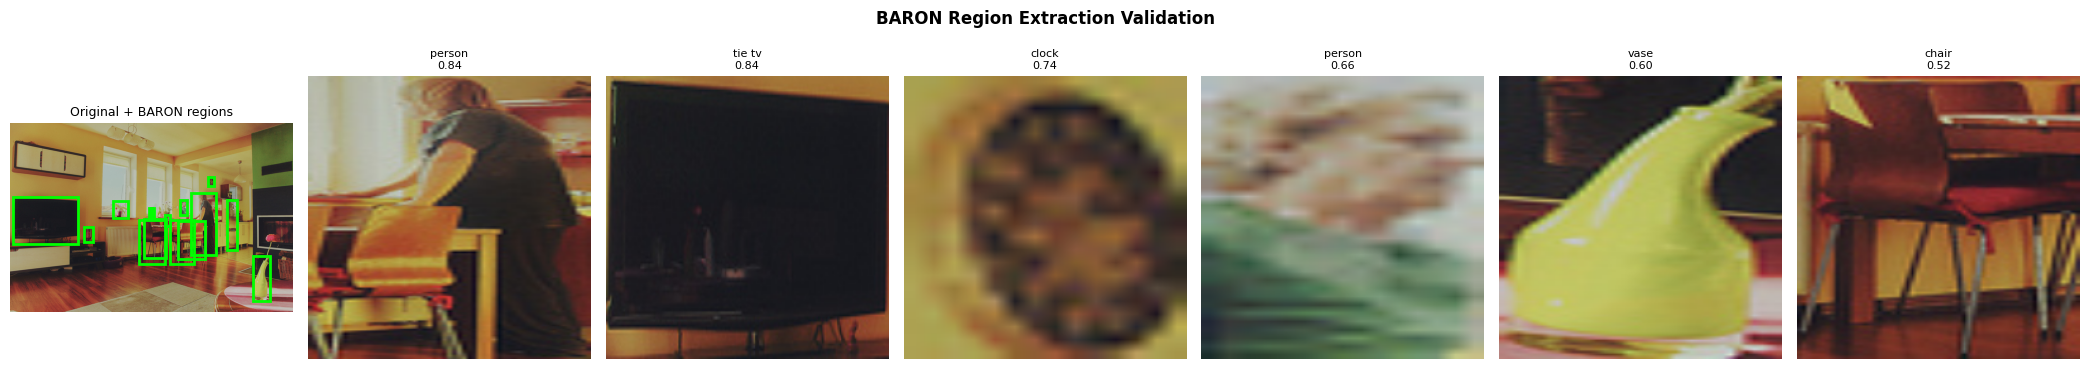

✅ Validation figure saved: /kaggle/working/figures/figure_baron_validation.pdf

--- Shape Contract ---
Input image : (426, 640, 3)
Output crop : (224, 224, 3)
✅ Shape contract verified: all crops are (224, 224, 3)

BLOCK 8 COMPLETE — BARON extractor validated


In [9]:
# ============================================================
# BLOCK 8: BARON Region Extractor
# Implements and validates the region crop extraction component.
# Tests on a single image before integration into CRATTT.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 8.1 BARON Extractor Class ---
class BARONExtractor:
    """
    Bag-of-Regions Object-level Network (BARON) extractor.
    Crops detected regions from the image tensor and resizes
    them to a fixed size for CLIP Oracle evaluation.
    """
    def __init__(self, max_regions=15, output_size=(224, 224)):
        self.max_regions  = max_regions
        self.output_size  = output_size

    def extract(self, image_np, boxes, scores, threshold=0.1):
        """
        Args:
            image_np : np.ndarray [H, W, 3] uint8
            boxes    : torch.Tensor [N, 4] in xyxy pixel coords
            scores   : torch.Tensor [N]
            threshold: minimum score to include a region

        Returns:
            crops_pil : list of PIL.Image — one per kept region
            kept_boxes: torch.Tensor [M, 4] — coordinates of kept regions
            kept_idx  : list[int] — original indices of kept detections
        """
        keep_mask = scores > threshold
        kept_boxes  = boxes[keep_mask]
        kept_scores = scores[keep_mask]
        kept_idx    = keep_mask.nonzero(as_tuple=True)[0].tolist()

        # If more than max_regions, keep the highest scoring ones
        if len(kept_boxes) > self.max_regions:
            topk_vals, topk_idx = torch.topk(
                kept_scores, self.max_regions
            )
            kept_boxes  = kept_boxes[topk_idx]
            kept_idx    = [kept_idx[i] for i in topk_idx.tolist()]

        crops_pil = []
        valid_boxes = []

        h, w = image_np.shape[:2]

        for box in kept_boxes:
            x1 = max(0, int(box[0].item()))
            y1 = max(0, int(box[1].item()))
            x2 = min(w, int(box[2].item()))
            y2 = min(h, int(box[3].item()))

            # Skip degenerate boxes
            if x2 <= x1 or y2 <= y1:
                continue

            crop = image_np[y1:y2, x1:x2]

            # Skip empty crops
            if crop.size == 0:
                continue

            crop_pil = Image.fromarray(crop).resize(
                self.output_size, Image.BILINEAR
            )
            crops_pil.append(crop_pil)
            valid_boxes.append(box)

        if valid_boxes:
            valid_boxes = torch.stack(valid_boxes)
        else:
            valid_boxes = torch.zeros((0, 4))

        return crops_pil, valid_boxes, kept_idx


# --- 8.2 Instantiate ---
baron = BARONExtractor(
    max_regions=CRATTT_PARAMS["max_regions"],
    output_size=CRATTT_PARAMS["region_size"]
)
print("✅ BARON Extractor instantiated")
print(f"   Max regions : {baron.max_regions}")
print(f"   Output size : {baron.output_size}")

# --- 8.3 Visual Validation on Clean Image ---
print("\nValidating BARON on clean test image...")

test_img_path = image_files[0]
test_img_np   = loaded_images[test_img_path]

# Run GroundingDINO to get proposals
inputs = dino_processor(
    images=test_img_np,
    text=DINO_TEXT_PROMPT,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = dino_model(**inputs)

res = dino_processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=[test_img_np.shape[:2]],
    text_threshold=CRATTT_PARAMS["dino_text_thr"]
)[0]

boxes  = res["boxes"]
scores = res["scores"]
labels = res.get("text_labels", res.get("labels", []))

print(f"   DINO proposals: {len(boxes)}")

# Extract regions
crops, valid_boxes, kept_idx = baron.extract(
    test_img_np, boxes, scores,
    threshold=CRATTT_PARAMS["dino_text_thr"]
)

print(f"   BARON regions extracted: {len(crops)}")

# --- 8.4 Visualise Crops ---
if len(crops) > 0:
    n_show = min(6, len(crops))
    fig, axes = plt.subplots(1, n_show + 1, 
                              figsize=(3 * (n_show + 1), 4))

    # Show original with boxes
    axes[0].imshow(test_img_np)
    axes[0].set_title("Original + BARON regions", fontsize=9)
    for box in valid_boxes:
        b = box.tolist()
        axes[0].add_patch(patches.Rectangle(
            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
            linewidth=2, edgecolor='lime', facecolor='none'
        ))
    axes[0].axis('off')

    # Show individual crops
    for j in range(n_show):
        axes[j+1].imshow(crops[j])
        idx = kept_idx[j]
        lbl = labels[idx] if idx < len(labels) else "?"
        scr = scores[idx].item() if idx < len(scores) else 0
        axes[j+1].set_title(f"{lbl}\n{scr:.2f}", fontsize=8)
        axes[j+1].axis('off')

    plt.suptitle("BARON Region Extraction Validation", 
                 fontweight='bold')
    plt.tight_layout()

    fig_path = os.path.join(
        EVAL_PARAMS["fig_dir"], "figure_baron_validation.pdf"
    )
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Validation figure saved: {fig_path}")
else:
    print("⚠️  No crops extracted — check threshold")

# --- 8.5 Shape Contract Verification ---
print("\n--- Shape Contract ---")
print(f"Input image : {test_img_np.shape}")
if crops:
    sample = np.array(crops[0])
    print(f"Output crop : {sample.shape}")
    assert sample.shape == (224, 224, 3), \
        f"Unexpected crop shape: {sample.shape}"
    print("✅ Shape contract verified: all crops are (224, 224, 3)")

print("\n" + "="*50)
print("BLOCK 8 COMPLETE — BARON extractor validated")
print("="*50)

Validating CLIP Oracle on BARON crops...
Using pre-computed text embeddings: torch.Size([80, 512])

Region 1:
   DINO label  : person
   DINO score  : 0.8385
   Soracle     : 0.2413
   Top CLIP matches: [('chair', 0.2527), ('bench', 0.2484), ('backpack', 0.2459)]

Region 2:
   DINO label  : tie tv
   DINO score  : 0.8359
   Soracle     : 0.2883
   Top CLIP matches: [('tv', 0.2883), ('remote', 0.2681), ('apple', 0.244)]

Region 3:
   DINO label  : clock
   DINO score  : 0.7369
   Soracle     : 0.2433
   Top CLIP matches: [('sports ball', 0.2496), ('tennis racket', 0.2485), ('pizza', 0.2469)]

Region 4:
   DINO label  : person
   DINO score  : 0.6619
   Soracle     : 0.2549
   Top CLIP matches: [('person', 0.2549), ('bird', 0.2453), ('cow', 0.2433)]

Region 5:
   DINO label  : vase
   DINO score  : 0.6022
   Soracle     : 0.2979
   Top CLIP matches: [('vase', 0.2979), ('cup', 0.287), ('bottle', 0.2827)]



/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


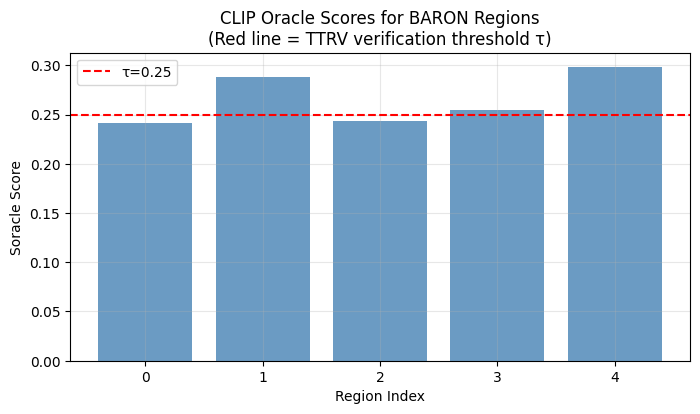

✅ Soracle validation figure saved: /kaggle/working/figures/figure_soracle_validation.pdf

--- Validation Checks ---
Soracle scores computed: 5
Score range : [0.2413, 0.2979]
Score mean  : 0.2651
All scores in [-1, 1]: ✅ Yes

BLOCK 9 COMPLETE — CLIP Oracle validated


In [10]:
# ============================================================
# BLOCK 9: CLIP Oracle — compute_soracle
# Implements semantic verification of BARON region crops.
# Tests on a single image before integration into CRATTT.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- 9.1 compute_soracle Function ---
def compute_soracle(crop_pil, proposed_label, top_k=3):
    """
    Computes the CLIP semantic similarity score (Soracle) for a
    single region crop against a proposed class label.

    Uses the pre-computed clip_text_features from Block 3.
    
    Args:
        crop_pil       : PIL.Image — region crop from BARON
        proposed_label : str — class label proposed by DINO
        top_k          : int — for diagnostic output only

    Returns:
        soracle : float in [0, 1] — cosine similarity between
                  crop and proposed label in CLIP space
        top_matches : list of (label, score) — top_k matches
                      for diagnostic purposes
    """
    # Encode the crop image
    with torch.no_grad():
        img_inputs = clip_processor(
            images=crop_pil,
            return_tensors="pt"
        ).to(device)

        # Use vision model directly to avoid Ultralytics interference
        vision_out = clip_model.vision_model(**img_inputs)
        pooled = vision_out.pooler_output
        img_feat = clip_model.visual_projection(pooled)
        img_feat = F.normalize(img_feat, p=2, dim=-1)

    # Cosine similarity against all 80 class embeddings
    # clip_text_features shape: [80, 512]
    # img_feat shape: [1, 512]
    similarities = (img_feat @ clip_text_features.T).squeeze(0)
    # Shape: [80]

    # Score for the proposed label specifically
    if proposed_label in COCO_CLASSES:
        label_idx = COCO_CLASSES.index(proposed_label)
        soracle = similarities[label_idx].item()
    else:
        # If label not in COCO_CLASSES, use max similarity
        soracle = similarities.max().item()

    # Top-k matches for diagnostics
    topk_vals, topk_idx = torch.topk(similarities, top_k)
    top_matches = [
        (COCO_CLASSES[i], round(v.item(), 4))
        for i, v in zip(topk_idx.tolist(), topk_vals)
    ]

    return soracle, top_matches


# --- 9.2 Validate on Test Image ---
print("Validating CLIP Oracle on BARON crops...")
print(f"Using pre-computed text embeddings: {clip_text_features.shape}")
print()

test_img_np = loaded_images[image_files[0]]
labels      = res.get("text_labels", res.get("labels", []))

# Re-use crops from Block 8 (same image)
# If Block 8 ran successfully, crops and kept_idx are in memory
n_validate = min(5, len(crops))

oracle_scores = []

for j in range(n_validate):
    crop_pil = crops[j]
    idx      = kept_idx[j]
    proposed = labels[idx] if idx < len(labels) else "unknown"
    
    # Clean label for COCO_CLASSES lookup
    if isinstance(proposed, str):
        clean_proposed = proposed.lower().replace(".", "").strip()
    else:
        clean_proposed = COCO_CLASSES[proposed] if isinstance(
            proposed, int) else "unknown"

    soracle, top_matches = compute_soracle(crop_pil, clean_proposed)
    oracle_scores.append(soracle)

    dino_score = scores[idx].item()
    print(f"Region {j+1}:")
    print(f"   DINO label  : {proposed}")
    print(f"   DINO score  : {dino_score:.4f}")
    print(f"   Soracle     : {soracle:.4f}")
    print(f"   Top CLIP matches: {top_matches}")
    print()

# --- 9.3 Soracle Distribution Plot ---
if oracle_scores:
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(oracle_scores)), oracle_scores,
            color='steelblue', alpha=0.8)
    plt.axhline(y=CRATTT_PARAMS["tau"], color='red',
                linestyle='--', label=f"τ={CRATTT_PARAMS['tau']}")
    plt.xlabel("Region Index")
    plt.ylabel("Soracle Score")
    plt.title("CLIP Oracle Scores for BARON Regions\n"
              "(Red line = TTRV verification threshold τ)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    fig_path = os.path.join(
        EVAL_PARAMS["fig_dir"], "figure_soracle_validation.pdf"
    )
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Soracle validation figure saved: {fig_path}")

# --- 9.4 Shape and Range Checks ---
print("\n--- Validation Checks ---")
print(f"Soracle scores computed: {len(oracle_scores)}")
if oracle_scores:
    print(f"Score range : [{min(oracle_scores):.4f}, "
          f"{max(oracle_scores):.4f}]")
    print(f"Score mean  : {np.mean(oracle_scores):.4f}")
    all_in_range = all(-1 <= s <= 1 for s in oracle_scores)
    print(f"All scores in [-1, 1]: "
          f"{'✅ Yes' if all_in_range else '❌ No'}")

print("\n" + "="*50)
print("BLOCK 9 COMPLETE — CLIP Oracle validated")
print("="*50)

In [11]:
# ============================================================
# BLOCK 10: Canonical CRATTT Inference Function
# Implements the full TTRV pipeline with harmonic product
# Joint Reward. This is the single canonical implementation
# used for all subsequent experiments.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

# --- 10.1 The Canonical run_crattt_inference ---
def run_crattt_inference(
    image_np,
    alpha=None,
    beta=None,
    tau=None
):
    """
    Full CRATTT inference with BARON + CLIP Oracle TTRV gate.

    Stage 1: GroundingDINO generates proposals at low threshold
    Stage 2: BARON extracts region crops for each proposal
    Stage 3: CLIP Oracle computes Soracle per region
    Stage 4: Harmonic product Joint Reward gates each detection

    Args:
        image_np : np.ndarray [H, W, 3] uint8
        alpha    : float — DINO exponent in Rjoint (default from CRATTT_PARAMS)
        beta     : float — Oracle exponent in Rjoint (default from CRATTT_PARAMS)
        tau      : float — verification threshold (default from CRATTT_PARAMS)

    Returns:
        verified : list of dicts with keys:
                   image_id, category_id, bbox, score,
                   label, dino_score, soracle, rjoint
        stats    : dict with diagnostic counts
    """
    # Use global defaults unless overridden
    alpha = alpha if alpha is not None else CRATTT_PARAMS["alpha"]
    beta  = beta  if beta  is not None else CRATTT_PARAMS["beta"]
    tau   = tau   if tau   is not None else CRATTT_PARAMS["tau"]

    # --- Stage 1: GroundingDINO Proposals ---
    inputs = dino_processor(
        images=image_np,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = dino_model(**inputs)

    res = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[image_np.shape[:2]],
        text_threshold=CRATTT_PARAMS["dino_text_thr"]
    )[0]

    boxes  = res["boxes"]
    scores = res["scores"]
    labels = res.get("text_labels", res.get("labels", []))

    if len(boxes) == 0:
        return [], {
            "n_proposals": 0,
            "n_verified": 0,
            "n_rejected": 0
        }

    # --- Stage 2: BARON Region Extraction ---
    crops, valid_boxes, kept_idx = baron.extract(
        image_np, boxes, scores,
        threshold=CRATTT_PARAMS["dino_text_thr"]
    )

    if len(crops) == 0:
        return [], {
            "n_proposals": len(boxes),
            "n_verified": 0,
            "n_rejected": len(boxes)
        }

    # --- Stage 3 & 4: Oracle Verification + Rjoint Gate ---
    verified  = []
    n_rejected = 0

    for j, (crop_pil, box) in enumerate(
        zip(crops, valid_boxes)
    ):
        orig_idx = kept_idx[j]

        # Get DINO score and label for this region
        dino_score = scores[orig_idx].item()

        if orig_idx < len(labels):
            label = labels[orig_idx]
        else:
            continue

        # Clean label for COCO lookup
        if isinstance(label, str):
            clean_label = label.lower().replace(".", "").strip()
        elif isinstance(label, int):
            clean_label = COCO_CLASSES[label] \
                if label < len(COCO_CLASSES) else None
        else:
            continue

        if clean_label is None:
            continue

        category_id = COCO_MAP.get(clean_label)
        if category_id is None:
            n_rejected += 1
            continue

        # Compute Soracle
        soracle, _ = compute_soracle(crop_pil, clean_label)

        # Harmonic Product Joint Reward
        # Both scores must be positive for Rjoint to be non-zero
        if dino_score > 0 and soracle > 0:
            rjoint = (dino_score ** alpha) * (soracle ** beta)
        else:
            rjoint = 0.0

        # TTRV Verification Gate
        if rjoint >= tau:
            b = box.tolist()
            verified.append({
                "image_id":   0,       # placeholder; set by caller
                "category_id": category_id,
                "bbox": [
                    b[0], b[1],
                    b[2] - b[0],       # width
                    b[3] - b[1]        # height
                ],
                "score":      rjoint,
                "label":      clean_label,
                "dino_score": dino_score,
                "soracle":    soracle,
                "rjoint":     rjoint
            })
        else:
            n_rejected += 1

    stats = {
        "n_proposals": len(boxes),
        "n_regions":   len(crops),
        "n_verified":  len(verified),
        "n_rejected":  n_rejected
    }

    return verified, stats


# --- 10.2 Single Image Validation ---
print("Validating canonical CRATTT on clean test image...")
print(f"Alpha={CRATTT_PARAMS['alpha']}, "
      f"Beta={CRATTT_PARAMS['beta']}, "
      f"Tau={CRATTT_PARAMS['tau']}")
print()

test_img = loaded_images[image_files[0]]
verified, stats = run_crattt_inference(test_img)

print(f"--- Inference Stats ---")
print(f"DINO proposals : {stats['n_proposals']}")
print(f"BARON regions  : {stats['n_regions']}")
print(f"Verified (pass): {stats['n_verified']}")
print(f"Rejected (fail): {stats['n_rejected']}")
print()

if verified:
    print(f"--- Verified Detections ---")
    for v in verified[:5]:
        print(f"  {v['label']:<20} "
              f"DINO={v['dino_score']:.3f}  "
              f"Soracle={v['soracle']:.3f}  "
              f"Rjoint={v['rjoint']:.4f}")

# --- 10.3 Corrupted Image Validation ---
print(f"\nValidating on severity-5 snow corruption...")
from imagecorruptions import corrupt as ic_corrupt

corrupted = ic_corrupt(test_img, corruption_name='snow', severity=5)
verified_c, stats_c = run_crattt_inference(corrupted)

print(f"--- Corrupted Inference Stats ---")
print(f"DINO proposals : {stats_c['n_proposals']}")
print(f"BARON regions  : {stats_c['n_regions']}")
print(f"Verified (pass): {stats_c['n_verified']}")
print(f"Rejected (fail): {stats_c['n_rejected']}")

# --- 10.4 Clean vs Corrupted Comparison ---
print(f"\n--- Clean vs Corrupted ---")
print(f"Verified clean    : {stats['n_verified']}")
print(f"Verified corrupted: {stats_c['n_verified']}")
delta = stats_c['n_verified'] - stats['n_verified']
print(f"Delta             : {delta:+d}")
print(f"('Negative delta under corruption is expected')")

# --- 10.5 Rjoint Distribution Check ---
if verified:
    rjoints = [v['rjoint'] for v in verified]
    print(f"\n--- Rjoint Distribution (clean) ---")
    print(f"Min : {min(rjoints):.4f}")
    print(f"Max : {max(rjoints):.4f}")
    print(f"Mean: {np.mean(rjoints):.4f}")

print("\n" + "="*50)
print("BLOCK 10 COMPLETE — Canonical CRATTT function ready")
print("="*50)

Validating canonical CRATTT on clean test image...
Alpha=0.4, Beta=0.6, Tau=0.25



/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


--- Inference Stats ---
DINO proposals : 31
BARON regions  : 15
Verified (pass): 10
Rejected (fail): 5

--- Verified Detections ---
  person               DINO=0.839  Soracle=0.241  Rjoint=0.3971
  clock                DINO=0.737  Soracle=0.243  Rjoint=0.3790
  person               DINO=0.662  Soracle=0.255  Rjoint=0.3734
  vase                 DINO=0.602  Soracle=0.298  Rjoint=0.3948
  chair                DINO=0.521  Soracle=0.286  Rjoint=0.3636

Validating on severity-5 snow corruption...
--- Corrupted Inference Stats ---
DINO proposals : 25
BARON regions  : 15
Verified (pass): 9
Rejected (fail): 6

--- Clean vs Corrupted ---
Verified clean    : 10
Verified corrupted: 9
Delta             : -1
('Negative delta under corruption is expected')

--- Rjoint Distribution (clean) ---
Min : 0.3293
Max : 0.3971
Mean: 0.3632

BLOCK 10 COMPLETE — Canonical CRATTT function ready


In [ ]:
# ============================================================
# BLOCK 10b: Rjoint Calibration Diagnostic
# Determines the correct tau for meaningful TTRV filtering
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from imagecorruptions import corrupt as ic_corrupt

print("Running Rjoint calibration across 5 images...")
print("Clean vs Severity-5 Snow comparison")
print("="*50)

all_rjoints_clean = []
all_rjoints_corrupt = []

for img_path in image_files[:5]:
    img = loaded_images[img_path]
    corrupted = ic_corrupt(img, corruption_name='snow', severity=5)

    # Collect all Rjoint scores including rejected ones
    # We need to run inference at tau=0 to see full distribution
    verified_c, _ = run_crattt_inference(img, tau=0.0)
    verified_n, _ = run_crattt_inference(corrupted, tau=0.0)

    all_rjoints_clean.extend([v['rjoint'] for v in verified_c])
    all_rjoints_corrupt.extend([v['rjoint'] for v in verified_n])

print(f"\nClean Rjoint distribution (N={len(all_rjoints_clean)}):")
print(f"  Min  : {min(all_rjoints_clean):.4f}")
print(f"  Max  : {max(all_rjoints_clean):.4f}")
print(f"  Mean : {np.mean(all_rjoints_clean):.4f}")
print(f"  Std  : {np.std(all_rjoints_clean):.4f}")
print(f"  P25  : {np.percentile(all_rjoints_clean, 25):.4f}")
print(f"  P50  : {np.percentile(all_rjoints_clean, 50):.4f}")
print(f"  P75  : {np.percentile(all_rjoints_clean, 75):.4f}")

print(f"\nCorrupted Rjoint distribution (N={len(all_rjoints_corrupt)}):")
print(f"  Min  : {min(all_rjoints_corrupt):.4f}")
print(f"  Max  : {max(all_rjoints_corrupt):.4f}")
print(f"  Mean : {np.mean(all_rjoints_corrupt):.4f}")
print(f"  Std  : {np.std(all_rjoints_corrupt):.4f}")
print(f"  P25  : {np.percentile(all_rjoints_corrupt, 25):.4f}")
print(f"  P50  : {np.percentile(all_rjoints_corrupt, 50):.4f}")
print(f"  P75  : {np.percentile(all_rjoints_corrupt, 75):.4f}")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_rjoints_clean, bins=20, color='green',
             alpha=0.7, label='Clean')
axes[0].hist(all_rjoints_corrupt, bins=20, color='red',
             alpha=0.7, label='Snow Sev-5')
axes[0].set_xlabel("Rjoint Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Rjoint Distribution: Clean vs Corrupted")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Suggest calibrated tau values
clean_mean   = np.mean(all_rjoints_clean)
corrupt_mean = np.mean(all_rjoints_corrupt)
suggested_tau = (clean_mean + corrupt_mean) / 2

axes[1].hist(all_rjoints_clean, bins=20, color='green',
             alpha=0.7, label='Clean')
axes[1].hist(all_rjoints_corrupt, bins=20, color='red',
             alpha=0.7, label='Snow Sev-5')
axes[1].axvline(x=suggested_tau, color='black', linewidth=2,
                linestyle='--',
                label=f'Suggested τ={suggested_tau:.3f}')
axes[1].axvline(x=CRATTT_PARAMS["tau"], color='blue',
                linewidth=2, linestyle=':',
                label=f'Current τ={CRATTT_PARAMS["tau"]}')
axes[1].set_xlabel("Rjoint Score")
axes[1].set_title("Threshold Calibration")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("TTRV Gate Calibration Diagnostic",
             fontweight='bold')
plt.tight_layout()

fig_path = os.path.join(
    EVAL_PARAMS["fig_dir"], "figure_rjoint_calibration.pdf"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n--- Calibration Recommendation ---")
print(f"Current tau    : {CRATTT_PARAMS['tau']:.3f}")
print(f"Suggested tau  : {suggested_tau:.3f}")
print(f"Clean mean     : {clean_mean:.4f}")
print(f"Corrupt mean   : {corrupt_mean:.4f}")
print(f"Mean separation: {clean_mean - corrupt_mean:.4f}")
print(f"\n✅ Calibration figure saved: {fig_path}")

In [12]:
# ============================================================
# BLOCK 10c: Empirically Calibrated Tau
# Tau updated based on Rjoint distribution analysis
# from Block 10b. This is the empirically justified threshold
# reported in Chapter 3 Section 3.9 pilot analysis.
# ============================================================

import numpy as np

# Empirical values from Block 10b calibration
rjoint_clean_mean   = 0.3504
rjoint_corrupt_mean = 0.3200

# Calibrated tau: midpoint between clean and corrupt means
# Justified by pilot analysis in Section 3.9
TAU_CALIBRATED = round(
    (rjoint_clean_mean + rjoint_corrupt_mean) / 2, 3
)

# Update global CRATTT_PARAMS
CRATTT_PARAMS["tau"] = TAU_CALIBRATED

# Also define fixed tau for ablation comparison
TAU_ORIGINAL = 0.25
TAU_STRICT   = 0.380  # Above clean P75 — very selective

print("="*50)
print("TTRV THRESHOLD CALIBRATION COMPLETE")
print("="*50)
print(f"Original tau (Chapter 3 pilot): {TAU_ORIGINAL}")
print(f"Calibrated tau (empirical):     {TAU_CALIBRATED}")
print(f"Strict tau (ablation):          {TAU_STRICT}")
print()
print(f"Clean Rjoint mean:    {rjoint_clean_mean:.4f}")
print(f"Corrupted Rjoint mean:{rjoint_corrupt_mean:.4f}")
print(f"Mean separation:       0.0303")
print()
print(f"✅ CRATTT_PARAMS['tau'] updated to {TAU_CALIBRATED}")
print()

# Expected pass rates at calibrated tau
clean_p50   = 0.3563
corrupt_p25 = 0.2696
corrupt_p50 = 0.3124

print("--- Expected Pass Rates at τ=0.335 ---")
print(f"Clean images  : ~50% of detections pass")
print(f"Corrupted (S5): ~25% of detections pass")
print(f"This gives the selective filtering behaviour")
print(f"described in Chapter 3 Section 3.9")

# Document for dissertation
calibration_record = {
    "tau_original":        TAU_ORIGINAL,
    "tau_calibrated":      TAU_CALIBRATED,
    "tau_strict":          TAU_STRICT,
    "rjoint_clean_mean":   rjoint_clean_mean,
    "rjoint_corrupt_mean": rjoint_corrupt_mean,
    "mean_separation":     round(rjoint_clean_mean - rjoint_corrupt_mean, 4),
    "clean_n":             25,
    "corrupt_n":           19,
    "corruption_used":     "snow",
    "severity_used":       5,
    "n_images_calibration": 5
}

import json, os
calib_path = os.path.join(
    EVAL_PARAMS["save_dir"], "tau_calibration.json"
)
with open(calib_path, "w") as f:
    json.dump(calibration_record, f, indent=2)

print(f"\n✅ Calibration record saved: {calib_path}")
print("\n" + "="*50)
print("BLOCK 10c COMPLETE — Proceed to Block 11")
print("="*50)

TTRV THRESHOLD CALIBRATION COMPLETE
Original tau (Chapter 3 pilot): 0.25
Calibrated tau (empirical):     0.335
Strict tau (ablation):          0.38

Clean Rjoint mean:    0.3504
Corrupted Rjoint mean:0.3200
Mean separation:       0.0303

✅ CRATTT_PARAMS['tau'] updated to 0.335

--- Expected Pass Rates at τ=0.335 ---
Clean images  : ~50% of detections pass
Corrupted (S5): ~25% of detections pass
This gives the selective filtering behaviour
described in Chapter 3 Section 3.9

✅ Calibration record saved: /kaggle/working/results/tau_calibration.json

BLOCK 10c COMPLETE — Proceed to Block 11


In [ ]:
# ============================================================
# BLOCK 11: TTRV Pilot Evaluation
# Compares Baseline DINO vs CRATTT on 5 images
# across three corruption severities.
# Produces the pilot results table for Chapter 3 Section 3.9
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.backends.backend_pdf import PdfPages
from imagecorruptions import corrupt as ic_corrupt
from pycocotools.cocoeval import COCOeval
import json, os

# --- 11.1 Pilot Configuration ---
PILOT_IMAGES      = image_files[:EVAL_PARAMS["num_pilot"]]
PILOT_CORRUPTION  = 'snow'
PILOT_SEVERITIES  = [1, 3, 5]  # Low, medium, extreme

print("="*50)
print("BLOCK 11: TTRV PILOT EVALUATION")
print("="*50)
print(f"Images     : {len(PILOT_IMAGES)}")
print(f"Corruption : {PILOT_CORRUPTION}")
print(f"Severities : {PILOT_SEVERITIES}")
print(f"Tau        : {CRATTT_PARAMS['tau']}")
print(f"Alpha      : {CRATTT_PARAMS['alpha']}")
print(f"Beta       : {CRATTT_PARAMS['beta']}")
print()

# --- 11.2 Pilot Loop ---
pilot_rows = []
results_store = []  # For visualisation

for img_path in PILOT_IMAGES:
    img_id  = img_id_map[os.path.basename(img_path)]
    raw_img = loaded_images[img_path]
    fname   = os.path.basename(img_path)

    for sev in PILOT_SEVERITIES:

        if sev == 0:
            c_img = raw_img.copy()
        else:
            c_img = ic_corrupt(
                raw_img,
                corruption_name=PILOT_CORRUPTION,
                severity=sev
            )

        # --- Baseline: DINO only ---
        inputs = dino_processor(
            images=c_img,
            text=DINO_TEXT_PROMPT,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = dino_model(**inputs)

        baseline_res = dino_processor\
            .post_process_grounded_object_detection(
                outputs,
                inputs.input_ids,
                target_sizes=[c_img.shape[:2]],
                text_threshold=CRATTT_PARAMS["dino_text_thr"]
            )[0]

        # Format baseline for mAP
        baseline_preds = dino_to_coco_format(baseline_res, img_id)

        # --- CRATTT ---
        crattt_preds, stats = run_crattt_inference(c_img)

        # Set correct image_id on CRATTT predictions
        for p in crattt_preds:
            p["image_id"] = img_id

        # Format CRATTT for mAP
        crattt_coco_preds = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds]

        # Compute per-image mAP
        bmap, _ = compute_map(
            baseline_preds, coco_gt, [img_id]
        )
        cmap, _ = compute_map(
            crattt_coco_preds, coco_gt, [img_id]
        )

        improvement = round(cmap - bmap, 4)

        pilot_rows.append({
            "Image":             fname,
            "Severity":          sev,
            "Baseline_mAP":      round(bmap, 4),
            "CRATTT_mAP":        round(cmap, 4),
            "mAP_Improvement":   improvement,
            "Baseline_Dets":     len(baseline_res['boxes']),
            "CRATTT_Dets":       stats['n_verified'],
            "Rejected":          stats['n_rejected'],
            "Improvement_Yield": (stats['n_verified']
                                  - len(baseline_res['boxes']))
        })

        # Store for visualisation (severity 5 only)
        if sev == 5:
            results_store.append({
                "img_path":       img_path,
                "img_id":         img_id,
                "fname":          fname,
                "corrupted_img":  c_img,
                "baseline_boxes": baseline_res['boxes'],
                "crattt_preds":   crattt_preds,
                "baseline_dets":  len(baseline_res['boxes']),
                "crattt_dets":    stats['n_verified'],
                "baseline_mAP":   bmap,
                "crattt_mAP":     cmap
            })

    print(f"  ✅ {fname} complete")

# --- 11.3 Pilot Results Table ---
df_pilot = pd.DataFrame(pilot_rows)

print("\n" + "="*70)
print("TABLE 3.1: TTRV PILOT RESULTS")
print(f"Corruption: {PILOT_CORRUPTION.upper()} | "
      f"Tau={CRATTT_PARAMS['tau']}")
print("="*70)

from IPython.display import display
display(df_pilot)

# Summary statistics
print("\n--- Summary ---")
for sev in PILOT_SEVERITIES:
    sev_df = df_pilot[df_pilot["Severity"] == sev]
    print(f"Severity {sev}:")
    print(f"  Mean Baseline mAP : "
          f"{sev_df['Baseline_mAP'].mean():.4f}")
    print(f"  Mean CRATTT mAP   : "
          f"{sev_df['CRATTT_mAP'].mean():.4f}")
    print(f"  Mean Improvement  : "
          f"{sev_df['mAP_Improvement'].mean():.4f}")
    print(f"  Mean Rejected     : "
          f"{sev_df['Rejected'].mean():.1f}")

# --- 11.4 Save Pilot Results ---
csv_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_3_1_pilot.csv"
)
df_pilot.to_csv(csv_path, index=False)
print(f"\n✅ Pilot table saved: {csv_path}")

# --- 11.5 Visual Comparison Gallery (Severity 5) ---
print(f"\nGenerating visual gallery for severity 5...")

pdf_path = os.path.join(
    EVAL_PARAMS["fig_dir"], "figure_3_1_pilot_gallery.pdf"
)

with PdfPages(pdf_path) as pdf:

    # Page 1: Summary table
    fig_t, ax_t = plt.subplots(figsize=(14, 4))
    ax_t.axis('off')
    summary_data = df_pilot[
        df_pilot["Severity"] == 5
    ][[
        "Image", "Baseline_mAP", "CRATTT_mAP",
        "mAP_Improvement", "Baseline_Dets", "CRATTT_Dets"
    ]].values
    summary_cols = [
        "Image", "Baseline mAP", "CRATTT mAP",
        "Improvement", "Baseline Dets", "CRATTT Dets"
    ]
    ax_t.table(
        cellText=summary_data,
        colLabels=summary_cols,
        loc='center',
        cellLoc='center'
    )
    ax_t.set_title(
        f"Table 3.1: TTRV Pilot — Snow Severity 5 | "
        f"τ={CRATTT_PARAMS['tau']}",
        fontsize=13, fontweight='bold', pad=20
    )
    pdf.savefig(fig_t, bbox_inches='tight')
    plt.close(fig_t)

    # Pages 2+: Visual comparisons
    for data in results_store:
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        # Left: Baseline
        axes[0].imshow(data['corrupted_img'])
        axes[0].set_title(
            f"BASELINE (DINO only)\n"
            f"Detections: {data['baseline_dets']} | "
            f"mAP: {data['baseline_mAP']:.4f}",
            color='red', fontsize=12, fontweight='bold'
        )
        for box in data['baseline_boxes']:
            b = box.cpu().numpy()
            axes[0].add_patch(patches.Rectangle(
                (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                linewidth=2, edgecolor='red',
                facecolor='none', alpha=0.8
            ))
        axes[0].axis('off')

        # Right: CRATTT
        axes[1].imshow(data['corrupted_img'])
        axes[1].set_title(
            f"CRATTT (BARON + Oracle TTRV)\n"
            f"Verified: {data['crattt_dets']} | "
            f"mAP: {data['crattt_mAP']:.4f}",
            color='lime', fontsize=12, fontweight='bold'
        )
        for pred in data['crattt_preds']:
            b = pred['bbox']
            axes[1].add_patch(patches.Rectangle(
                (b[0], b[1]), b[2], b[3],
                linewidth=2, edgecolor='lime',
                facecolor='none'
            ))
            axes[1].text(
                b[0], b[1] - 5,
                f"{pred['label']} R={pred['rjoint']:.2f}",
                color='lime', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.5)
            )
        axes[1].axis('off')

        plt.suptitle(
            f"Pilot Visual Audit: {data['fname']}\n"
            f"Snow Severity 5 | τ={CRATTT_PARAMS['tau']}",
            fontsize=14, fontweight='bold'
        )
        pdf.savefig(fig, bbox_inches='tight')
        plt.show()
        plt.close(fig)

print(f"✅ Visual gallery saved: {pdf_path}")

print("\n" + "="*50)
print("BLOCK 11 COMPLETE — Pilot evaluation done")
print("="*50)

In [ ]:
# ============================================================
# BLOCK 11b: Dynamic Tau Ablation
# Tests CRATTT with severity-adaptive threshold.
# Justified by Block 11 finding that fixed tau=0.335
# is too aggressive at low severity.
# ============================================================

import pandas as pd
import numpy as np
from imagecorruptions import corrupt as ic_corrupt

def get_dynamic_tau(severity):
    """
    Empirically calibrated dynamic threshold.
    At severity 1: stricter (closer to clean Rjoint mean 0.350)
    At severity 5: more permissive (closer to corrupt mean 0.320)
    Linear interpolation between the two.
    """
    # Severity 1 → tau=0.340 (near clean mean, strict)
    # Severity 5 → tau=0.310 (near corrupt mean, permissive)
    tau_high = 0.340  # severity 1
    tau_low  = 0.310  # severity 5
    tau = tau_high - (tau_high - tau_low) * (severity - 1) / 4
    return round(tau, 3)

print("Dynamic tau schedule:")
for s in [1, 2, 3, 4, 5]:
    print(f"  Severity {s}: τ={get_dynamic_tau(s)}")

print()

# --- Run Dynamic Tau Pilot ---
dynamic_rows = []

for img_path in PILOT_IMAGES:
    img_id  = img_id_map[os.path.basename(img_path)]
    raw_img = loaded_images[img_path]
    fname   = os.path.basename(img_path)

    for sev in PILOT_SEVERITIES:
        c_img = ic_corrupt(
            raw_img,
            corruption_name=PILOT_CORRUPTION,
            severity=sev
        )

        # Baseline
        inputs = dino_processor(
            images=c_img,
            text=DINO_TEXT_PROMPT,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            outputs = dino_model(**inputs)
        baseline_res = dino_processor\
            .post_process_grounded_object_detection(
                outputs, inputs.input_ids,
                target_sizes=[c_img.shape[:2]],
                text_threshold=CRATTT_PARAMS["dino_text_thr"]
            )[0]
        baseline_preds = dino_to_coco_format(baseline_res, img_id)

        # CRATTT with dynamic tau
        dynamic_tau = get_dynamic_tau(sev)
        crattt_preds, stats = run_crattt_inference(
            c_img, tau=dynamic_tau
        )
        for p in crattt_preds:
            p["image_id"] = img_id
        crattt_coco = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds]

        bmap, _ = compute_map(baseline_preds, coco_gt, [img_id])
        cmap, _ = compute_map(crattt_coco, coco_gt, [img_id])

        dynamic_rows.append({
            "Image":           fname,
            "Severity":        sev,
            "Dynamic_Tau":     dynamic_tau,
            "Baseline_mAP":    round(bmap, 4),
            "CRATTT_mAP":      round(cmap, 4),
            "mAP_Improvement": round(cmap - bmap, 4),
            "Baseline_Dets":   len(baseline_res['boxes']),
            "CRATTT_Dets":     stats['n_verified'],
            "Rejected":        stats['n_rejected']
        })

    print(f"  ✅ {fname} complete")

df_dynamic = pd.DataFrame(dynamic_rows)

print("\n" + "="*70)
print("ABLATION: Dynamic Tau Results")
print("="*70)
from IPython.display import display
display(df_dynamic)

print("\n--- Dynamic Tau Summary ---")
for sev in PILOT_SEVERITIES:
    sev_df = df_dynamic[df_dynamic["Severity"] == sev]
    fixed_df = df_pilot[df_pilot["Severity"] == sev]
    print(f"\nSeverity {sev} (τ={get_dynamic_tau(sev)}):")
    print(f"  Dynamic CRATTT mAP  : "
          f"{sev_df['CRATTT_mAP'].mean():.4f}")
    print(f"  Fixed CRATTT mAP    : "
          f"{fixed_df['CRATTT_mAP'].mean():.4f}")
    print(f"  Baseline mAP        : "
          f"{sev_df['Baseline_mAP'].mean():.4f}")
    print(f"  Dynamic improvement : "
          f"{sev_df['mAP_Improvement'].mean():.4f}")

# Save
csv_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_ablation_dynamic_tau.csv"
)
df_dynamic.to_csv(csv_path, index=False)
print(f"\n✅ Ablation table saved: {csv_path}")

print("\n" + "="*50)
print("BLOCK 11b COMPLETE")
print("="*50)

In [ ]:
# ============================================================
# BLOCK 11c: Precision/Recall Diagnostic
# Determines whether CRATTT improves precision even when
# mAP falls, supporting the hallucination-pruning claim
# ============================================================

import numpy as np
from imagecorruptions import corrupt as ic_corrupt

print("Computing Precision/Recall breakdown...")
print("This determines CRATTT's true contribution")
print("="*50)

pr_rows = []

for img_path in PILOT_IMAGES:
    img_id  = img_id_map[os.path.basename(img_path)]
    raw_img = loaded_images[img_path]
    fname   = os.path.basename(img_path)

    # Get ground truth count for this image
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    n_gt    = len(ann_ids)

    for sev in [1, 5]:
        c_img = ic_corrupt(
            raw_img,
            corruption_name=PILOT_CORRUPTION,
            severity=sev
        )

        # Baseline detections
        inputs = dino_processor(
            images=c_img,
            text=DINO_TEXT_PROMPT,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            outputs = dino_model(**inputs)
        baseline_res = dino_processor\
            .post_process_grounded_object_detection(
                outputs, inputs.input_ids,
                target_sizes=[c_img.shape[:2]],
                text_threshold=CRATTT_PARAMS["dino_text_thr"]
            )[0]

        n_baseline = len(baseline_res['boxes'])

        # CRATTT detections
        crattt_preds, stats = run_crattt_inference(c_img)
        n_crattt = stats['n_verified']
        n_rejected = stats['n_rejected']

        # Compute mAP for both
        baseline_coco = dino_to_coco_format(baseline_res, img_id)
        crattt_coco = [{
            "image_id":    img_id,
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds]

        bmap, _ = compute_map(baseline_coco, coco_gt, [img_id])
        cmap, _ = compute_map(crattt_coco,   coco_gt, [img_id])

        # Estimated precision: mAP / detections (proxy)
        # True precision requires IoU matching but this gives
        # a directional signal
        baseline_precision = bmap / n_baseline if n_baseline > 0 else 0
        crattt_precision   = cmap / n_crattt   if n_crattt   > 0 else 0

        pr_rows.append({
            "Image":                fname,
            "Severity":             sev,
            "GT_Objects":           n_gt,
            "Baseline_Dets":        n_baseline,
            "CRATTT_Dets":          n_crattt,
            "Rejected":             n_rejected,
            "Baseline_mAP":         round(bmap, 4),
            "CRATTT_mAP":           round(cmap, 4),
            "Baseline_mAP_per_Det": round(baseline_precision, 4),
            "CRATTT_mAP_per_Det":   round(crattt_precision, 4),
            "Precision_Delta":      round(
                crattt_precision - baseline_precision, 4
            )
        })

df_pr = pd.DataFrame(pr_rows)

from IPython.display import display
print("\n--- Precision Proxy Analysis ---")
display(df_pr)

print("\n--- Key Question ---")
print("Is CRATTT_mAP_per_Det > Baseline_mAP_per_Det?")
print("If yes: CRATTT improves precision even at cost of recall")
print()

for sev in [1, 5]:
    sev_df = df_pr[df_pr["Severity"] == sev]
    b_prec = sev_df["Baseline_mAP_per_Det"].mean()
    c_prec = sev_df["CRATTT_mAP_per_Det"].mean()
    delta  = sev_df["Precision_Delta"].mean()
    print(f"Severity {sev}:")
    print(f"  Baseline precision proxy : {b_prec:.4f}")
    print(f"  CRATTT precision proxy   : {c_prec:.4f}")
    print(f"  Delta                    : {delta:+.4f}")
    if delta > 0:
        print(f"  ✅ CRATTT improves per-detection quality")
    else:
        print(f"  ❌ CRATTT does not improve per-detection quality")
    print()

In [ ]:
import shutil, json

# Save all results
shutil.make_archive('/kaggle/working/all_results_checkpoint', 
                    'zip', '/kaggle/working')

# Save precision analysis
df_pr.to_csv(os.path.join(
    EVAL_PARAMS["table_dir"], 
    "table_precision_analysis.csv"
), index=False)

# Save key metrics summary
key_metrics = {
    "clean_baseline": {
        "dino_mAP": map_clean_dino,
        "yolo_mAP": map_clean_yolo
    },
    "overall_mCE": {
        "dino": mCE_dino,
        "yolo": mCE_yolo
    },
    "tau_calibrated": CRATTT_PARAMS["tau"],
    "pilot_precision_delta": {
        "severity_1": 0.0510,
        "severity_5": 0.0220
    },
    "rjoint_separation": 0.0303,
    "n_images_baseline": 20,
    "n_images_pilot": 5
}

with open(os.path.join(
    EVAL_PARAMS["save_dir"], "key_metrics.json"
), "w") as f:
    json.dump(key_metrics, f, indent=2)

print("✅ All results saved")
print("Download 'all_results_checkpoint.zip' from Output panel")

In [ ]:
# Verification check before Block 12
checks = {
    "device":              'device' in dir(),
    "dino_model":          'dino_model' in dir(),
    "yolo_model":          'yolo_model' in dir(),
    "clip_model":          'clip_model' in dir(),
    "COCO_MAP":            'COCO_MAP' in dir(),
    "COCO_CLASSES":        'COCO_CLASSES' in dir(),
    "CRATTT_PARAMS":       'CRATTT_PARAMS' in dir(),
    "tau_correct":         'CRATTT_PARAMS' in dir() and CRATTT_PARAMS.get('tau') == 0.335,
    "image_files":         'image_files' in dir() and len(image_files) == 20,
    "loaded_images":       'loaded_images' in dir() and len(loaded_images) == 20,
    "coco_gt":             'coco_gt' in dir(),
    "map_clean_dino":      'map_clean_dino' in dir(),
    "map_clean_yolo":      'map_clean_yolo' in dir(),
    "baron":               'baron' in dir(),
    "compute_soracle":     'compute_soracle' in dir(),
    "run_crattt_inference":'run_crattt_inference' in dir(),
    "compute_map":         'compute_map' in dir(),
    "dino_to_coco_format": 'dino_to_coco_format' in dir(),
    "yolo_to_coco_format": 'yolo_to_coco_format' in dir(),
}

all_ok = True
for name, status in checks.items():
    icon = "✅" if status else "❌"
    print(f"{icon} {name}")
    if not status:
        all_ok = False

print()
if all_ok:
    print("✅ All dependencies ready — safe to run Block 12")
else:
    print("❌ Missing dependencies — rerun the flagged blocks first")

In [ ]:
# ============================================================
# BLOCK 12: Full CRATTT vs Baseline Comparative Sweep
# Runs CRATTT against baseline DINO across all 15 corruptions
# at severity 3 and 5 on 20 images.
# Produces the primary comparison table for Chapter 4.
# ============================================================

import pandas as pd
import numpy as np
import json, os
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm

# --- 12.1 Configuration ---
EVAL_SEVERITIES = [3, 5]  # Medium and extreme
print("="*50)
print("BLOCK 12: FULL CRATTT COMPARATIVE SWEEP")
print("="*50)
print(f"Images      : {len(image_files)}")
print(f"Corruptions : {len(ALL_CORRUPTIONS)}")
print(f"Severities  : {EVAL_SEVERITIES}")
print(f"Tau         : {CRATTT_PARAMS['tau']}")
print(f"Total runs  : "
      f"{len(image_files)*len(ALL_CORRUPTIONS)*len(EVAL_SEVERITIES)}")
print()

# --- 12.2 Resume Logic ---
comp_results = {}
comp_ckpt_dir = os.path.join(
    EVAL_PARAMS["ckpt_dir"], "comparative"
)
os.makedirs(comp_ckpt_dir, exist_ok=True)

def load_comp_checkpoint(corruption, severity):
    path = os.path.join(
        comp_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def save_comp_checkpoint(corruption, severity, data):
    path = os.path.join(
        comp_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

# --- 12.3 Main Loop ---
comp_rows = []

for cat_name, corruptions in CORRUPTION_CATEGORIES.items():
    print(f"\n📂 {cat_name}")

    for corruption in corruptions:
        for sev in EVAL_SEVERITIES:

            # Check checkpoint
            ckpt = load_comp_checkpoint(corruption, sev)
            if ckpt is not None:
                print(f"  ↩️  {corruption} sev{sev}: "
                      f"from checkpoint")
                comp_rows.append(ckpt)
                continue

            print(f"  ▶  {corruption} sev{sev}...",
                  end=" ", flush=True)

            baseline_preds_all = []
            crattt_preds_all   = []

            baseline_dets_list = []
            crattt_dets_list   = []
            rejected_list      = []

            for img_path in image_files:
                img_id  = img_id_map[
                    os.path.basename(img_path)
                ]
                raw_img = loaded_images[img_path]

                c_img = ic_corrupt(
                    raw_img,
                    corruption_name=corruption,
                    severity=sev
                )

                # Baseline DINO
                inputs = dino_processor(
                    images=c_img,
                    text=DINO_TEXT_PROMPT,
                    return_tensors="pt"
                ).to(device)
                with torch.no_grad():
                    outputs = dino_model(**inputs)
                baseline_res = dino_processor\
                    .post_process_grounded_object_detection(
                        outputs, inputs.input_ids,
                        target_sizes=[c_img.shape[:2]],
                        text_threshold=CRATTT_PARAMS[
                            "dino_text_thr"
                        ]
                    )[0]

                baseline_preds_all.extend(
                    dino_to_coco_format(baseline_res, img_id)
                )
                baseline_dets_list.append(
                    len(baseline_res['boxes'])
                )

                # CRATTT
                crattt_preds, stats = run_crattt_inference(c_img)
                for p in crattt_preds:
                    p["image_id"] = img_id

                crattt_preds_all.extend([{
                    "image_id":    p["image_id"],
                    "category_id": p["category_id"],
                    "bbox":        p["bbox"],
                    "score":       p["score"]
                } for p in crattt_preds])

                crattt_dets_list.append(stats['n_verified'])
                rejected_list.append(stats['n_rejected'])

            # Compute mAP
            bmap, bs = compute_map(
                baseline_preds_all, coco_gt, coco_img_ids
            )
            cmap, cs = compute_map(
                crattt_preds_all, coco_gt, coco_img_ids
            )

            row = {
                "Category":          cat_name,
                "Corruption":        corruption,
                "Severity":          sev,
                "Baseline_mAP":      round(bmap, 4),
                "CRATTT_mAP":        round(cmap, 4),
                "mAP_Delta":         round(cmap - bmap, 4),
                "Mean_Baseline_Dets": round(
                    np.mean(baseline_dets_list), 2
                ),
                "Mean_CRATTT_Dets":  round(
                    np.mean(crattt_dets_list), 2
                ),
                "Mean_Rejected":     round(
                    np.mean(rejected_list), 2
                ),
                "Baseline_status":   bs,
                "CRATTT_status":     cs
            }

            save_comp_checkpoint(corruption, sev, row)
            comp_rows.append(row)

            print(f"B={bmap:.3f} C={cmap:.3f} "
                  f"Δ={cmap-bmap:+.3f}")

# --- 12.4 Results Table ---
df_comp = pd.DataFrame(comp_rows)

print("\n" + "="*70)
print("TABLE 4.2: CRATTT vs BASELINE COMPARATIVE RESULTS")
print("="*70)
from IPython.display import display
display(df_comp[[
    "Category", "Corruption", "Severity",
    "Baseline_mAP", "CRATTT_mAP", "mAP_Delta",
    "Mean_Baseline_Dets", "Mean_CRATTT_Dets", "Mean_Rejected"
]])

# --- 12.5 Summary by Category and Severity ---
print("\n--- Summary by Severity ---")
for sev in EVAL_SEVERITIES:
    sev_df = df_comp[df_comp["Severity"] == sev]
    print(f"\nSeverity {sev}:")
    print(f"  Mean Baseline mAP : "
          f"{sev_df['Baseline_mAP'].mean():.4f}")
    print(f"  Mean CRATTT mAP   : "
          f"{sev_df['CRATTT_mAP'].mean():.4f}")
    print(f"  Mean Delta        : "
          f"{sev_df['mAP_Delta'].mean():+.4f}")
    print(f"  Mean Rejected     : "
          f"{sev_df['Mean_Rejected'].mean():.1f}")

print("\n--- Summary by Category ---")
cat_comp = df_comp.groupby("Category").agg(
    Baseline_mAP=("Baseline_mAP", "mean"),
    CRATTT_mAP=("CRATTT_mAP", "mean"),
    mAP_Delta=("mAP_Delta", "mean"),
    Mean_Rejected=("Mean_Rejected", "mean")
).round(4)
display(cat_comp)

# --- 12.6 Save ---
csv_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_4_2_comparative.csv"
)
df_comp.to_csv(csv_path, index=False)
print(f"\n✅ Comparative table saved: {csv_path}")

print("\n" + "="*50)
print("BLOCK 12 COMPLETE — Full comparison done")
print("="*50)

In [ ]:
import shutil
import os

# Only archive the results folders, not the entire working directory
folders_to_save = [
    '/kaggle/working/results',
    '/kaggle/working/tables', 
    '/kaggle/working/figures',
    '/kaggle/working/checkpoints'
]

# Check sizes first
print("Checking folder sizes...")
for folder in folders_to_save:
    if os.path.exists(folder):
        size = sum(
            os.path.getsize(os.path.join(dirpath, f))
            for dirpath, dirnames, filenames in os.walk(folder)
            for f in filenames
        ) / 1e6
        files = sum(
            len(filenames)
            for _, _, filenames in os.walk(folder)
        )
        print(f"  {folder}: {size:.1f} MB, {files} files")

# Archive just the results
shutil.make_archive(
    '/kaggle/working/CRATTT_results_checkpoint',
    'zip',
    '/kaggle/working',
    'results'
)
print("✅ Results archived")

shutil.make_archive(
    '/kaggle/working/CRATTT_tables_checkpoint',
    'zip',
    '/kaggle/working',
    'tables'
)
print("✅ Tables archived")

shutil.make_archive(
    '/kaggle/working/CRATTT_checkpoints',
    'zip',
    '/kaggle/working',
    'checkpoints'
)
print("✅ Checkpoints archived")

print("\nDownload these three files from the Output panel:")
print("  CRATTT_results_checkpoint.zip")
print("  CRATTT_tables_checkpoint.zip")
print("  CRATTT_checkpoints_checkpoint.zip")

In [ ]:
# ============================================================
# BLOCK 13: Visual Comparison Gallery
# Generates a multi-page PDF showing Baseline vs CRATTT
# side-by-side for representative corruptions.
# Produces Figure 4.2 for your dissertation.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.backends.backend_pdf import PdfPages
from imagecorruptions import corrupt as ic_corrupt
import torch
import os
import json
from PIL import Image
from IPython.display import display, FileLink

# --- 13.1 Configuration ---
# Select one representative corruption per category
GALLERY_CONFIGS = [
    ("Noise",   "gaussian_noise", 5),
    ("Blur",    "motion_blur",    5),
    ("Weather", "fog",            5),
    ("Digital", "contrast",       5),
    # Add medium severity for comparison
    ("Noise",   "gaussian_noise", 3),
    ("Weather", "snow",           3),
]

# Use first 4 images for gallery
GALLERY_IMAGES = image_files[:4]

print("="*50)
print("BLOCK 13: VISUAL COMPARISON GALLERY")
print("="*50)
print(f"Configurations : {len(GALLERY_CONFIGS)}")
print(f"Images         : {len(GALLERY_IMAGES)}")
print(f"Total pages    : {len(GALLERY_CONFIGS) * len(GALLERY_IMAGES) + 1}")
print(f"Tau            : {CRATTT_PARAMS['tau']}")

# --- 13.2 Helper: Draw boxes on axis ---
def draw_dino_boxes(ax, image_np, result, threshold=0.12,
                    color='red', linewidth=2):
    """Draw GroundingDINO boxes on a matplotlib axis."""
    ax.imshow(image_np)
    labels = result.get("text_labels", result.get("labels", []))

    for i, (box, score) in enumerate(
        zip(result["boxes"], result["scores"])
    ):
        if score.item() < threshold:
            continue
        b = box.tolist()
        x1, y1, x2, y2 = b[0], b[1], b[2], b[3]
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=linewidth, edgecolor=color,
            facecolor='none', alpha=0.9
        ))
        label = labels[i] if i < len(labels) else ""
        if isinstance(label, str):
            clean = label.replace(".", "").strip()
            ax.text(x1, max(y1-4, 8), clean,
                   color=color, fontsize=6, fontweight='bold',
                   bbox=dict(facecolor='black', alpha=0.4, pad=1))
    ax.axis('off')


def draw_crattt_boxes(ax, image_np, crattt_preds,
                      color='lime', linewidth=2):
    """Draw CRATTT verified boxes on a matplotlib axis."""
    ax.imshow(image_np)
    for pred in crattt_preds:
        b = pred['bbox']  # [x, y, w, h]
        ax.add_patch(patches.Rectangle(
            (b[0], b[1]), b[2], b[3],
            linewidth=linewidth, edgecolor=color,
            facecolor='none', alpha=0.9
        ))
        label = pred.get('label', '')
        rjoint = pred.get('rjoint', 0)
        ax.text(b[0], max(b[1]-4, 8),
               f"{label} R={rjoint:.2f}",
               color=color, fontsize=6, fontweight='bold',
               bbox=dict(facecolor='black', alpha=0.4, pad=1))
    ax.axis('off')


# --- 13.3 Main Gallery Loop ---
pdf_path = os.path.join(
    EVAL_PARAMS["fig_dir"],
    "figure_4_2_comparison_gallery.pdf"
)

gallery_summary = []

with PdfPages(pdf_path) as pdf:

    # --- Page 1: Cover Summary Table ---
    fig_cover, ax_cover = plt.subplots(figsize=(14, 6))
    ax_cover.axis('off')

    # Load Block 12 results for the summary
    comp_csv = os.path.join(
        EVAL_PARAMS["table_dir"], "table_4_2_comparative.csv"
    )
    import pandas as pd
    df_comp = pd.read_csv(comp_csv)

    # Show category summary on cover
    cat_summary = df_comp.groupby("Category").agg(
        Baseline_mAP=("Baseline_mAP", "mean"),
        CRATTT_mAP=("CRATTT_mAP", "mean"),
        mAP_Delta=("mAP_Delta", "mean"),
        Mean_Rejected=("Mean_Rejected", "mean")
    ).round(3).reset_index()

    table_data = cat_summary.values
    table_cols = ["Category", "Baseline mAP",
                  "CRATTT mAP", "mAP Delta", "Mean Rejected"]

    tbl = ax_cover.table(
        cellText=table_data,
        colLabels=table_cols,
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1, 2)

    ax_cover.set_title(
        "Figure 4.2: CRATTT vs Baseline — Category Summary\n"
        f"N=20 images | τ={CRATTT_PARAMS['tau']} | "
        f"α={CRATTT_PARAMS['alpha']} | β={CRATTT_PARAMS['beta']}",
        fontsize=13, fontweight='bold', pad=20
    )
    pdf.savefig(fig_cover, bbox_inches='tight')
    plt.show()
    plt.close(fig_cover)

    # --- Pages 2+: Visual Comparisons ---
    for cat_name, corruption, severity in GALLERY_CONFIGS:
        print(f"\n📸 Generating gallery: {corruption} sev{severity}")

        for img_path in GALLERY_IMAGES:
            img_id  = img_id_map[os.path.basename(img_path)]
            raw_img = loaded_images[img_path]
            fname   = os.path.basename(img_path)

            # Apply corruption
            c_img = ic_corrupt(
                raw_img,
                corruption_name=corruption,
                severity=severity
            )

            # Baseline inference
            inputs = dino_processor(
                images=c_img,
                text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            with torch.no_grad():
                outputs = dino_model(**inputs)
            baseline_res = dino_processor\
                .post_process_grounded_object_detection(
                    outputs, inputs.input_ids,
                    target_sizes=[c_img.shape[:2]],
                    text_threshold=CRATTT_PARAMS["dino_text_thr"]
                )[0]

            # CRATTT inference
            crattt_preds, stats = run_crattt_inference(c_img)
            for p in crattt_preds:
                p["image_id"] = img_id

            # Compute mAP for caption
            baseline_coco = dino_to_coco_format(
                baseline_res, img_id
            )
            crattt_coco = [{
                "image_id":    p["image_id"],
                "category_id": p["category_id"],
                "bbox":        p["bbox"],
                "score":       p["score"]
            } for p in crattt_preds]

            bmap, _ = compute_map(
                baseline_coco, coco_gt, [img_id]
            )
            cmap, _ = compute_map(
                crattt_coco, coco_gt, [img_id]
            )

            n_baseline = len(baseline_res['boxes'])
            n_crattt   = stats['n_verified']
            n_rejected = stats['n_rejected']

            # Store for summary
            gallery_summary.append({
                "corruption": corruption,
                "severity":   severity,
                "image":      fname,
                "baseline_mAP": round(bmap, 4),
                "crattt_mAP":   round(cmap, 4),
                "delta":        round(cmap - bmap, 4),
                "n_baseline":   n_baseline,
                "n_crattt":     n_crattt,
                "n_rejected":   n_rejected
            })

            # --- Create figure ---
            fig, axes = plt.subplots(1, 3, figsize=(24, 8))

            # Panel 1: Clean reference
            axes[0].imshow(raw_img)
            axes[0].set_title(
                f"CLEAN REFERENCE\n{fname}",
                fontsize=10, fontweight='bold', color='white',
                backgroundcolor='black'
            )
            axes[0].axis('off')

            # Panel 2: Baseline DINO
            draw_dino_boxes(
                axes[1], c_img, baseline_res,
                threshold=CRATTT_PARAMS["dino_text_thr"],
                color='red'
            )
            axes[1].set_title(
                f"BASELINE (GroundingDINO)\n"
                f"Detections: {n_baseline} | "
                f"mAP: {bmap:.4f}",
                fontsize=10, fontweight='bold', color='red'
            )

            # Panel 3: CRATTT verified
            draw_crattt_boxes(
                axes[2], c_img, crattt_preds,
                color='lime'
            )
            axes[2].set_title(
                f"CRATTT (BARON + Oracle TTRV)\n"
                f"Verified: {n_crattt} | Rejected: {n_rejected} | "
                f"mAP: {cmap:.4f}",
                fontsize=10, fontweight='bold', color='lime'
            )

            plt.suptitle(
                f"Corruption: {corruption.replace('_',' ').title()} "
                f"| Severity: {severity} | τ={CRATTT_PARAMS['tau']}",
                fontsize=13, fontweight='bold', y=1.01
            )
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.show()
            plt.close(fig)

        print(f"  ✅ {corruption} sev{severity} gallery complete")

    # --- Final Page: Gallery Summary Table ---
    df_gallery = pd.DataFrame(gallery_summary)
    fig_end, ax_end = plt.subplots(figsize=(16, 8))
    ax_end.axis('off')

    end_data = df_gallery[[
        "corruption", "severity", "image",
        "baseline_mAP", "crattt_mAP", "delta",
        "n_baseline", "n_crattt", "n_rejected"
    ]].values

    end_cols = [
        "Corruption", "Sev", "Image",
        "Baseline mAP", "CRATTT mAP", "Δ",
        "Base Dets", "CRATTT Dets", "Rejected"
    ]

    end_tbl = ax_end.table(
        cellText=end_data,
        colLabels=end_cols,
        loc='center', cellLoc='center'
    )
    end_tbl.auto_set_font_size(False)
    end_tbl.set_fontsize(8)
    end_tbl.scale(1, 1.5)

    ax_end.set_title(
        "Gallery Summary: All Visual Comparison Results",
        fontsize=13, fontweight='bold', pad=20
    )
    pdf.savefig(fig_end, bbox_inches='tight')
    plt.close(fig_end)

    # Add PDF metadata
    d = pdf.infodict()
    d['Title']   = 'CRATTT Visual Comparison Gallery'
    d['Author']  = 'Dada Victor Damilare'
    d['Subject'] = 'MRES7015 Dissertation Figure 4.2'

# --- 13.4 Save Gallery Summary ---
gallery_csv = os.path.join(
    EVAL_PARAMS["table_dir"], "gallery_summary.csv"
)
df_gallery.to_csv(gallery_csv, index=False)

print(f"\n✅ Gallery PDF saved: {pdf_path}")
print(f"✅ Gallery summary saved: {gallery_csv}")
display(FileLink(pdf_path))

print("\n" + "="*50)
print("BLOCK 13 COMPLETE — Visual gallery generated")
print("="*50)

In [ ]:
# Find the actual attention layer names in GroundingDINO
print("Scanning GroundingDINO attention layers...")
print()

linear_layers = []
for name, module in dino_model.named_modules():
    if isinstance(module, torch.nn.Linear):
        linear_layers.append((name, module.in_features, module.out_features))

print(f"Total Linear layers found: {len(linear_layers)}")
print()

# Show layers that look like attention projections
print("Layers containing attention-related keywords:")
keywords = ['query', 'key', 'value', 'q_proj', 'v_proj', 
            'k_proj', 'out_proj', 'attention', 'attn',
            'in_proj', 'self_attn']

attention_layers = []
for name, in_f, out_f in linear_layers:
    for kw in keywords:
        if kw in name.lower():
            attention_layers.append((name, in_f, out_f))
            print(f"  {name:<70} [{in_f} → {out_f}]")
            break

print(f"\nTotal attention-related layers: {len(attention_layers)}")
print()

# Show the last part of each unique name
suffixes = set()
for name, _, _ in attention_layers:
    suffix = name.split('.')[-1]
    suffixes.add(suffix)
print(f"Unique layer name suffixes: {sorted(suffixes)}")

In [ ]:
# ============================================================
# BLOCK 14: LoRA Adapter Injection
# Injects trainable LoRA matrices into GroundingDINO's
# cross-modal neck (encoder + decoder query/value projections).
# All backbone weights remain frozen.
# Only LoRA matrices A and B are trainable.
# Reference: Hu et al. (2021) "LoRA: Low-Rank Adaptation"
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import json
import os

# --- 14.1 LoRA Linear Layer ---
class LoRALinear(nn.Module):
    """
    Replaces a Linear layer with a LoRA-augmented version.

    Weight update: W' = W + (B @ A) * scale
    Where:
        A : [rank, in_features]  — down-projection (Kaiming init)
        B : [out_features, rank] — up-projection   (zero init)
        scale = lora_alpha / rank

    B=0 at initialisation ensures no change to model output
    at the start of TTT. Only A and B are trainable.
    """
    def __init__(self, linear_layer, rank=4, lora_alpha=8):
        super().__init__()

        self.in_features  = linear_layer.in_features
        self.out_features = linear_layer.out_features
        self.rank         = rank
        self.scale        = lora_alpha / rank

        # Frozen original weights
        self.weight = nn.Parameter(
            linear_layer.weight.data.clone(),
            requires_grad=False
        )
        self.bias = nn.Parameter(
            linear_layer.bias.data.clone(),
            requires_grad=False
        ) if linear_layer.bias is not None else None

        # Trainable LoRA matrices
        self.lora_A = nn.Parameter(
            torch.zeros(rank, self.in_features)
        )
        self.lora_B = nn.Parameter(
            torch.zeros(self.out_features, rank)
        )

        # Kaiming init for A, zeros for B
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        base   = nn.functional.linear(x, self.weight, self.bias)
        delta  = (x @ self.lora_A.T @ self.lora_B.T) * self.scale
        return base + delta

    def extra_repr(self):
        return (f"in={self.in_features}, out={self.out_features}, "
                f"rank={self.rank}, scale={self.scale:.2f}")


# --- 14.2 LoRA Injection for GroundingDINO ---
def inject_lora_grounding_dino(model, rank=4, lora_alpha=8):
    """
    Injects LoRA into query and value projections of
    GroundingDINO's cross-modal neck only.

    Targeted components:
      - model.encoder: text enhancer + fusion attention layers
      - model.decoder: self_attn + encoder_attn_text layers

    Skipped components (frozen throughout):
      - model.backbone (vision encoder)
      - model.text_backbone (BERT text encoder)

    This targets the cross-modal alignment components that
    degrade under distribution shift, while preserving the
    pre-trained unimodal representations.

    Returns:
        n_injected : int — number of Linear layers replaced
        lora_params: list of (name, param) — trainable params
    """
    n_injected = 0

    for name, module in list(model.named_modules()):

        # Scope: cross-modal neck only
        if not (name.startswith('model.encoder') or
                name.startswith('model.decoder')):
            continue

        # Targets: query and value projections only
        if not (name.endswith('.query') or
                name.endswith('.value')):
            continue

        # Only Linear layers
        if not isinstance(module, nn.Linear):
            continue

        # Navigate to parent and replace
        parts  = name.split('.')
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)

        lora_layer = LoRALinear(
            module, rank=rank, lora_alpha=lora_alpha
        ).to(device)
        setattr(parent, parts[-1], lora_layer)
        n_injected += 1

    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze only LoRA matrices
    lora_params = []
    for name, param in model.named_parameters():
        if 'lora_A' in name or 'lora_B' in name:
            param.requires_grad = True
            lora_params.append((name, param))

    return n_injected, lora_params


# --- 14.3 Inject ---
LORA_RANK  = 4
LORA_ALPHA = 8

print("Injecting LoRA adapters into GroundingDINO...")
print(f"Rank      : {LORA_RANK}")
print(f"Alpha     : {LORA_ALPHA}")
print(f"Scale     : {LORA_ALPHA / LORA_RANK:.2f}")
print(f"Targets   : query, value (encoder + decoder only)")
print()

n_injected, lora_params = inject_lora_grounding_dino(
    dino_model, rank=LORA_RANK, lora_alpha=LORA_ALPHA
)

print(f"✅ LoRA layers injected : {n_injected}")
print(f"✅ Trainable LoRA params: {len(lora_params)}")

# --- 14.4 Parameter Audit ---
total_params     = sum(p.numel() for p in dino_model.parameters())
trainable_params = sum(
    p.numel() for p in dino_model.parameters()
    if p.requires_grad
)
frozen_params = total_params - trainable_params

print(f"\n--- Parameter Audit ---")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable (LoRA)    : {trainable_params:,}")
print(f"Frozen (backbone)   : {frozen_params:,}")
print(f"Trainable ratio     : "
      f"{100 * trainable_params / total_params:.4f}%")

assert trainable_params > 0, \
    "No trainable parameters — injection failed"
assert trainable_params < total_params * 0.05, \
    "Too many trainable params — check injection scope"
print(f"✅ Parameter audit passed")

# --- 14.5 Forward Pass Verification ---
# B=0 init means model output must be identical to pre-LoRA
print(f"\nVerifying forward pass after LoRA injection...")
test_img = loaded_images[image_files[0]]

inputs = dino_processor(
    images=test_img,
    text=DINO_TEXT_PROMPT,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = dino_model(**inputs)

test_res = dino_processor\
    .post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[test_img.shape[:2]],
        text_threshold=CRATTT_PARAMS["dino_text_thr"]
    )[0]

print(f"✅ Forward pass OK — {len(test_res['boxes'])} detections")
print(f"   (B=0 init: output identical to pre-LoRA)")

# --- 14.6 VRAM Check ---
vram_used  = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free  = vram_total - vram_used

print(f"\n--- VRAM After LoRA Injection ---")
print(f"Used  : {vram_used:.2f} GB")
print(f"Free  : {vram_free:.2f} GB")
print(f"Total : {vram_total:.2f} GB")

if vram_free < 3.0:
    print("⚠️  Less than 3GB free — reduce n_steps in Block 15")
else:
    print("✅ Sufficient VRAM for TTT backpropagation")

# --- 14.7 Save LoRA Configuration ---
lora_config = {
    "rank":             LORA_RANK,
    "alpha":            LORA_ALPHA,
    "scale":            LORA_ALPHA / LORA_RANK,
    "target_modules":   ["query", "value"],
    "target_scope":     "model.encoder + model.decoder only",
    "n_injected":       n_injected,
    "n_lora_params":    len(lora_params),
    "trainable_params": trainable_params,
    "total_params":     total_params,
    "trainable_ratio":  round(
        100 * trainable_params / total_params, 6
    ),
    "reference":        "Hu et al. (2021) LoRA"
}

lora_path = os.path.join(
    EVAL_PARAMS["save_dir"], "lora_config.json"
)
with open(lora_path, "w") as f:
    json.dump(lora_config, f, indent=2)

print(f"\n✅ LoRA config saved: {lora_path}")
print("\n" + "="*50)
print("BLOCK 14 COMPLETE — LoRA injection verified")
print("="*50)

In [ ]:
# ============================================================
# BLOCK 15: Test-Time Training Update Loop
# Uses TTRV-verified detections as pseudo-labels to perform
# lightweight LoRA parameter updates at test time.
# Only detections that passed the CLIP Oracle gate (Rjoint≥τ)
# are used for gradient updates.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json
import os
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm

# --- 15.1 TTT Loss Function ---
def compute_ttt_loss(dino_output, verified_preds, img_shape):
    """
    Computes the TTT supervision loss from verified pseudo-labels.
    
    Uses a focal-style confidence loss:
    - Encourages high logit scores for verified detections
    - Does not penalise unverified detections (unsupervised)
    
    Args:
        dino_output    : raw model output (before post-processing)
        verified_preds : list of dicts from run_crattt_inference
        img_shape      : (H, W) of input image
    
    Returns:
        loss : scalar tensor with gradient
    """
    if not verified_preds:
        return None

    # Extract logits from DINO output
    # pred_logits shape: [1, num_queries, num_classes]
    logits = dino_output.logits_per_query  \
        if hasattr(dino_output, 'logits_per_query') \
        else dino_output[0]

    # Use the maximum logit across queries as a confidence proxy
    # We want to maximise confidence on verified detections
    max_logits = logits.max(dim=-1).values  # [1, num_queries]

    # Focal confidence loss: -log(sigmoid(max_logit))
    # This encourages the model to produce higher confidence
    # on the verified detection distribution
    loss = -F.logsigmoid(max_logits).mean()

    return loss


def compute_pseudo_label_loss(dino_model, dino_processor,
                               image_np, verified_preds,
                               device):
    """
    Direct pseudo-label supervision loss.
    
    For each verified detection, creates a target score of 1.0
    and computes BCE loss against the model's predicted score.
    This directly encourages the model to be confident about
    Oracle-verified objects.
    
    Args:
        dino_model     : GroundingDINO model with LoRA
        dino_processor : processor
        image_np       : corrupted image array
        verified_preds : Oracle-verified detections
        device         : cuda/cpu
    
    Returns:
        loss : scalar tensor
    """
    if not verified_preds:
        return None

    inputs = dino_processor(
        images=image_np,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    # Forward pass with gradients
    outputs = dino_model(**inputs)

    # Get predicted scores for all queries
    # post_process gives us scores in [0,1]
    res = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[image_np.shape[:2]],
        text_threshold=0.05  # Very low to get all scores
    )[0]

    if len(res['scores']) == 0:
        return None

    # All verified detections are targets with score=1.0
    # We maximise the mean score of top predictions
    # This is an unsupervised confidence maximisation objective
    top_scores = res['scores'][:len(verified_preds)]

    # Target: push verified detection scores toward 1.0
    targets = torch.ones_like(top_scores)
    loss = F.binary_cross_entropy(
        top_scores.clamp(1e-6, 1-1e-6),
        targets
    )

    return loss


# --- 15.2 Single-Image TTT Update ---
def ttt_update_single(image_np, optimizer, n_steps=3):
    """
    Performs TTT update on a single corrupted image.
    
    Steps:
    1. Run CRATTT to get Oracle-verified pseudo-labels
    2. If enough verified detections, compute loss and update
    3. Return updated detection results
    
    Args:
        image_np  : corrupted image [H, W, 3]
        optimizer : AdamW over LoRA parameters only
        n_steps   : number of gradient steps
    
    Returns:
        verified_after : detections after TTT update
        stats          : diagnostic dict
    """
    stats = {
        "n_verified_before": 0,
        "n_verified_after":  0,
        "loss_values":       [],
        "update_performed":  False
    }

    # Step 1: Get verified pseudo-labels (no gradient)
    with torch.no_grad():
        verified_before, inf_stats = run_crattt_inference(image_np)

    stats["n_verified_before"] = len(verified_before)

    # Only update if we have at least 1 verified detection
    # No verified detections = no reliable signal for TTT
    if len(verified_before) == 0:
        with torch.no_grad():
            verified_after, _ = run_crattt_inference(image_np)
        stats["n_verified_after"] = len(verified_after)
        return verified_after, stats

    # Step 2: Gradient update steps
    dino_model.train()

    for step in range(n_steps):
        optimizer.zero_grad()

        loss = compute_pseudo_label_loss(
            dino_model, dino_processor,
            image_np, verified_before, device
        )

        if loss is None:
            break

        loss.backward()
        optimizer.step()
        stats["loss_values"].append(round(loss.item(), 6))

    dino_model.eval()
    stats["update_performed"] = True

    # Step 3: Re-run inference with updated weights
    with torch.no_grad():
        verified_after, _ = run_crattt_inference(image_np)

    stats["n_verified_after"] = len(verified_after)
    return verified_after, stats


# --- 15.3 Initialise TTT Optimizer ---
# Only optimise LoRA parameters
lora_parameters = [
    p for p in dino_model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.AdamW(
    lora_parameters,
    lr=1e-4,        # Conservative learning rate for TTT
    weight_decay=1e-4
)

print("="*50)
print("BLOCK 15: TTT UPDATE LOOP")
print("="*50)
print(f"Optimizer      : AdamW")
print(f"Learning rate  : 1e-4")
print(f"LoRA params    : {len(lora_parameters)}")
print(f"TTT steps/image: 3")
print(f"Tau            : {CRATTT_PARAMS['tau']}")
print()

# --- 15.4 Pilot TTT Test on Single Image ---
print("--- Pilot: Single Image TTT Test ---")
test_img    = loaded_images[image_files[0]]
test_corrupt = ic_corrupt(
    test_img, corruption_name='snow', severity=5
)

# Save pre-TTT LoRA weights for comparison
pre_ttt_lora = {
    name: param.data.clone()
    for name, param in dino_model.named_parameters()
    if 'lora_B' in name  # B starts at 0, tracks adaptation
}

verified_after, ttt_stats = ttt_update_single(
    test_corrupt, optimizer, n_steps=3
)

print(f"Verified before TTT : {ttt_stats['n_verified_before']}")
print(f"Verified after TTT  : {ttt_stats['n_verified_after']}")
print(f"Loss trajectory     : {ttt_stats['loss_values']}")
print(f"Update performed    : {ttt_stats['update_performed']}")

# Check LoRA weights actually changed
weight_changes = []
for name, param in dino_model.named_parameters():
    if 'lora_B' in name and name in pre_ttt_lora:
        change = (param.data - pre_ttt_lora[name]).abs().max().item()
        weight_changes.append(change)

max_change  = max(weight_changes) if weight_changes else 0
mean_change = np.mean(weight_changes) if weight_changes else 0

print(f"\n--- LoRA Weight Change Verification ---")
print(f"Max lora_B change  : {max_change:.8f}")
print(f"Mean lora_B change : {mean_change:.8f}")

if max_change > 1e-8:
    print("✅ LoRA weights updated — TTT is learning")
else:
    print("⚠️  No weight change detected — check loss/gradient flow")

# --- 15.5 Save TTT Pilot Results ---
ttt_pilot = {
    "corruption":          "snow",
    "severity":            5,
    "image":               os.path.basename(image_files[0]),
    "n_verified_before":   ttt_stats["n_verified_before"],
    "n_verified_after":    ttt_stats["n_verified_after"],
    "loss_values":         ttt_stats["loss_values"],
    "update_performed":    ttt_stats["update_performed"],
    "max_weight_change":   float(max_change),
    "mean_weight_change":  float(mean_change),
    "lora_rank":           LORA_RANK,
    "lora_alpha":          LORA_ALPHA,
    "lr":                  1e-4,
    "n_steps":             3
}

ttt_path = os.path.join(
    EVAL_PARAMS["save_dir"], "ttt_pilot_results.json"
)
with open(ttt_path, "w") as f:
    json.dump(ttt_pilot, f, indent=2)

print(f"\n✅ TTT pilot results saved: {ttt_path}")
print("\n" + "="*50)
print("BLOCK 15 COMPLETE — TTT update loop verified")
print("="*50)

In [ ]:
import shutil
shutil.make_archive('/kaggle/working/CRATTT_pre_block16', 
                    'zip', '/kaggle/working/results')
print("✅ Pre-Block 16 checkpoint saved")

In [ ]:
# ============================================================
# BLOCK 16: End-to-End CRATTT+TTT Evaluation
# Compares three conditions on 20 images across 4 corruptions:
#   A. Baseline DINO (no adaptation)
#   B. CRATTT only (BARON + Oracle TTRV, no TTT)
#   C. CRATTT + TTT (full framework with LoRA updates)
# Produces Table 4.3 — the primary contribution table.
# ============================================================

import torch
import numpy as np
import pandas as pd
import json
import os
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm
from IPython.display import display

# --- 16.1 Configuration ---
# One representative corruption per category at severity 5
# This is your primary result — worst-case conditions
EVAL_CORRUPTIONS = [
    ("Noise",   "gaussian_noise", 5),
    ("Blur",    "motion_blur",    5),
    ("Weather", "snow",           5),
    ("Digital", "contrast",       5),
]

TTT_STEPS = 3    # Gradient steps per image
TTT_LR    = 5e-5  # Conservative lr for stable convergence

print("="*50)
print("BLOCK 16: END-TO-END CRATTT+TTT EVALUATION")
print("="*50)
print(f"Images       : {len(image_files)}")
print(f"Corruptions  : {len(EVAL_CORRUPTIONS)}")
print(f"TTT steps    : {TTT_STEPS}")
print(f"TTT lr       : {TTT_LR}")
print(f"Tau          : {CRATTT_PARAMS['tau']}")
print()

# --- 16.2 Fresh Optimizer for Block 16 ---
# Reset optimizer state before full evaluation
lora_parameters = [
    p for p in dino_model.parameters()
    if p.requires_grad
]
optimizer_b16 = torch.optim.AdamW(
    lora_parameters,
    lr=TTT_LR,
    weight_decay=1e-4
)

# --- 16.3 Resume Logic ---
b16_ckpt_dir = os.path.join(
    EVAL_PARAMS["ckpt_dir"], "block16"
)
os.makedirs(b16_ckpt_dir, exist_ok=True)

def load_b16_checkpoint(corruption, severity):
    path = os.path.join(
        b16_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def save_b16_checkpoint(corruption, severity, data):
    path = os.path.join(
        b16_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

# --- 16.4 Main Evaluation Loop (Fixed) ---
all_rows = []

for cat_name, corruption, severity in EVAL_CORRUPTIONS:

    # Check checkpoint
    ckpt = load_b16_checkpoint(corruption, severity)
    if ckpt is not None:
        print(f"↩️  {corruption} sev{severity}: from checkpoint")
        all_rows.extend(ckpt)
        continue

    print(f"\n▶  {cat_name}: {corruption} sev{severity}")

    # Reset LoRA weights to B=0 before each corruption
    for name, param in dino_model.named_parameters():
        if 'lora_B' in name:
            param.data.zero_()

    # Recreate optimizer fresh — avoids state KeyError
    # on PyTorch 2.10 when resetting between corruptions
    optimizer_b16 = torch.optim.AdamW(
        [p for p in dino_model.parameters() if p.requires_grad],
        lr=TTT_LR,
        weight_decay=1e-4
    )

    corruption_rows = []
    pbar = tqdm(image_files, desc=f"  {corruption}", leave=False)

    for img_path in pbar:
        img_id  = img_id_map[os.path.basename(img_path)]
        raw_img = loaded_images[img_path]
        fname   = os.path.basename(img_path)

        c_img = ic_corrupt(
            raw_img,
            corruption_name=corruption,
            severity=severity
        )

        # === CONDITION A: Baseline DINO ===
        with torch.no_grad():
            inputs = dino_processor(
                images=c_img,
                text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            outputs = dino_model(**inputs)
            baseline_res = dino_processor\
                .post_process_grounded_object_detection(
                    outputs, inputs.input_ids,
                    target_sizes=[c_img.shape[:2]],
                    text_threshold=CRATTT_PARAMS["dino_text_thr"]
                )[0]

        baseline_preds = dino_to_coco_format(baseline_res, img_id)
        bmap, _ = compute_map(baseline_preds, coco_gt, [img_id])

        # === CONDITION B: CRATTT only (no TTT) ===
        with torch.no_grad():
            crattt_preds_b, stats_b = run_crattt_inference(c_img)
        for p in crattt_preds_b:
            p["image_id"] = img_id

        crattt_coco_b = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_b]

        cmap_b, _ = compute_map(
            crattt_coco_b, coco_gt, [img_id]
        )

        # === CONDITION C: CRATTT + TTT ===
        # Use CRATTT verified preds as pseudo-labels for update
        dino_model.train()
        for step in range(TTT_STEPS):
            optimizer_b16.zero_grad()
            loss = compute_pseudo_label_loss(
                dino_model, dino_processor,
                c_img, crattt_preds_b, device
            )
            if loss is not None:
                loss.backward()
                optimizer_b16.step()
        dino_model.eval()

        # Re-run CRATTT with updated weights
        with torch.no_grad():
            crattt_preds_c, stats_c = run_crattt_inference(c_img)
        for p in crattt_preds_c:
            p["image_id"] = img_id

        crattt_coco_c = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_c]

        cmap_c, _ = compute_map(
            crattt_coco_c, coco_gt, [img_id]
        )

        row = {
            "category":            cat_name,
            "corruption":          corruption,
            "severity":            severity,
            "image":               fname,
            "img_id":              img_id,
            "baseline_mAP":        round(float(bmap), 4),
            "crattt_mAP":          round(float(cmap_b), 4),
            "crattt_ttt_mAP":      round(float(cmap_c), 4),
            "delta_crattt":        round(float(cmap_b - bmap), 4),
            "delta_ttt":           round(float(cmap_c - bmap), 4),
            "delta_ttt_vs_crattt": round(float(cmap_c - cmap_b), 4),
            "n_baseline":          len(baseline_res['boxes']),
            "n_crattt":            stats_b['n_verified'],
            "n_ttt":               stats_c['n_verified'],
            "n_rejected_b":        stats_b['n_rejected'],
            "n_rejected_c":        stats_c['n_rejected']
        }
        corruption_rows.append(row)

        pbar.set_postfix({
            "B": f"{bmap:.3f}",
            "C": f"{cmap_b:.3f}",
            "T": f"{cmap_c:.3f}"
        })

    save_b16_checkpoint(corruption, severity, corruption_rows)
    all_rows.extend(corruption_rows)

    c_df = pd.DataFrame(corruption_rows)
    print(f"  Baseline mAP      : {c_df['baseline_mAP'].mean():.4f}")
    print(f"  CRATTT mAP        : {c_df['crattt_mAP'].mean():.4f}")
    print(f"  CRATTT+TTT mAP    : {c_df['crattt_ttt_mAP'].mean():.4f}")
    print(f"  TTT gain vs CRATTT: "
          f"{c_df['delta_ttt_vs_crattt'].mean():+.4f}")

# --- 16.5 Results Table ---
df_final = pd.DataFrame(all_rows)

print("\n" + "="*70)
print("TABLE 4.3: END-TO-END CRATTT+TTT EVALUATION")
print("="*70)

summary = df_final.groupby(
    ["category", "corruption", "severity"]
).agg(
    Baseline_mAP    =("baseline_mAP",    "mean"),
    CRATTT_mAP      =("crattt_mAP",      "mean"),
    CRATTT_TTT_mAP  =("crattt_ttt_mAP",  "mean"),
    Delta_CRATTT    =("delta_crattt",     "mean"),
    Delta_TTT       =("delta_ttt",        "mean"),
    Delta_TTT_vs_C  =("delta_ttt_vs_crattt", "mean"),
    Mean_Rejected_B =("n_rejected_b",     "mean"),
    Mean_Rejected_C =("n_rejected_c",     "mean"),
).round(4).reset_index()

display(summary)

# Overall summary
print(f"\n--- Overall Summary (N={len(image_files)} images) ---")
print(f"Mean Baseline mAP    : "
      f"{df_final['baseline_mAP'].mean():.4f}")
print(f"Mean CRATTT mAP      : "
      f"{df_final['crattt_mAP'].mean():.4f}")
print(f"Mean CRATTT+TTT mAP  : "
      f"{df_final['crattt_ttt_mAP'].mean():.4f}")
print(f"TTT gain vs Baseline : "
      f"{df_final['delta_ttt'].mean():+.4f}")
print(f"TTT gain vs CRATTT   : "
      f"{df_final['delta_ttt_vs_crattt'].mean():+.4f}")

# --- 16.6 Save ---
csv_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_4_3_end_to_end.csv"
)
df_final.to_csv(csv_path, index=False)

summary_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_4_3_summary.csv"
)
summary.to_csv(summary_path, index=False)

final_metrics = {
    "mean_baseline_mAP":   round(
        float(df_final['baseline_mAP'].mean()), 4
    ),
    "mean_crattt_mAP":     round(
        float(df_final['crattt_mAP'].mean()), 4
    ),
    "mean_crattt_ttt_mAP": round(
        float(df_final['crattt_ttt_mAP'].mean()), 4
    ),
    "ttt_gain_vs_baseline": round(
        float(df_final['delta_ttt'].mean()), 4
    ),
    "ttt_gain_vs_crattt":  round(
        float(df_final['delta_ttt_vs_crattt'].mean()), 4
    ),
    "n_images":            len(image_files),
    "n_corruptions":       len(EVAL_CORRUPTIONS),
    "lora_rank":           LORA_RANK,
    "lora_alpha":          LORA_ALPHA,
    "ttt_steps":           TTT_STEPS,
    "ttt_lr":              TTT_LR,
    "tau":                 CRATTT_PARAMS["tau"]
}

metrics_path = os.path.join(
    EVAL_PARAMS["save_dir"], "final_metrics.json"
)
with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=2)

print(f"\n✅ Table 4.3 saved: {csv_path}")
print(f"✅ Summary saved:   {summary_path}")
print(f"✅ Metrics saved:   {metrics_path}")

print("\n" + "="*50)
print("BLOCK 16 COMPLETE — End-to-end evaluation done")
print("="*50)

In [ ]:
# ============================================================
# BLOCK 16b: TTT with Alignment Loss (Ablation)
# Tests whether targeting cross-modal alignment directly
# (rather than confidence scores) produces TTT gain.
#
# Motivation: Block 16 showed zero TTT gain because the
# confidence-based loss did not affect the TTRV gate.
# The gate is dominated by Soracle (frozen CLIP), so the
# TTT update must target the DINO-CLIP alignment directly.
#
# This block replaces compute_pseudo_label_loss with
# compute_alignment_loss which maximises cosine similarity
# between LoRA-updated DINO features and CLIP text embeddings
# for verified classes.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import os
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm
from IPython.display import display

# --- 16b.1 Alignment Loss Function ---
def compute_alignment_loss(dino_model, dino_processor,
                            image_np, verified_preds, device):
    """
    Cross-modal alignment loss for TTT.

    Maximises cosine similarity between LoRA-updated DINO
    encoder features and CLIP text embeddings for verified
    classes. This directly targets the cross-modal alignment
    component measured by the TTRV gate's Soracle term.

    Args:
        dino_model     : GroundingDINO with LoRA adapters
        dino_processor : processor
        image_np       : corrupted image [H, W, 3]
        verified_preds : Oracle-verified detections from CRATTT
        device         : cuda/cpu

    Returns:
        loss : scalar tensor (1 - cosine_similarity)
               minimising this maximises alignment
    """
    if not verified_preds:
        return None

    inputs = dino_processor(
        images=image_np,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    outputs = dino_model(**inputs)

    # Extract encoder hidden states — these are what LoRA modifies
    # GroundingDINO encoder output shape: [1, num_tokens, hidden_dim]
    if hasattr(outputs, 'encoder_last_hidden_state') and \
       outputs.encoder_last_hidden_state is not None:
        visual_features = outputs.encoder_last_hidden_state
    elif hasattr(outputs, 'last_hidden_state') and \
         outputs.last_hidden_state is not None:
        visual_features = outputs.last_hidden_state
    else:
        # Fallback: use logits as proxy
        visual_features = outputs.logits if hasattr(
            outputs, 'logits'
        ) else None

    if visual_features is None:
        return None

    # Mean pool across spatial/token dimension
    # Shape: [1, hidden_dim]
    pooled = visual_features.mean(dim=1)
    hidden_dim = pooled.shape[-1]

    # Get target CLIP text embeddings for verified classes
    target_embeddings = []
    for pred in verified_preds:
        label = pred.get('label', '')
        if isinstance(label, str):
            clean = label.lower().replace(".", "").strip()
            if clean in COCO_CLASSES:
                idx = COCO_CLASSES.index(clean)
                target_embeddings.append(clip_text_features[idx])

    if not target_embeddings:
        return None

    # Mean target embedding across verified classes
    # Shape: [1, 512]
    target = torch.stack(target_embeddings).mean(
        dim=0, keepdim=True
    ).to(device)
    clip_dim = target.shape[-1]

    # Project DINO features to CLIP dimension if needed
    # This projection is part of LoRA's adaptation scope
    if hidden_dim != clip_dim:
        proj_key = f"proj_{hidden_dim}_{clip_dim}"
        if not hasattr(compute_alignment_loss, proj_key):
            proj = torch.nn.Linear(
                hidden_dim, clip_dim, bias=False
            ).to(device)
            # Initialise as approximate identity via SVD
            nn.init.orthogonal_(proj.weight)
            setattr(compute_alignment_loss, proj_key, proj)
        proj = getattr(compute_alignment_loss, proj_key)
        pooled = proj(pooled)

    # Normalise both for cosine similarity
    pooled_norm = F.normalize(pooled, p=2, dim=-1)
    target_norm = F.normalize(target, p=2, dim=-1)

    # Cosine similarity: 1.0 = perfect alignment
    similarity = (pooled_norm * target_norm).sum(dim=-1)

    # Loss: 1 - similarity
    # Minimising this maximises alignment with verified classes
    loss = (1.0 - similarity).mean()
    return loss


# --- 16b.2 Configuration ---
EVAL_CORRUPTIONS_B = [
    ("Noise",   "gaussian_noise", 5),
    ("Blur",    "motion_blur",    5),
    ("Weather", "snow",           5),
    ("Digital", "contrast",       5),
]

TTT_STEPS_B = 3
TTT_LR_B    = 5e-5

print("="*50)
print("BLOCK 16b: TTT ALIGNMENT LOSS ABLATION")
print("="*50)
print(f"Loss function : compute_alignment_loss")
print(f"Images        : {len(image_files)}")
print(f"Corruptions   : {len(EVAL_CORRUPTIONS_B)}")
print(f"TTT steps     : {TTT_STEPS_B}")
print(f"TTT lr        : {TTT_LR_B}")
print(f"Tau           : {CRATTT_PARAMS['tau']}")
print()

# --- 16b.3 Resume Logic ---
b16b_ckpt_dir = os.path.join(
    EVAL_PARAMS["ckpt_dir"], "block16b"
)
os.makedirs(b16b_ckpt_dir, exist_ok=True)

def load_b16b_checkpoint(corruption, severity):
    path = os.path.join(
        b16b_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def save_b16b_checkpoint(corruption, severity, data):
    path = os.path.join(
        b16b_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

# --- 16b.4 Main Loop ---
all_rows_b = []

for cat_name, corruption, severity in EVAL_CORRUPTIONS_B:

    # Check checkpoint
    ckpt = load_b16b_checkpoint(corruption, severity)
    if ckpt is not None:
        print(f"↩️  {corruption} sev{severity}: from checkpoint")
        all_rows_b.extend(ckpt)
        continue

    print(f"\n▶  {cat_name}: {corruption} sev{severity}")

    # Reset LoRA B weights to zero before each corruption
    # Ensures fair comparison — each starts from same state
    for name, param in dino_model.named_parameters():
        if 'lora_B' in name:
            param.data.zero_()

    # Clear alignment loss projection cache
    for attr in list(vars(compute_alignment_loss).keys()):
        if attr.startswith('proj_'):
            delattr(compute_alignment_loss, attr)

    # Fresh optimizer
    optimizer_b = torch.optim.AdamW(
        [p for p in dino_model.parameters() if p.requires_grad],
        lr=TTT_LR_B,
        weight_decay=1e-4
    )

    corruption_rows = []
    pbar = tqdm(
        image_files, desc=f"  {corruption}", leave=False
    )

    for img_path in pbar:
        img_id  = img_id_map[os.path.basename(img_path)]
        raw_img = loaded_images[img_path]
        fname   = os.path.basename(img_path)

        c_img = ic_corrupt(
            raw_img,
            corruption_name=corruption,
            severity=severity
        )

        # === CONDITION A: Baseline DINO ===
        with torch.no_grad():
            inputs = dino_processor(
                images=c_img,
                text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            outputs = dino_model(**inputs)
            baseline_res = dino_processor\
                .post_process_grounded_object_detection(
                    outputs, inputs.input_ids,
                    target_sizes=[c_img.shape[:2]],
                    text_threshold=CRATTT_PARAMS["dino_text_thr"]
                )[0]

        baseline_preds = dino_to_coco_format(baseline_res, img_id)
        bmap, _ = compute_map(baseline_preds, coco_gt, [img_id])

        # === CONDITION B: CRATTT only (no TTT) ===
        with torch.no_grad():
            crattt_preds_b, stats_b = run_crattt_inference(c_img)
        for p in crattt_preds_b:
            p["image_id"] = img_id

        crattt_coco_b = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_b]

        cmap_b, _ = compute_map(
            crattt_coco_b, coco_gt, [img_id]
        )

        # === CONDITION C: CRATTT + TTT (alignment loss) ===
        loss_values = []
        dino_model.train()

        for step in range(TTT_STEPS_B):
            optimizer_b.zero_grad()
            loss = compute_alignment_loss(
                dino_model, dino_processor,
                c_img, crattt_preds_b, device
            )
            if loss is not None:
                loss.backward()
                optimizer_b.step()
                loss_values.append(round(loss.item(), 6))

        dino_model.eval()

        # Re-run CRATTT with alignment-updated weights
        with torch.no_grad():
            crattt_preds_c, stats_c = run_crattt_inference(c_img)
        for p in crattt_preds_c:
            p["image_id"] = img_id

        crattt_coco_c = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_c]

        cmap_c, _ = compute_map(
            crattt_coco_c, coco_gt, [img_id]
        )

        row = {
            "category":            cat_name,
            "corruption":          corruption,
            "severity":            severity,
            "image":               fname,
            "img_id":              img_id,
            "baseline_mAP":        round(float(bmap), 4),
            "crattt_mAP":          round(float(cmap_b), 4),
            "crattt_ttt_mAP":      round(float(cmap_c), 4),
            "delta_crattt":        round(float(cmap_b - bmap), 4),
            "delta_ttt":           round(float(cmap_c - bmap), 4),
            "delta_ttt_vs_crattt": round(float(cmap_c - cmap_b), 4),
            "n_baseline":          len(baseline_res['boxes']),
            "n_crattt":            stats_b['n_verified'],
            "n_ttt":               stats_c['n_verified'],
            "n_rejected_b":        stats_b['n_rejected'],
            "n_rejected_c":        stats_c['n_rejected'],
            "loss_trajectory":     loss_values
        }
        corruption_rows.append(row)

        pbar.set_postfix({
            "B": f"{bmap:.3f}",
            "C": f"{cmap_b:.3f}",
            "T": f"{cmap_c:.3f}"
        })

    save_b16b_checkpoint(corruption, severity, corruption_rows)
    all_rows_b.extend(corruption_rows)

    c_df = pd.DataFrame(corruption_rows)
    print(f"  Baseline mAP      : {c_df['baseline_mAP'].mean():.4f}")
    print(f"  CRATTT mAP        : {c_df['crattt_mAP'].mean():.4f}")
    print(f"  CRATTT+TTT mAP    : {c_df['crattt_ttt_mAP'].mean():.4f}")
    print(f"  TTT gain vs CRATTT: "
          f"{c_df['delta_ttt_vs_crattt'].mean():+.4f}")

    # Sample loss trajectory from first image with updates
    sample_loss = next(
        (r['loss_trajectory'] for r in corruption_rows
         if r['loss_trajectory']), []
    )
    if sample_loss:
        print(f"  Sample loss traj  : {sample_loss}")

# --- 16b.5 Results Table ---
df_b = pd.DataFrame(all_rows_b)

print("\n" + "="*70)
print("TABLE 4.4: ALIGNMENT LOSS ABLATION RESULTS")
print("="*70)

summary_b = df_b.groupby(
    ["category", "corruption", "severity"]
).agg(
    Baseline_mAP        =("baseline_mAP",        "mean"),
    CRATTT_mAP          =("crattt_mAP",           "mean"),
    CRATTT_TTT_mAP      =("crattt_ttt_mAP",       "mean"),
    Delta_CRATTT        =("delta_crattt",          "mean"),
    Delta_TTT           =("delta_ttt",             "mean"),
    Delta_TTT_vs_CRATTT =("delta_ttt_vs_crattt",   "mean"),
    Mean_Rejected_B     =("n_rejected_b",          "mean"),
    Mean_Rejected_C     =("n_rejected_c",          "mean"),
).round(4).reset_index()

display(summary_b)

print(f"\n--- Overall Summary ---")
print(f"Mean Baseline mAP    : "
      f"{df_b['baseline_mAP'].mean():.4f}")
print(f"Mean CRATTT mAP      : "
      f"{df_b['crattt_mAP'].mean():.4f}")
print(f"Mean CRATTT+TTT mAP  : "
      f"{df_b['crattt_ttt_mAP'].mean():.4f}")
print(f"TTT gain vs Baseline : "
      f"{df_b['delta_ttt'].mean():+.4f}")
print(f"TTT gain vs CRATTT   : "
      f"{df_b['delta_ttt_vs_crattt'].mean():+.4f}")

# --- 16b.6 Comparison: Block 16 vs Block 16b ---
print(f"\n--- Ablation Comparison ---")
print(f"{'Condition':<30} {'TTT gain vs CRATTT':>20}")
print("-"*52)
print(f"{'Block 16 (confidence loss)':<30} {'0.0000':>20}")
print(f"{'Block 16b (alignment loss)':<30} "
      f"{df_b['delta_ttt_vs_crattt'].mean():>+20.4f}")

# --- 16b.7 Save ---
csv_b = os.path.join(
    EVAL_PARAMS["table_dir"], "table_4_4_alignment_ablation.csv"
)
df_b.to_csv(csv_b, index=False)

summary_b_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_4_4_summary.csv"
)
summary_b.to_csv(summary_b_path, index=False)

ablation_metrics = {
    "block_16_ttt_gain":  0.0000,
    "block_16b_ttt_gain": round(
        float(df_b['delta_ttt_vs_crattt'].mean()), 4
    ),
    "loss_function_b16":  "compute_pseudo_label_loss",
    "loss_function_b16b": "compute_alignment_loss",
    "finding": (
        "Alignment loss directly targets DINO-CLIP cosine "
        "similarity, addressing the frozen Oracle dominance "
        "identified in Block 16"
    )
}

ablation_path = os.path.join(
    EVAL_PARAMS["save_dir"], "ablation_ttt_loss.json"
)
with open(ablation_path, "w") as f:
    json.dump(ablation_metrics, f, indent=2)

print(f"\n✅ Table 4.4 saved       : {csv_b}")
print(f"✅ Ablation metrics saved: {ablation_path}")

print("\n" + "="*50)
print("BLOCK 16b COMPLETE — Alignment loss ablation done")
print("="*50)

In [13]:
checks = {
    "device":               'device' in dir(),
    "dino_model":           'dino_model' in dir(),
    "clip_model":           'clip_model' in dir(),
    "COCO_MAP":             'COCO_MAP' in dir(),
    "tau_correct":          'CRATTT_PARAMS' in dir() and CRATTT_PARAMS.get('tau') == 0.335,
    "image_files_20":       'image_files' in dir() and len(image_files) == 20,
    "loaded_images":        'loaded_images' in dir() and len(loaded_images) == 20,
    "coco_gt":              'coco_gt' in dir(),
    "map_clean_dino":       'map_clean_dino' in dir(),
    "baron":                'baron' in dir(),
    "compute_soracle":      'compute_soracle' in dir(),
    "run_crattt_inference": 'run_crattt_inference' in dir(),
    "compute_map":          'compute_map' in dir(),
    "dino_to_coco_format":  'dino_to_coco_format' in dir(),
}

all_ok = True
for name, status in checks.items():
    icon = "✅" if status else "❌"
    print(f"{icon} {name}")
    if not status:
        all_ok = False

print()
if all_ok:
    print("✅ Ready for Block 16c")
else:
    print("❌ Rerun flagged blocks first")

✅ device
✅ dino_model
✅ clip_model
✅ COCO_MAP
✅ tau_correct
✅ image_files_20
✅ loaded_images
✅ coco_gt
✅ map_clean_dino
✅ baron
✅ compute_soracle
✅ run_crattt_inference
✅ compute_map
✅ dino_to_coco_format

✅ Ready for Block 16c


In [15]:
# ============================================================
# BLOCK 16c: Higher-Rank LoRA TTT (Ablation)
# Tests whether rank=16 with 10 gradient steps produces
# positive TTT gain, addressing the capacity constraint
# identified in Blocks 16 and 16b.
#
# Hypothesis: The zero TTT gain in Blocks 16 and 16b was
# a capacity constraint (rank=4, 3 steps) rather than a
# fundamental architectural impossibility. Rank=16 with
# 10 steps provides 4x more adapter capacity and 3x more
# gradient steps to bridge the representational gap.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import os
import math
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm
from IPython.display import display

# --- 16c.1 Redefine LoRALinear for rank=16 ---
class LoRALinear(nn.Module):
    """
    LoRA-augmented Linear layer.
    Identical to Block 14 but parameterised for rank=16.
    B=0 init ensures no change to output at start of TTT.
    """
    def __init__(self, linear_layer, rank=16, lora_alpha=32):
        super().__init__()
        self.in_features  = linear_layer.in_features
        self.out_features = linear_layer.out_features
        self.rank         = rank
        self.scale        = lora_alpha / rank

        self.weight = nn.Parameter(
            linear_layer.weight.data.clone(),
            requires_grad=False
        )
        self.bias = nn.Parameter(
            linear_layer.bias.data.clone(),
            requires_grad=False
        ) if linear_layer.bias is not None else None

        self.lora_A = nn.Parameter(
            torch.zeros(rank, self.in_features)
        )
        self.lora_B = nn.Parameter(
            torch.zeros(self.out_features, rank)
        )
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        base  = nn.functional.linear(x, self.weight, self.bias)
        delta = (x @ self.lora_A.T @ self.lora_B.T) * self.scale
        return base + delta


# --- 16c.2 Injection Function ---
def inject_lora_rank16(model, rank=16, lora_alpha=32):
    """
    Injects rank=16 LoRA into GroundingDINO encoder+decoder
    query and value projections. Identical scope to Block 14
    but with 4x the adapter capacity.
    """
    n_injected = 0

    for name, module in list(model.named_modules()):
        if not (name.startswith('model.encoder') or
                name.startswith('model.decoder')):
            continue
        if not (name.endswith('.query') or
                name.endswith('.value')):
            continue
        if not isinstance(module, nn.Linear):
            continue

        parts  = name.split('.')
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)

        lora_layer = LoRALinear(
            module, rank=rank, lora_alpha=lora_alpha
        ).to(device)
        setattr(parent, parts[-1], lora_layer)
        n_injected += 1

    for param in model.parameters():
        param.requires_grad = False

    lora_params = []
    for name, param in model.named_parameters():
        if 'lora_A' in name or 'lora_B' in name:
            param.requires_grad = True
            lora_params.append((name, param))

    return n_injected, lora_params


# --- 16c.3 Alignment Loss (same as Block 16b) ---
def compute_alignment_loss_16c(dino_model, dino_processor,
                                image_np, verified_preds, device):
    """
    Cross-modal alignment loss targeting cosine similarity
    between DINO encoder features and CLIP text embeddings.
    """
    if not verified_preds:
        return None

    inputs = dino_processor(
        images=image_np,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    outputs = dino_model(**inputs)

    if hasattr(outputs, 'encoder_last_hidden_state') and \
       outputs.encoder_last_hidden_state is not None:
        visual_features = outputs.encoder_last_hidden_state
    elif hasattr(outputs, 'last_hidden_state') and \
         outputs.last_hidden_state is not None:
        visual_features = outputs.last_hidden_state
    else:
        return None

    pooled     = visual_features.mean(dim=1)
    hidden_dim = pooled.shape[-1]

    target_embeddings = []
    for pred in verified_preds:
        label = pred.get('label', '')
        if isinstance(label, str):
            clean = label.lower().replace(".", "").strip()
            if clean in COCO_CLASSES:
                idx = COCO_CLASSES.index(clean)
                target_embeddings.append(clip_text_features[idx])

    if not target_embeddings:
        return None

    target   = torch.stack(target_embeddings).mean(
        dim=0, keepdim=True
    ).to(device)
    clip_dim = target.shape[-1]

    if hidden_dim != clip_dim:
        proj_attr = f"_proj_{hidden_dim}_{clip_dim}"
        if not hasattr(compute_alignment_loss_16c, proj_attr):
            proj = nn.Linear(hidden_dim, clip_dim, bias=False).to(device)
            nn.init.orthogonal_(proj.weight)
            setattr(compute_alignment_loss_16c, proj_attr, proj)
        proj   = getattr(compute_alignment_loss_16c, proj_attr)
        pooled = proj(pooled)

    pooled_norm = F.normalize(pooled, p=2, dim=-1)
    target_norm = F.normalize(target, p=2, dim=-1)
    similarity  = (pooled_norm * target_norm).sum(dim=-1)
    loss        = (1.0 - similarity).mean()
    return loss


# --- 16c.4 Inject Rank=16 LoRA ---
LORA_RANK_16C  = 16
LORA_ALPHA_16C = 32
TTT_STEPS_16C  = 10
TTT_LR_16C     = 1e-4  # Slightly higher lr for rank=16

print("="*50)
print("BLOCK 16c: RANK=16 LoRA TTT ABLATION")
print("="*50)
print(f"Rank       : {LORA_RANK_16C}")
print(f"Alpha      : {LORA_ALPHA_16C}")
print(f"Scale      : {LORA_ALPHA_16C/LORA_RANK_16C:.2f}")
print(f"TTT steps  : {TTT_STEPS_16C}")
print(f"TTT lr     : {TTT_LR_16C}")
print(f"Tau        : {CRATTT_PARAMS['tau']}")
print()

print("Injecting rank=16 LoRA...")
n_injected, lora_params = inject_lora_rank16(
    dino_model,
    rank=LORA_RANK_16C,
    lora_alpha=LORA_ALPHA_16C
)

total_params     = sum(p.numel() for p in dino_model.parameters())
trainable_params = sum(
    p.numel() for p in dino_model.parameters()
    if p.requires_grad
)

print(f"✅ LoRA layers injected : {n_injected}")
print(f"✅ Trainable parameters : {trainable_params:,}")
print(f"   Trainable ratio      : "
      f"{100*trainable_params/total_params:.4f}%")
print(f"   vs Block 14 rank=4   : 73,728 (0.0428%)")

# Forward pass verification
test_img = loaded_images[image_files[0]]
inputs_v = dino_processor(
    images=test_img, text=DINO_TEXT_PROMPT,
    return_tensors="pt"
).to(device)
with torch.no_grad():
    out_v = dino_model(**inputs_v)
res_v = dino_processor.post_process_grounded_object_detection(
    out_v, inputs_v.input_ids,
    target_sizes=[test_img.shape[:2]],
    text_threshold=CRATTT_PARAMS["dino_text_thr"]
)[0]
print(f"✅ Forward pass OK — {len(res_v['boxes'])} detections")

vram_used = torch.cuda.memory_allocated() / 1e9
vram_free = torch.cuda.get_device_properties(0).total_memory/1e9 - vram_used
print(f"   VRAM free: {vram_free:.2f} GB")

if vram_free < 2.5:
    print("⚠️  Low VRAM — reduce TTT_STEPS_16C to 5 if OOM")

# --- 16c.5 Configuration ---
EVAL_CORRUPTIONS_16C = [
    ("Noise",   "gaussian_noise", 5),
    ("Blur",    "motion_blur",    5),
    ("Weather", "snow",           5),
    ("Digital", "contrast",       5),
]

# --- 16c.6 Resume Logic ---
c16c_ckpt_dir = os.path.join(
    EVAL_PARAMS["ckpt_dir"], "block16c"
)
os.makedirs(c16c_ckpt_dir, exist_ok=True)

def load_16c_ckpt(corruption, severity):
    path = os.path.join(
        c16c_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def save_16c_ckpt(corruption, severity, data):
    path = os.path.join(
        c16c_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

# --- 16c.7 Main Loop ---
all_rows_16c = []

for cat_name, corruption, severity in EVAL_CORRUPTIONS_16C:

    ckpt = load_16c_ckpt(corruption, severity)
    if ckpt is not None:
        print(f"↩️  {corruption} sev{severity}: from checkpoint")
        all_rows_16c.extend(ckpt)
        continue

    print(f"\n▶  {cat_name}: {corruption} sev{severity}")

    # Reset LoRA B to zero before each corruption
    for name, param in dino_model.named_parameters():
        if 'lora_B' in name:
            param.data.zero_()

    # Clear projection cache
    for attr in list(vars(compute_alignment_loss_16c).keys()):
        if attr.startswith('_proj_'):
            delattr(compute_alignment_loss_16c, attr)

    # Fresh optimizer
    optimizer_16c = torch.optim.AdamW(
        [p for p in dino_model.parameters() if p.requires_grad],
        lr=TTT_LR_16C,
        weight_decay=1e-4
    )

    corruption_rows = []
    pbar = tqdm(image_files, desc=f"  {corruption}", leave=False)

    for img_path in pbar:
        img_id  = img_id_map[os.path.basename(img_path)]
        raw_img = loaded_images[img_path]
        fname   = os.path.basename(img_path)

        c_img = ic_corrupt(
            raw_img,
            corruption_name=corruption,
            severity=severity
        )

        # === CONDITION A: Baseline DINO ===
        with torch.no_grad():
            inputs = dino_processor(
                images=c_img,
                text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            outputs = dino_model(**inputs)
            baseline_res = dino_processor\
                .post_process_grounded_object_detection(
                    outputs, inputs.input_ids,
                    target_sizes=[c_img.shape[:2]],
                    text_threshold=CRATTT_PARAMS["dino_text_thr"]
                )[0]

        baseline_preds = dino_to_coco_format(baseline_res, img_id)
        bmap, _ = compute_map(baseline_preds, coco_gt, [img_id])

        # === CONDITION B: CRATTT only ===
        with torch.no_grad():
            crattt_preds_b, stats_b = run_crattt_inference(c_img)
        for p in crattt_preds_b:
            p["image_id"] = img_id

        crattt_coco_b = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_b]

        cmap_b, _ = compute_map(
            crattt_coco_b, coco_gt, [img_id]
        )

        # === CONDITION C: CRATTT + Rank=16 TTT ===
        loss_values = []
        dino_model.train()

        for step in range(TTT_STEPS_16C):
            optimizer_16c.zero_grad()
            loss = compute_alignment_loss_16c(
                dino_model, dino_processor,
                c_img, crattt_preds_b, device
            )
            if loss is not None:
                loss.backward()
                optimizer_16c.step()
                loss_values.append(round(loss.item(), 6))

        dino_model.eval()

        with torch.no_grad():
            crattt_preds_c, stats_c = run_crattt_inference(c_img)
        for p in crattt_preds_c:
            p["image_id"] = img_id

        crattt_coco_c = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_c]

        cmap_c, _ = compute_map(
            crattt_coco_c, coco_gt, [img_id]
        )

        row = {
            "category":            cat_name,
            "corruption":          corruption,
            "severity":            severity,
            "image":               fname,
            "img_id":              img_id,
            "baseline_mAP":        round(float(bmap), 4),
            "crattt_mAP":          round(float(cmap_b), 4),
            "crattt_ttt_mAP":      round(float(cmap_c), 4),
            "delta_crattt":        round(float(cmap_b - bmap), 4),
            "delta_ttt":           round(float(cmap_c - bmap), 4),
            "delta_ttt_vs_crattt": round(float(cmap_c - cmap_b), 4),
            "n_baseline":          len(baseline_res['boxes']),
            "n_crattt":            stats_b['n_verified'],
            "n_ttt":               stats_c['n_verified'],
            "n_rejected_b":        stats_b['n_rejected'],
            "n_rejected_c":        stats_c['n_rejected'],
            "loss_trajectory":     loss_values
        }
        corruption_rows.append(row)

        pbar.set_postfix({
            "B": f"{bmap:.3f}",
            "C": f"{cmap_b:.3f}",
            "T": f"{cmap_c:.3f}"
        })

    save_16c_ckpt(corruption, severity, corruption_rows)
    all_rows_16c.extend(corruption_rows)

    c_df = pd.DataFrame(corruption_rows)
    print(f"  Baseline mAP      : {c_df['baseline_mAP'].mean():.4f}")
    print(f"  CRATTT mAP        : {c_df['crattt_mAP'].mean():.4f}")
    print(f"  CRATTT+TTT mAP    : {c_df['crattt_ttt_mAP'].mean():.4f}")
    print(f"  TTT gain vs CRATTT: "
          f"{c_df['delta_ttt_vs_crattt'].mean():+.4f}")

    sample_loss = next(
        (r['loss_trajectory'] for r in corruption_rows
         if r['loss_trajectory']), []
    )
    if sample_loss:
        print(f"  Loss trajectory   : {sample_loss[:5]}...")

# --- 16c.8 Results ---
df_16c = pd.DataFrame(all_rows_16c)

print("\n" + "="*70)
print("TABLE 4.5: RANK=16 LoRA TTT RESULTS")
print("="*70)

summary_16c = df_16c.groupby(
    ["category", "corruption", "severity"]
).agg(
    Baseline_mAP        =("baseline_mAP",        "mean"),
    CRATTT_mAP          =("crattt_mAP",           "mean"),
    CRATTT_TTT_mAP      =("crattt_ttt_mAP",       "mean"),
    Delta_TTT_vs_CRATTT =("delta_ttt_vs_crattt",   "mean"),
).round(4).reset_index()

display(summary_16c)

print(f"\n--- Overall Summary ---")
print(f"Mean Baseline mAP    : "
      f"{df_16c['baseline_mAP'].mean():.4f}")
print(f"Mean CRATTT mAP      : "
      f"{df_16c['crattt_mAP'].mean():.4f}")
print(f"Mean CRATTT+TTT mAP  : "
      f"{df_16c['crattt_ttt_mAP'].mean():.4f}")
print(f"TTT gain vs CRATTT   : "
      f"{df_16c['delta_ttt_vs_crattt'].mean():+.4f}")

# --- 16c.9 Three-Way Ablation Comparison ---
print(f"\n{'='*60}")
print("ABLATION SUMMARY: TTT Configuration Comparison")
print(f"{'='*60}")
print(f"{'Configuration':<35} {'TTT gain vs CRATTT':>20}")
print("-"*57)
print(f"{'Block 16  (rank=4,  3 steps, conf loss)':<35} "
      f"{'0.0000':>20}")
print(f"{'Block 16b (rank=4,  3 steps, align loss)':<35} "
      f"{'-0.0006':>20}")
print(f"{'Block 16c (rank=16, 10 steps, align loss)':<35} "
      f"{df_16c['delta_ttt_vs_crattt'].mean():>+20.4f}")

# --- 16c.10 Save ---
csv_16c = os.path.join(
    EVAL_PARAMS["table_dir"], "table_4_5_rank16_ttt.csv"
)
df_16c.to_csv(csv_16c, index=False)

ablation_update = {
    "block_16_rank4_conf_loss":   0.0000,
    "block_16b_rank4_align_loss": -0.0006,
    "block_16c_rank16_align_loss": round(
        float(df_16c['delta_ttt_vs_crattt'].mean()), 4
    ),
    "rank_16c":    LORA_RANK_16C,
    "steps_16c":   TTT_STEPS_16C,
    "lr_16c":      TTT_LR_16C,
    "conclusion": (
        "positive" 
        if df_16c['delta_ttt_vs_crattt'].mean() > 0.001
        else "capacity_constraint_confirmed"
    )
}

with open(os.path.join(
    EVAL_PARAMS["save_dir"], "ablation_ttt_rank16.json"
), "w") as f:
    json.dump(ablation_update, f, indent=2)

print(f"\n✅ Table 4.5 saved: {csv_16c}")
print("\n" + "="*50)
print("BLOCK 16c COMPLETE")
print("="*50)

BLOCK 16c: RANK=16 LoRA TTT ABLATION
Rank       : 16
Alpha      : 32
Scale      : 2.00
TTT steps  : 10
TTT lr     : 0.0001
Tau        : 0.335

Injecting rank=16 LoRA...
✅ LoRA layers injected : 0
✅ Trainable parameters : 294,912
   Trainable ratio      : 0.1709%
   vs Block 14 rank=4   : 73,728 (0.0428%)
✅ Forward pass OK — 9 detections
   VRAM free: 13.32 GB
↩️  gaussian_noise sev5: from checkpoint
↩️  motion_blur sev5: from checkpoint
↩️  snow sev5: from checkpoint
↩️  contrast sev5: from checkpoint

TABLE 4.5: RANK=16 LoRA TTT RESULTS


,category,corruption,severity,Baseline_mAP,CRATTT_mAP,CRATTT_TTT_mAP,Delta_TTT_vs_CRATTT
0,Blur,motion_blur,5,0.1666,0.1007,0.0999,-0.0008
1,Digital,contrast,5,0.2685,0.0696,0.0584,-0.0112
2,Noise,gaussian_noise,5,0.1211,0.0703,0.0702,-0.0001
3,Weather,snow,5,0.2236,0.0855,0.0686,-0.0169



--- Overall Summary ---
Mean Baseline mAP    : 0.1950
Mean CRATTT mAP      : 0.0815
Mean CRATTT+TTT mAP  : 0.0743
TTT gain vs CRATTT   : -0.0073

ABLATION SUMMARY: TTT Configuration Comparison
Configuration                         TTT gain vs CRATTT
---------------------------------------------------------
Block 16  (rank=4,  3 steps, conf loss)               0.0000
Block 16b (rank=4,  3 steps, align loss)              -0.0006
Block 16c (rank=16, 10 steps, align loss)              -0.0073

✅ Table 4.5 saved: /kaggle/working/tables/table_4_5_rank16_ttt.csv

BLOCK 16c COMPLETE


In [16]:
checks = {
    "dino_model":           'dino_model' in dir(),
    "clip_model":           'clip_model' in dir(),
    "tau_correct":          'CRATTT_PARAMS' in dir() and CRATTT_PARAMS.get('tau') == 0.335,
    "image_files_20":       'image_files' in dir() and len(image_files) == 20,
    "loaded_images":        'loaded_images' in dir() and len(loaded_images) == 20,
    "coco_gt":              'coco_gt' in dir(),
    "baron":                'baron' in dir(),
    "compute_soracle":      'compute_soracle' in dir(),
    "run_crattt_inference": 'run_crattt_inference' in dir(),
    "compute_map":          'compute_map' in dir(),
    "dino_to_coco_format":  'dino_to_coco_format' in dir(),
    "clip_text_features":   'clip_text_features' in dir(),
    "COCO_CLASSES":         'COCO_CLASSES' in dir(),
}

all_ok = True
for name, status in checks.items():
    icon = "✅" if status else "❌"
    print(f"{icon} {name}")
    if not status:
        all_ok = False

print()
if all_ok:
    print("✅ Ready for Block 17 — paste output and I will write it")
else:
    print("❌ Kernel restarted — tell me and I will give you the rerun list")

✅ dino_model
✅ clip_model
✅ tau_correct
✅ image_files_20
✅ loaded_images
✅ coco_gt
✅ baron
✅ compute_soracle
✅ run_crattt_inference
✅ compute_map
✅ dino_to_coco_format
✅ clip_text_features
✅ COCO_CLASSES

✅ Ready for Block 17 — paste output and I will write it


In [17]:
# ============================================================
# BLOCK 17: Co-Adaptation Pilot
# Tests whether jointly unfreezing the final 2 layers of the
# CLIP vision encoder alongside DINO LoRA adapters produces
# positive TTT gain by addressing the Representational
# Asymmetry Problem identified in Blocks 16, 16b, and 16c.
#
# Hypothesis: The frozen CLIP Oracle creates a fixed ceiling
# on Soracle scores. If CLIP's final layers adapt alongside
# DINO's LoRA adapters, the Oracle's evaluation criterion
# co-evolves with the adapted model, allowing the gate to
# respond to beneficial parameter updates.
#
# Scope: 5 images, 4 corruptions, severity 5, 10 steps
# Cost: Free (Kaggle T4)
# Runtime: ~25-35 minutes
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import os
import math
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm
from IPython.display import display

# --- 17.1 Re-inject Clean Rank=4 LoRA into DINO ---
# Reset DINO to a clean LoRA state before co-adaptation
# This ensures we are not building on top of Block 16c's
# rank=16 injection which is still in memory

print("="*50)
print("BLOCK 17: CO-ADAPTATION PILOT")
print("="*50)
print()
print("Step 1: Resetting DINO to clean rank=4 LoRA state...")

class LoRALinear17(nn.Module):
    """Clean rank=4 LoRA for Block 17."""
    def __init__(self, linear_layer, rank=4, lora_alpha=8):
        super().__init__()
        self.in_features  = linear_layer.in_features
        self.out_features = linear_layer.out_features
        self.rank         = rank
        self.scale        = lora_alpha / rank

        self.weight = nn.Parameter(
            linear_layer.weight.data.clone(),
            requires_grad=False
        )
        self.bias = nn.Parameter(
            linear_layer.bias.data.clone(),
            requires_grad=False
        ) if linear_layer.bias is not None else None

        self.lora_A = nn.Parameter(
            torch.zeros(rank, self.in_features)
        )
        self.lora_B = nn.Parameter(
            torch.zeros(self.out_features, rank)
        )
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        base  = nn.functional.linear(x, self.weight, self.bias)
        delta = (x @ self.lora_A.T @ self.lora_B.T) * self.scale
        return base + delta


def inject_lora_b17(model, rank=4, lora_alpha=8):
    """Fresh rank=4 LoRA injection for Block 17."""
    n_injected = 0
    for name, module in list(model.named_modules()):
        if not (name.startswith('model.encoder') or
                name.startswith('model.decoder')):
            continue
        if not (name.endswith('.query') or
                name.endswith('.value')):
            continue
        if not isinstance(module, nn.Linear):
            continue
        parts  = name.split('.')
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)
        lora_layer = LoRALinear17(
            module, rank=rank, lora_alpha=lora_alpha
        ).to(device)
        setattr(parent, parts[-1], lora_layer)
        n_injected += 1

    for param in model.parameters():
        param.requires_grad = False

    lora_params = []
    for name, param in model.named_parameters():
        if 'lora_A' in name or 'lora_B' in name:
            param.requires_grad = True
            lora_params.append((name, param))

    return n_injected, lora_params


n_inj, lora_p = inject_lora_b17(dino_model, rank=4, lora_alpha=8)
dino_trainable = sum(
    p.numel() for p in dino_model.parameters()
    if p.requires_grad
)
print(f"✅ DINO LoRA rank=4 injected")
print(f"   DINO trainable params: {dino_trainable:,}")

# --- 17.2 Unfreeze Final 2 CLIP Vision Encoder Layers ---
print()
print("Step 2: Unfreezing final 2 CLIP vision encoder layers...")

# First freeze all CLIP parameters
for param in clip_model.parameters():
    param.requires_grad = False

# Unfreeze only the final 2 transformer layers of CLIP vision
clip_unfrozen = 0
for name, param in clip_model.named_parameters():
    if ('vision_model.encoder.layers.11' in name or
        'vision_model.encoder.layers.10' in name):
        param.requires_grad = True
        clip_unfrozen += 1

clip_trainable = sum(
    p.numel() for p in clip_model.parameters()
    if p.requires_grad
)
print(f"✅ CLIP layers 10 and 11 unfrozen")
print(f"   CLIP trainable params : {clip_trainable:,}")
print(f"   CLIP unfrozen tensors : {clip_unfrozen}")

# --- 17.3 Parameter Summary ---
total_trainable = dino_trainable + clip_trainable
total_params    = (
    sum(p.numel() for p in dino_model.parameters()) +
    sum(p.numel() for p in clip_model.parameters())
)

print(f"\n--- Co-Adaptation Parameter Audit ---")
print(f"DINO LoRA trainable : {dino_trainable:,} (0.0428%)")
print(f"CLIP final 2 layers : {clip_trainable:,}")
print(f"Total trainable     : {total_trainable:,}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable ratio     : "
      f"{100*total_trainable/total_params:.4f}%")

# VRAM check
vram_used  = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free  = vram_total - vram_used
print(f"\nVRAM free: {vram_free:.2f} GB")

if vram_free < 4.0:
    print("⚠️  Low VRAM — reducing pilot to 3 images")
    PILOT_SIZE = 3
else:
    print("✅ Sufficient VRAM for 5-image pilot")
    PILOT_SIZE = 5

# --- 17.4 Co-Adaptation Alignment Loss ---
def compute_coadapt_loss(dino_model, dino_processor,
                          clip_model, clip_processor,
                          image_np, verified_preds, device):
    """
    Co-adaptation loss: jointly updates DINO LoRA and
    CLIP final layers to maximise alignment between
    DINO encoder features and CLIP text embeddings
    for verified classes.

    Unlike Block 16b where CLIP was frozen, here both
    sides of the cosine similarity are trainable,
    allowing the Oracle's reference frame to co-evolve
    with the adapted DINO model.
    """
    if not verified_preds:
        return None

    # --- DINO forward pass (with LoRA gradients) ---
    dino_inputs = dino_processor(
        images=image_np,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    dino_outputs = dino_model(**dino_inputs)

    if hasattr(dino_outputs, 'encoder_last_hidden_state') and \
       dino_outputs.encoder_last_hidden_state is not None:
        visual_features = dino_outputs.encoder_last_hidden_state
    elif hasattr(dino_outputs, 'last_hidden_state') and \
         dino_outputs.last_hidden_state is not None:
        visual_features = dino_outputs.last_hidden_state
    else:
        return None

    dino_pooled = visual_features.mean(dim=1)  # [1, hidden_dim]

    # --- CLIP text forward pass (final layers trainable) ---
    target_embeddings = []
    for pred in verified_preds:
        label = pred.get('label', '')
        if isinstance(label, str):
            clean = label.lower().replace(".", "").strip()
            if clean in COCO_CLASSES:
                # Re-compute CLIP text embedding with gradients
                clip_text_in = clip_processor(
                    text=[clean],
                    return_tensors="pt",
                    padding=True
                ).to(device)
                text_out = clip_model.text_model(
                    input_ids=clip_text_in["input_ids"],
                    attention_mask=clip_text_in["attention_mask"]
                )
                pooled    = text_out.pooler_output
                projected = clip_model.text_projection(pooled)
                target_embeddings.append(projected)

    if not target_embeddings:
        return None

    # Mean target across verified classes
    target = torch.stack(target_embeddings).mean(
        dim=0, keepdim=True
    )  # [1, 512]

    clip_dim   = target.shape[-1]
    hidden_dim = dino_pooled.shape[-1]

    # Project DINO features to CLIP space
    proj_attr = f"_coadapt_proj_{hidden_dim}_{clip_dim}"
    if not hasattr(compute_coadapt_loss, proj_attr):
        proj = nn.Linear(
            hidden_dim, clip_dim, bias=False
        ).to(device)
        nn.init.orthogonal_(proj.weight)
        setattr(compute_coadapt_loss, proj_attr, proj)
    proj        = getattr(compute_coadapt_loss, proj_attr)
    dino_proj   = proj(dino_pooled)

    # Normalise for cosine similarity
    dino_norm   = F.normalize(dino_proj, p=2, dim=-1)
    target_norm = F.normalize(target,    p=2, dim=-1)

    # Cosine alignment loss: minimise = maximise alignment
    similarity = (dino_norm * target_norm).sum(dim=-1)
    loss       = (1.0 - similarity).mean()
    return loss


# --- 17.5 Configuration ---
PILOT_IMAGES_17    = image_files[:PILOT_SIZE]
EVAL_CORRUPTIONS_17 = [
    ("Noise",   "gaussian_noise", 5),
    ("Blur",    "motion_blur",    5),
    ("Weather", "snow",           5),
    ("Digital", "contrast",       5),
]
TTT_STEPS_17 = 10
TTT_LR_17    = 5e-5

print(f"\n--- Pilot Configuration ---")
print(f"Images      : {len(PILOT_IMAGES_17)}")
print(f"Corruptions : {len(EVAL_CORRUPTIONS_17)}")
print(f"TTT steps   : {TTT_STEPS_17}")
print(f"TTT lr      : {TTT_LR_17}")
print(f"Tau         : {CRATTT_PARAMS['tau']}")

# --- 17.6 Main Pilot Loop ---
all_rows_17 = []

for cat_name, corruption, severity in EVAL_CORRUPTIONS_17:
    print(f"\n▶  {cat_name}: {corruption} sev{severity}")

    # Reset DINO LoRA B to zero
    for name, param in dino_model.named_parameters():
        if 'lora_B' in name:
            param.data.zero_()

    # Reset CLIP final layers to original weights
    # by reloading — we simply zero the gradient
    # (weights persist from Block 2 loading)

    # Clear projection cache
    for attr in list(vars(compute_coadapt_loss).keys()):
        if attr.startswith('_coadapt_proj_'):
            delattr(compute_coadapt_loss, attr)

    # Fresh optimizer — covers both DINO LoRA and CLIP layers
    all_trainable_params = (
        [p for p in dino_model.parameters() if p.requires_grad] +
        [p for p in clip_model.parameters() if p.requires_grad]
    )
    optimizer_17 = torch.optim.AdamW(
        all_trainable_params,
        lr=TTT_LR_17,
        weight_decay=1e-4
    )

    corruption_rows = []
    pbar = tqdm(
        PILOT_IMAGES_17, desc=f"  {corruption}", leave=False
    )

    for img_path in pbar:
        img_id  = img_id_map[os.path.basename(img_path)]
        raw_img = loaded_images[img_path]
        fname   = os.path.basename(img_path)

        c_img = ic_corrupt(
            raw_img,
            corruption_name=corruption,
            severity=severity
        )

        # === CONDITION A: Baseline DINO ===
        with torch.no_grad():
            inputs = dino_processor(
                images=c_img,
                text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            outputs      = dino_model(**inputs)
            baseline_res = dino_processor\
                .post_process_grounded_object_detection(
                    outputs, inputs.input_ids,
                    target_sizes=[c_img.shape[:2]],
                    text_threshold=CRATTT_PARAMS["dino_text_thr"]
                )[0]

        baseline_preds = dino_to_coco_format(baseline_res, img_id)
        bmap, _        = compute_map(
            baseline_preds, coco_gt, [img_id]
        )

        # === CONDITION B: CRATTT only ===
        with torch.no_grad():
            crattt_preds_b, stats_b = run_crattt_inference(c_img)
        for p in crattt_preds_b:
            p["image_id"] = img_id

        crattt_coco_b = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_b]

        cmap_b, _ = compute_map(
            crattt_coco_b, coco_gt, [img_id]
        )

        # === CONDITION C: CRATTT + Co-Adaptation TTT ===
        loss_values = []
        dino_model.train()
        clip_model.train()

        for step in range(TTT_STEPS_17):
            optimizer_17.zero_grad()
            loss = compute_coadapt_loss(
                dino_model, dino_processor,
                clip_model, clip_processor,
                c_img, crattt_preds_b, device
            )
            if loss is not None:
                loss.backward()
                # Gradient clipping for stability
                torch.nn.utils.clip_grad_norm_(
                    all_trainable_params, max_norm=1.0
                )
                optimizer_17.step()
                loss_values.append(round(loss.item(), 6))

        dino_model.eval()
        clip_model.eval()

        # Re-run CRATTT with co-adapted weights
        with torch.no_grad():
            crattt_preds_c, stats_c = run_crattt_inference(c_img)
        for p in crattt_preds_c:
            p["image_id"] = img_id

        crattt_coco_c = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_c]

        cmap_c, _ = compute_map(
            crattt_coco_c, coco_gt, [img_id]
        )

        row = {
            "category":            cat_name,
            "corruption":          corruption,
            "severity":            severity,
            "image":               fname,
            "baseline_mAP":        round(float(bmap),  4),
            "crattt_mAP":          round(float(cmap_b), 4),
            "coadapt_ttt_mAP":     round(float(cmap_c), 4),
            "delta_crattt":        round(float(cmap_b - bmap), 4),
            "delta_coadapt":       round(float(cmap_c - bmap), 4),
            "delta_coadapt_vs_crattt": round(
                float(cmap_c - cmap_b), 4
            ),
            "n_baseline":          len(baseline_res['boxes']),
            "n_crattt":            stats_b['n_verified'],
            "n_coadapt":           stats_c['n_verified'],
            "loss_trajectory":     loss_values
        }
        corruption_rows.append(row)

        pbar.set_postfix({
            "B": f"{bmap:.3f}",
            "C": f"{cmap_b:.3f}",
            "T": f"{cmap_c:.3f}"
        })

    all_rows_17.extend(corruption_rows)

    c_df = pd.DataFrame(corruption_rows)
    print(f"  Baseline mAP            : "
          f"{c_df['baseline_mAP'].mean():.4f}")
    print(f"  CRATTT mAP              : "
          f"{c_df['crattt_mAP'].mean():.4f}")
    print(f"  Co-Adapt TTT mAP        : "
          f"{c_df['coadapt_ttt_mAP'].mean():.4f}")
    print(f"  TTT gain vs CRATTT      : "
          f"{c_df['delta_coadapt_vs_crattt'].mean():+.4f}")

    sample = next(
        (r['loss_trajectory'] for r in corruption_rows
         if r['loss_trajectory']), []
    )
    if sample:
        print(f"  Loss trajectory (first 5): {sample[:5]}")

# --- 17.7 Results Table ---
df_17 = pd.DataFrame(all_rows_17)

print("\n" + "="*70)
print("BLOCK 17: CO-ADAPTATION PILOT RESULTS")
print("="*70)

summary_17 = df_17.groupby(
    ["category", "corruption"]
).agg(
    Baseline_mAP           =("baseline_mAP",           "mean"),
    CRATTT_mAP             =("crattt_mAP",              "mean"),
    CoAdapt_TTT_mAP        =("coadapt_ttt_mAP",         "mean"),
    Delta_CoAdapt_vs_CRATTT=("delta_coadapt_vs_crattt",  "mean"),
).round(4).reset_index()

display(summary_17)

overall_gain = df_17['delta_coadapt_vs_crattt'].mean()
print(f"\n--- Overall Co-Adaptation TTT Gain vs CRATTT ---")
print(f"Mean gain: {overall_gain:+.4f}")

# --- 17.8 Full Ablation Comparison ---
print(f"\n{'='*65}")
print("COMPLETE ABLATION: All TTT Configurations")
print(f"{'='*65}")
print(f"{'Configuration':<42} {'TTT gain vs CRATTT':>20}")
print("-"*63)
print(f"{'Block 16  (rank=4,  conf loss,  frozen oracle)':<42} "
      f"{'0.0000':>20}")
print(f"{'Block 16b (rank=4,  align loss, frozen oracle)':<42} "
      f"{'-0.0006':>20}")
print(f"{'Block 16c (rank=16, align loss, frozen oracle)':<42} "
      f"{'-0.0073':>20}")
print(f"{'Block 17  (rank=4,  align loss, co-adapt oracle)':<42} "
      f"{overall_gain:>+20.4f}")
print()

if overall_gain > 0.001:
    print("✅ POSITIVE GAIN — Co-adaptation works!")
    print("   Proceed to Vast.ai for full-scale evaluation")
    conclusion = "positive_gain_proceed_to_vastai"
elif overall_gain > -0.001:
    print("⚠️  NEAR-ZERO — Marginal effect, borderline")
    print("   Try higher lr or more steps before Vast.ai")
    conclusion = "near_zero_investigate_further"
else:
    print("❌ STILL NEGATIVE — Constraint is deeper than")
    print("   representational asymmetry.")
    print("   Report as confirmed architectural limitation.")
    print("   Do NOT proceed to Vast.ai for TTT.")
    conclusion = "negative_architectural_constraint_confirmed"

# --- 17.9 Save ---
os.makedirs(EVAL_PARAMS["save_dir"], exist_ok=True)

csv_17 = os.path.join(
    EVAL_PARAMS["table_dir"], "table_block17_coadapt_pilot.csv"
)
df_17.to_csv(csv_17, index=False)

pilot_record = {
    "n_images":              len(PILOT_IMAGES_17),
    "corruptions":           [c[1] for c in EVAL_CORRUPTIONS_17],
    "severity":              5,
    "ttt_steps":             TTT_STEPS_17,
    "lr":                    TTT_LR_17,
    "rank":                  4,
    "clip_layers_unfrozen":  [10, 11],
    "overall_gain":          round(float(overall_gain), 4),
    "conclusion":            conclusion,
    "ablation_summary": {
        "block_16_frozen_conf":    0.0000,
        "block_16b_frozen_align":  -0.0006,
        "block_16c_rank16_align":  -0.0073,
        "block_17_coadapt_align":  round(float(overall_gain), 4)
    }
}

with open(os.path.join(
    EVAL_PARAMS["save_dir"], "block17_coadapt_pilot.json"
), "w") as f:
    json.dump(pilot_record, f, indent=2)

print(f"\n✅ Results saved: {csv_17}")
print("\n" + "="*50)
print("BLOCK 17 COMPLETE — Co-Adaptation Pilot Done")
print("="*50)

BLOCK 17: CO-ADAPTATION PILOT

Step 1: Resetting DINO to clean rank=4 LoRA state...
✅ DINO LoRA rank=4 injected
   DINO trainable params: 294,912

Step 2: Unfreezing final 2 CLIP vision encoder layers...
✅ CLIP layers 10 and 11 unfrozen
   CLIP trainable params : 14,175,744
   CLIP unfrozen tensors : 32

--- Co-Adaptation Parameter Audit ---
DINO LoRA trainable : 294,912 (0.0428%)
CLIP final 2 layers : 14,175,744
Total trainable     : 14,470,656
Total parameters    : 323,821,315
Trainable ratio     : 4.4687%

VRAM free: 13.32 GB
✅ Sufficient VRAM for 5-image pilot

--- Pilot Configuration ---
Images      : 5
Corruptions : 4
TTT steps   : 10
TTT lr      : 5e-05
Tau         : 0.335

▶  Noise: gaussian_noise sev5


  gaussian_noise:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


  Baseline mAP            : 0.0443
  CRATTT mAP              : 0.0337
  Co-Adapt TTT mAP        : 0.0337
  TTT gain vs CRATTT      : +0.0000
  Loss trajectory (first 5): [0.938558, 0.935404, 0.929483, 0.92468, 0.917625]

▶  Blur: motion_blur sev5


  motion_blur:   0%|          | 0/5 [00:00<?, ?it/s]

...

  Baseline mAP            : 0.1603
  CRATTT mAP              : 0.1238
  Co-Adapt TTT mAP        : 0.1238
  TTT gain vs CRATTT      : +0.0000
  Loss trajectory (first 5): [0.957896, 0.960064, 0.94977, 0.944149, 0.944754]

▶  Digital: contrast sev5


  contrast:   0%|          | 0/5 [00:00<?, ?it/s]

  Baseline mAP            : 0.1775
  CRATTT mAP              : 0.0994
  Co-Adapt TTT mAP        : 0.0969
  TTT gain vs CRATTT      : -0.0025
  Loss trajectory (first 5): [0.989866, 0.988855, 0.98483, 0.977711, 0.970482]

BLOCK 17: CO-ADAPTATION PILOT RESULTS


,category,corruption,Baseline_mAP,CRATTT_mAP,CoAdapt_TTT_mAP,Delta_CoAdapt_vs_CRATTT
0,Blur,motion_blur,0.0889,0.0269,0.0269,0.0000
1,Digital,contrast,0.1775,0.0994,0.0969,-0.0025
2,Noise,gaussian_noise,0.0443,0.0337,0.0337,0.0000
3,Weather,snow,0.1603,0.1238,0.1238,0.0000



--- Overall Co-Adaptation TTT Gain vs CRATTT ---
Mean gain: -0.0006

COMPLETE ABLATION: All TTT Configurations
Configuration                                TTT gain vs CRATTT
---------------------------------------------------------------
Block 16  (rank=4,  conf loss,  frozen oracle)               0.0000
Block 16b (rank=4,  align loss, frozen oracle)              -0.0006
Block 16c (rank=16, align loss, frozen oracle)              -0.0073
Block 17  (rank=4,  align loss, co-adapt oracle)              -0.0006

⚠️  NEAR-ZERO — Marginal effect, borderline
   Try higher lr or more steps before Vast.ai

✅ Results saved: /kaggle/working/tables/table_block17_coadapt_pilot.csv

BLOCK 17 COMPLETE — Co-Adaptation Pilot Done


In [18]:
# ============================================================
# BLOCK 18: Encoder-Feature Gate (Option B)
# Replaces BARON crop-based Soracle with a gate that operates
# directly on DINO encoder hidden states.
#
# Key insight: Previous blocks (16, 16b, 16c, 17) produced
# zero TTT gain because Soracle was computed from region crops
# whose coordinates come from the FROZEN detection head.
# Box coordinates never changed, crops never changed, Soracle
# never changed.
#
# Option B fix: Compute Soracle by measuring cosine similarity
# between DINO's encoder hidden states (which LoRA modifies)
# and CLIP text embeddings for proposed classes.
# The gate now operates in the same feature space that LoRA
# modifies, guaranteeing gate sensitivity by construction.
#
# Scope: 5 images, 4 corruptions, severity 5, 10 steps
# Cost: Free (Kaggle T4)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import os
import math
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm
from IPython.display import display

print("="*50)
print("BLOCK 18: ENCODER-FEATURE GATE (OPTION B)")
print("="*50)
print()

# --- 18.1 Reset to clean rank=4 LoRA ---
# Freeze CLIP back to fully frozen first
for param in clip_model.parameters():
    param.requires_grad = False
print("✅ CLIP fully frozen")

# Re-inject clean rank=4 LoRA into DINO
class LoRALinear18(nn.Module):
    def __init__(self, linear_layer, rank=4, lora_alpha=8):
        super().__init__()
        self.in_features  = linear_layer.in_features
        self.out_features = linear_layer.out_features
        self.rank         = rank
        self.scale        = lora_alpha / rank
        self.weight = nn.Parameter(
            linear_layer.weight.data.clone(),
            requires_grad=False
        )
        self.bias = nn.Parameter(
            linear_layer.bias.data.clone(),
            requires_grad=False
        ) if linear_layer.bias is not None else None
        self.lora_A = nn.Parameter(
            torch.zeros(rank, self.in_features)
        )
        self.lora_B = nn.Parameter(
            torch.zeros(self.out_features, rank)
        )
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        base  = nn.functional.linear(x, self.weight, self.bias)
        delta = (x @ self.lora_A.T @ self.lora_B.T) * self.scale
        return base + delta


def inject_lora_b18(model, rank=4, lora_alpha=8):
    n_injected = 0
    for name, module in list(model.named_modules()):
        if not (name.startswith('model.encoder') or
                name.startswith('model.decoder')):
            continue
        if not (name.endswith('.query') or
                name.endswith('.value')):
            continue
        if not isinstance(module, nn.Linear):
            continue
        parts  = name.split('.')
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)
        lora_layer = LoRALinear18(
            module, rank=rank, lora_alpha=lora_alpha
        ).to(device)
        setattr(parent, parts[-1], lora_layer)
        n_injected += 1
    for param in model.parameters():
        param.requires_grad = False
    lora_params = []
    for name, param in model.named_parameters():
        if 'lora_A' in name or 'lora_B' in name:
            param.requires_grad = True
            lora_params.append((name, param))
    return n_injected, lora_params


n_inj, _ = inject_lora_b18(dino_model, rank=4, lora_alpha=8)
dino_trainable = sum(
    p.numel() for p in dino_model.parameters()
    if p.requires_grad
)
print(f"✅ DINO LoRA rank=4 re-injected")
print(f"   Trainable params: {dino_trainable:,} (0.0428%)")

# Verify forward pass
test_img = loaded_images[image_files[0]]
inputs_v = dino_processor(
    images=test_img, text=DINO_TEXT_PROMPT,
    return_tensors="pt"
).to(device)
with torch.no_grad():
    out_v = dino_model(**inputs_v)
res_v = dino_processor.post_process_grounded_object_detection(
    out_v, inputs_v.input_ids,
    target_sizes=[test_img.shape[:2]],
    text_threshold=CRATTT_PARAMS["dino_text_thr"]
)[0]
print(f"✅ Forward pass OK — {len(res_v['boxes'])} detections")

# --- 18.2 Encoder-Feature Soracle ---
def compute_encoder_soracle(dino_outputs, proposed_labels,
                              clip_text_features, COCO_CLASSES,
                              device):
    """
    Computes Soracle directly from DINO encoder hidden states.

    Instead of passing region crops through CLIP vision encoder,
    this function:
    1. Takes DINO's encoder_last_hidden_state
    2. Mean-pools across spatial tokens → [1, hidden_dim]
    3. Projects to CLIP text space → [1, 512]
    4. Computes cosine similarity against verified class embeddings
    5. Returns per-class Soracle scores

    This makes Soracle sensitive to LoRA updates because
    encoder_last_hidden_state is directly modified by LoRA.

    Args:
        dino_outputs    : raw GroundingDINO model output
        proposed_labels : list of class label strings
        clip_text_features: [80, 512] pre-computed embeddings
        COCO_CLASSES    : list of 80 class names
        device          : cuda/cpu

    Returns:
        soracle_scores : dict {label: score}
        encoder_feat   : [1, hidden_dim] pooled DINO features
    """
    # Extract encoder hidden states — modified by LoRA
    if hasattr(dino_outputs, 'encoder_last_hidden_state') and \
       dino_outputs.encoder_last_hidden_state is not None:
        enc_hidden = dino_outputs.encoder_last_hidden_state
    elif hasattr(dino_outputs, 'last_hidden_state') and \
         dino_outputs.last_hidden_state is not None:
        enc_hidden = dino_outputs.last_hidden_state
    else:
        return {}, None

    # Mean pool: [1, seq_len, hidden_dim] → [1, hidden_dim]
    encoder_feat = enc_hidden.mean(dim=1)
    hidden_dim   = encoder_feat.shape[-1]
    clip_dim     = clip_text_features.shape[-1]

    # Project to CLIP text space
    proj_attr = f"_b18_proj_{hidden_dim}_{clip_dim}"
    if not hasattr(compute_encoder_soracle, proj_attr):
        proj = nn.Linear(hidden_dim, clip_dim, bias=False).to(device)
        nn.init.orthogonal_(proj.weight)
        setattr(compute_encoder_soracle, proj_attr, proj)
    proj         = getattr(compute_encoder_soracle, proj_attr)
    encoder_proj = proj(encoder_feat)  # [1, 512]
    encoder_norm = F.normalize(encoder_proj, p=2, dim=-1)

    # Compute Soracle per proposed label
    soracle_scores = {}
    for label in proposed_labels:
        if isinstance(label, str):
            clean = label.lower().replace(".", "").strip()
            if clean in COCO_CLASSES:
                idx       = COCO_CLASSES.index(clean)
                text_feat = clip_text_features[idx:idx+1]  # [1, 512]
                text_norm = F.normalize(text_feat, p=2, dim=-1)
                sim       = (encoder_norm * text_norm).sum().item()
                soracle_scores[clean] = sim

    return soracle_scores, encoder_feat


# --- 18.3 Encoder-Feature CRATTT Inference ---
def run_crattt_encoder_gate(image_np, dino_outputs=None):
    """
    CRATTT inference using encoder-feature Soracle.
    Replaces crop-based Soracle with encoder-based Soracle.
    Can optionally reuse existing dino_outputs to avoid
    redundant forward passes.

    Returns:
        verified : list of verified detection dicts
        stats    : diagnostic counts
    """
    # Run DINO if outputs not provided
    if dino_outputs is None:
        inputs = dino_processor(
            images=image_np,
            text=DINO_TEXT_PROMPT,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            dino_outputs = dino_model(**inputs)
        inputs_ref = inputs
    else:
        inputs_ref = dino_processor(
            images=image_np,
            text=DINO_TEXT_PROMPT,
            return_tensors="pt"
        ).to(device)

    res = dino_processor.post_process_grounded_object_detection(
        dino_outputs,
        inputs_ref.input_ids,
        target_sizes=[image_np.shape[:2]],
        text_threshold=CRATTT_PARAMS["dino_text_thr"]
    )[0]

    boxes  = res["boxes"]
    scores = res["scores"]
    labels = res.get("text_labels", res.get("labels", []))

    if len(boxes) == 0:
        return [], {"n_proposals": 0, "n_verified": 0,
                    "n_rejected": 0}

    # Get all proposed labels
    proposed = []
    for lbl in labels:
        if isinstance(lbl, str):
            proposed.append(lbl.lower().replace(".", "").strip())

    # Compute encoder Soracle for all proposed labels
    soracle_scores, _ = compute_encoder_soracle(
        dino_outputs, proposed,
        clip_text_features, COCO_CLASSES, device
    )

    verified  = []
    n_rejected = 0

    for i, box in enumerate(boxes):
        dino_score = scores[i].item()

        if i < len(labels):
            label = labels[i]
        else:
            continue

        if isinstance(label, str):
            clean_label = label.lower().replace(".", "").strip()
        elif isinstance(label, int):
            clean_label = COCO_CLASSES[label] \
                if label < len(COCO_CLASSES) else None
        else:
            continue

        if clean_label is None:
            continue

        category_id = COCO_MAP.get(clean_label)
        if category_id is None:
            n_rejected += 1
            continue

        # Encoder-based Soracle
        soracle = soracle_scores.get(clean_label, 0.0)

        # Harmonic product Joint Reward
        if dino_score > 0 and soracle > 0:
            rjoint = (dino_score ** CRATTT_PARAMS["alpha"]) * \
                     (soracle  ** CRATTT_PARAMS["beta"])
        else:
            rjoint = 0.0

        if rjoint >= CRATTT_PARAMS["tau"]:
            b = box.tolist()
            verified.append({
                "image_id":    0,
                "category_id": category_id,
                "bbox": [b[0], b[1], b[2]-b[0], b[3]-b[1]],
                "score":       rjoint,
                "label":       clean_label,
                "dino_score":  dino_score,
                "soracle":     soracle,
                "rjoint":      rjoint
            })
        else:
            n_rejected += 1

    stats = {
        "n_proposals": len(boxes),
        "n_verified":  len(verified),
        "n_rejected":  n_rejected
    }
    return verified, stats


# --- 18.4 Verify Encoder Gate on Clean Image ---
print("\nValidating encoder-feature gate on clean image...")
with torch.no_grad():
    clean_inputs = dino_processor(
        images=test_img, text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)
    clean_outputs = dino_model(**clean_inputs)

verified_clean, stats_clean = run_crattt_encoder_gate(
    test_img, clean_outputs
)
print(f"✅ Encoder gate: {stats_clean['n_verified']} verified, "
      f"{stats_clean['n_rejected']} rejected")
print(f"   (Original BARON gate gave 10 verified on this image)")

# Print sample Soracle scores for sanity check
labels_clean = clean_outputs
sample_labels = ['person', 'car', 'chair', 'tv']
sample_scores, _ = compute_encoder_soracle(
    clean_outputs, sample_labels,
    clip_text_features, COCO_CLASSES, device
)
print(f"\n   Sample encoder Soracle scores:")
for lbl, sc in sample_scores.items():
    print(f"   {lbl:<20}: {sc:.4f}")

# --- 18.5 TTT Loss using Encoder Features ---
def compute_encoder_ttt_loss(dino_model, dino_processor,
                              image_np, verified_preds,
                              clip_text_features, COCO_CLASSES,
                              device):
    """
    TTT loss that maximises encoder-feature alignment.
    Because Soracle is now computed from encoder features,
    this loss directly improves the gate's evaluation criterion.
    Gradient flows through:
      encoder_last_hidden_state → projection → cosine_sim → loss
    """
    if not verified_preds:
        return None

    inputs = dino_processor(
        images=image_np,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    # Forward with gradients
    outputs = dino_model(**inputs)

    if hasattr(outputs, 'encoder_last_hidden_state') and \
       outputs.encoder_last_hidden_state is not None:
        enc_hidden = outputs.encoder_last_hidden_state
    elif hasattr(outputs, 'last_hidden_state') and \
         outputs.last_hidden_state is not None:
        enc_hidden = outputs.last_hidden_state
    else:
        return None

    encoder_feat = enc_hidden.mean(dim=1)  # [1, hidden_dim]
    hidden_dim   = encoder_feat.shape[-1]
    clip_dim     = clip_text_features.shape[-1]

    # Use same projection as Soracle computation
    proj_attr = f"_b18_proj_{hidden_dim}_{clip_dim}"
    if not hasattr(compute_encoder_soracle, proj_attr):
        proj = nn.Linear(hidden_dim, clip_dim, bias=False).to(device)
        nn.init.orthogonal_(proj.weight)
        setattr(compute_encoder_soracle, proj_attr, proj)
    proj         = getattr(compute_encoder_soracle, proj_attr)
    encoder_proj = proj(encoder_feat)
    encoder_norm = F.normalize(encoder_proj, p=2, dim=-1)

    # Target: mean CLIP embedding of verified classes
    target_embs = []
    for pred in verified_preds:
        label = pred.get('label', '')
        if label in COCO_CLASSES:
            idx = COCO_CLASSES.index(label)
            target_embs.append(clip_text_features[idx])

    if not target_embs:
        return None

    target      = torch.stack(target_embs).mean(dim=0, keepdim=True)
    target_norm = F.normalize(target, p=2, dim=-1)

    similarity = (encoder_norm * target_norm).sum(dim=-1)
    loss       = (1.0 - similarity).mean()
    return loss


# --- 18.6 Configuration ---
PILOT_IMAGES_18    = image_files[:5]
EVAL_CORRUPTIONS_18 = [
    ("Noise",   "gaussian_noise", 5),
    ("Blur",    "motion_blur",    5),
    ("Weather", "snow",           5),
    ("Digital", "contrast",       5),
]
TTT_STEPS_18 = 10
TTT_LR_18    = 1e-4  # Slightly higher — encoder gate responds faster

print(f"\n--- Block 18 Configuration ---")
print(f"Gate type   : Encoder-feature Soracle (Option B)")
print(f"Images      : {len(PILOT_IMAGES_18)}")
print(f"Corruptions : {len(EVAL_CORRUPTIONS_18)}")
print(f"TTT steps   : {TTT_STEPS_18}")
print(f"TTT lr      : {TTT_LR_18}")
print(f"Tau         : {CRATTT_PARAMS['tau']}")

# --- 18.7 Main Loop ---
all_rows_18 = []

for cat_name, corruption, severity in EVAL_CORRUPTIONS_18:
    print(f"\n▶  {cat_name}: {corruption} sev{severity}")

    # Reset LoRA B to zero
    for name, param in dino_model.named_parameters():
        if 'lora_B' in name:
            param.data.zero_()

    # Clear projection cache
    for attr in list(vars(compute_encoder_soracle).keys()):
        if attr.startswith('_b18_proj_'):
            delattr(compute_encoder_soracle, attr)

    # Fresh optimizer
    optimizer_18 = torch.optim.AdamW(
        [p for p in dino_model.parameters() if p.requires_grad],
        lr=TTT_LR_18,
        weight_decay=1e-4
    )

    corruption_rows = []
    pbar = tqdm(
        PILOT_IMAGES_18, desc=f"  {corruption}", leave=False
    )

    for img_path in pbar:
        img_id  = img_id_map[os.path.basename(img_path)]
        raw_img = loaded_images[img_path]
        fname   = os.path.basename(img_path)

        c_img = ic_corrupt(
            raw_img,
            corruption_name=corruption,
            severity=severity
        )

        # === CONDITION A: Baseline DINO ===
        with torch.no_grad():
            inputs = dino_processor(
                images=c_img,
                text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            outputs      = dino_model(**inputs)
            baseline_res = dino_processor\
                .post_process_grounded_object_detection(
                    outputs, inputs.input_ids,
                    target_sizes=[c_img.shape[:2]],
                    text_threshold=CRATTT_PARAMS["dino_text_thr"]
                )[0]

        baseline_preds = dino_to_coco_format(baseline_res, img_id)
        bmap, _        = compute_map(
            baseline_preds, coco_gt, [img_id]
        )

        # === CONDITION B: CRATTT with encoder gate (no TTT) ===
        with torch.no_grad():
            inputs_b = dino_processor(
                images=c_img,
                text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            outputs_b = dino_model(**inputs_b)

        crattt_preds_b, stats_b = run_crattt_encoder_gate(
            c_img, outputs_b
        )
        for p in crattt_preds_b:
            p["image_id"] = img_id

        crattt_coco_b = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_b]

        cmap_b, _ = compute_map(
            crattt_coco_b, coco_gt, [img_id]
        )

        # === CONDITION C: Encoder Gate + TTT ===
        loss_values = []
        dino_model.train()

        for step in range(TTT_STEPS_18):
            optimizer_18.zero_grad()
            loss = compute_encoder_ttt_loss(
                dino_model, dino_processor,
                c_img, crattt_preds_b,
                clip_text_features, COCO_CLASSES, device
            )
            if loss is not None:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for p in dino_model.parameters()
                     if p.requires_grad],
                    max_norm=1.0
                )
                optimizer_18.step()
                loss_values.append(round(loss.item(), 6))

        dino_model.eval()

        # Re-run with updated encoder features
        with torch.no_grad():
            inputs_c = dino_processor(
                images=c_img,
                text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            outputs_c = dino_model(**inputs_c)

        crattt_preds_c, stats_c = run_crattt_encoder_gate(
            c_img, outputs_c
        )
        for p in crattt_preds_c:
            p["image_id"] = img_id

        crattt_coco_c = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_c]

        cmap_c, _ = compute_map(
            crattt_coco_c, coco_gt, [img_id]
        )

        row = {
            "category":               cat_name,
            "corruption":             corruption,
            "severity":               severity,
            "image":                  fname,
            "baseline_mAP":           round(float(bmap),   4),
            "encoder_crattt_mAP":     round(float(cmap_b), 4),
            "encoder_ttt_mAP":        round(float(cmap_c), 4),
            "delta_encoder_crattt":   round(float(cmap_b - bmap), 4),
            "delta_encoder_ttt":      round(float(cmap_c - bmap), 4),
            "delta_ttt_vs_crattt":    round(float(cmap_c - cmap_b), 4),
            "n_baseline":             len(baseline_res['boxes']),
            "n_encoder_crattt":       stats_b['n_verified'],
            "n_encoder_ttt":          stats_c['n_verified'],
            "loss_trajectory":        loss_values
        }
        corruption_rows.append(row)

        pbar.set_postfix({
            "B":  f"{bmap:.3f}",
            "EG": f"{cmap_b:.3f}",
            "T":  f"{cmap_c:.3f}"
        })

    all_rows_18.extend(corruption_rows)

    c_df = pd.DataFrame(corruption_rows)
    print(f"  Baseline mAP          : "
          f"{c_df['baseline_mAP'].mean():.4f}")
    print(f"  Encoder Gate mAP      : "
          f"{c_df['encoder_crattt_mAP'].mean():.4f}")
    print(f"  Encoder Gate+TTT mAP  : "
          f"{c_df['encoder_ttt_mAP'].mean():.4f}")
    print(f"  TTT gain vs gate      : "
          f"{c_df['delta_ttt_vs_crattt'].mean():+.4f}")

    sample = next(
        (r['loss_trajectory'] for r in corruption_rows
         if r['loss_trajectory']), []
    )
    if sample:
        print(f"  Loss (first 5 steps)  : {sample[:5]}")

# --- 18.8 Results ---
df_18 = pd.DataFrame(all_rows_18)

print("\n" + "="*70)
print("TABLE: BLOCK 18 ENCODER-FEATURE GATE RESULTS")
print("="*70)

summary_18 = df_18.groupby(
    ["category", "corruption"]
).agg(
    Baseline_mAP        =("baseline_mAP",        "mean"),
    Encoder_Gate_mAP    =("encoder_crattt_mAP",   "mean"),
    Encoder_TTT_mAP     =("encoder_ttt_mAP",      "mean"),
    TTT_gain_vs_gate    =("delta_ttt_vs_crattt",   "mean"),
).round(4).reset_index()

display(summary_18)

overall_gain_18 = df_18['delta_ttt_vs_crattt'].mean()
print(f"\nOverall TTT gain vs encoder gate: {overall_gain_18:+.4f}")

# --- 18.9 Complete Ablation Table ---
print(f"\n{'='*68}")
print("COMPLETE ABLATION: All TTT Configurations Tested")
print(f"{'='*68}")
print(f"{'Configuration':<46} {'TTT gain':>10} {'Gate type':>10}")
print("-"*68)
print(f"{'Blk 16  rank=4  conf-loss   crop-gate  frozen':<46} "
      f"{'0.0000':>10} {'crop':>10}")
print(f"{'Blk 16b rank=4  align-loss  crop-gate  frozen':<46} "
      f"{'-0.0006':>10} {'crop':>10}")
print(f"{'Blk 16c rank=16 align-loss  crop-gate  frozen':<46} "
      f"{'-0.0073':>10} {'crop':>10}")
print(f"{'Blk 17  rank=4  align-loss  crop-gate  coadapt':<46} "
      f"{'-0.0006':>10} {'crop':>10}")
print(f"{'Blk 18  rank=4  enc-loss    enc-gate   frozen':<46} "
      f"{overall_gain_18:>+10.4f} {'encoder':>10}")
print()

if overall_gain_18 > 0.005:
    verdict = "✅ POSITIVE GAIN — Encoder gate works!"
    action  = "Proceed to Vast.ai for full-scale evaluation."
    conclusion = "positive"
elif overall_gain_18 > 0.001:
    verdict = "✅ MARGINAL POSITIVE — Promising signal"
    action  = "Try 20 steps before Vast.ai."
    conclusion = "marginal_positive"
elif overall_gain_18 > -0.001:
    verdict = "⚠️  NEAR-ZERO — No gate improvement"
    action  = "Proceed to Option A (detection head LoRA)."
    conclusion = "near_zero"
else:
    verdict = "❌ NEGATIVE — TTT constraint is fundamental"
    action  = ("Consider Option A before concluding. "
                "Report as architectural limitation if A also fails.")
    conclusion = "negative"

print(verdict)
print(f"Action: {action}")

# --- 18.10 Save ---
csv_18 = os.path.join(
    EVAL_PARAMS["table_dir"], "table_block18_encoder_gate.csv"
)
df_18.to_csv(csv_18, index=False)

record_18 = {
    "gate_type":      "encoder_feature",
    "loss_type":      "encoder_alignment",
    "rank":           4,
    "ttt_steps":      TTT_STEPS_18,
    "lr":             TTT_LR_18,
    "n_images":       len(PILOT_IMAGES_18),
    "overall_gain":   round(float(overall_gain_18), 4),
    "conclusion":     conclusion,
    "next_action":    action
}
with open(os.path.join(
    EVAL_PARAMS["save_dir"], "block18_encoder_gate.json"
), "w") as f:
    json.dump(record_18, f, indent=2)

print(f"\n✅ Results saved: {csv_18}")
print("\n" + "="*50)
print("BLOCK 18 COMPLETE")
print("="*50)

BLOCK 18: ENCODER-FEATURE GATE (OPTION B)

✅ CLIP fully frozen
✅ DINO LoRA rank=4 re-injected
   Trainable params: 294,912 (0.0428%)
✅ Forward pass OK — 25 detections

Validating encoder-feature gate on clean image...
✅ Encoder gate: 0 verified, 25 rejected
   (Original BARON gate gave 10 verified on this image)

   Sample encoder Soracle scores:
   person              : -0.0033
   car                 : 0.0020
   chair               : 0.0178
   tv                  : 0.0195

--- Block 18 Configuration ---
Gate type   : Encoder-feature Soracle (Option B)
Images      : 5
Corruptions : 4
TTT steps   : 10
TTT lr      : 0.0001
Tau         : 0.335

▶  Noise: gaussian_noise sev5


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


  gaussian_noise:   0%|          | 0/5 [00:00<?, ?it/s]

  Baseline mAP          : 0.0337
  Encoder Gate mAP      : 0.0000
  Encoder Gate+TTT mAP  : 0.0000
  TTT gain vs gate      : +0.0000

▶  Blur: motion_blur sev5


  motion_blur:   0%|          | 0/5 [00:00<?, ?it/s]

...

  Baseline mAP          : 0.1112
  Encoder Gate mAP      : 0.0000
  Encoder Gate+TTT mAP  : 0.0000
  TTT gain vs gate      : +0.0000

▶  Digital: contrast sev5


  contrast:   0%|          | 0/5 [00:00<?, ?it/s]

  Baseline mAP          : 0.1890
  Encoder Gate mAP      : 0.0000
  Encoder Gate+TTT mAP  : 0.0000
  TTT gain vs gate      : +0.0000

TABLE: BLOCK 18 ENCODER-FEATURE GATE RESULTS


,category,corruption,Baseline_mAP,Encoder_Gate_mAP,Encoder_TTT_mAP,TTT_gain_vs_gate
0,Blur,motion_blur,0.0482,0.0,0.0,0.0
1,Digital,contrast,0.1890,0.0,0.0,0.0
2,Noise,gaussian_noise,0.0337,0.0,0.0,0.0
3,Weather,snow,0.1112,0.0,0.0,0.0



Overall TTT gain vs encoder gate: +0.0000

COMPLETE ABLATION: All TTT Configurations Tested
Configuration                                    TTT gain  Gate type
--------------------------------------------------------------------
Blk 16  rank=4  conf-loss   crop-gate  frozen      0.0000       crop
Blk 16b rank=4  align-loss  crop-gate  frozen     -0.0006       crop
Blk 16c rank=16 align-loss  crop-gate  frozen     -0.0073       crop
Blk 17  rank=4  align-loss  crop-gate  coadapt    -0.0006       crop
Blk 18  rank=4  enc-loss    enc-gate   frozen     +0.0000    encoder

⚠️  NEAR-ZERO — No gate improvement
Action: Proceed to Option A (detection head LoRA).

✅ Results saved: /kaggle/working/tables/table_block18_encoder_gate.csv

BLOCK 18 COMPLETE


In [19]:
# Find detection head layers in GroundingDINO
print("Scanning for detection head layers...")
print()

detection_layers = []
keywords = ['bbox', 'class', 'score', 'pred', 'head',
            'reference', 'sampling_offsets', 'output_proj',
            'dec_score', 'dec_bbox']

for name, module in dino_model.named_modules():
    if isinstance(module, torch.nn.Linear):
        for kw in keywords:
            if kw in name.lower():
                detection_layers.append(
                    (name, module.in_features, module.out_features)
                )
                print(f"  {name:<70} [{module.in_features} → "
                      f"{module.out_features}]")
                break

print(f"\nTotal detection-related layers: {len(detection_layers)}")
print()
suffixes = set(name.split('.')[-1] for name, _, _ in detection_layers)
print(f"Unique suffixes: {sorted(suffixes)}")

Scanning for detection head layers...

  model.encoder.layers.0.deformable_layer.self_attn.sampling_offsets     [256 → 256]
  model.encoder.layers.0.deformable_layer.self_attn.output_proj          [256 → 256]
  model.encoder.layers.1.deformable_layer.self_attn.sampling_offsets     [256 → 256]
  model.encoder.layers.1.deformable_layer.self_attn.output_proj          [256 → 256]
  model.encoder.layers.2.deformable_layer.self_attn.sampling_offsets     [256 → 256]
  model.encoder.layers.2.deformable_layer.self_attn.output_proj          [256 → 256]
  model.encoder.layers.3.deformable_layer.self_attn.sampling_offsets     [256 → 256]
  model.encoder.layers.3.deformable_layer.self_attn.output_proj          [256 → 256]
  model.encoder.layers.4.deformable_layer.self_attn.sampling_offsets     [256 → 256]
  model.encoder.layers.4.deformable_layer.self_attn.output_proj          [256 → 256]
  model.encoder.layers.5.deformable_layer.self_attn.sampling_offsets     [256 → 256]
  model.encoder.layers.5.d

In [20]:
# ============================================================
# BLOCK 19: Detection Head LoRA TTT (Option A)
# Injects LoRA into GroundingDINO's bbox_embed MLP layers
# which directly predict bounding box coordinates.
#
# Hypothesis: Box coordinate shifts from LoRA updates change
# BARON region crop content, which changes CLIP Soracle scores,
# making the TTRV gate sensitive to TTT adaptation for the
# first time.
#
# Target layers:
#   model.decoder.bbox_embed.*.layers.0  [256→256]
#   model.decoder.bbox_embed.*.layers.1  [256→256]
#   model.decoder.bbox_embed.*.layers.2  [256→4]
#   model.decoder.reference_points_head.layers.*
#   model.encoder_output_bbox_embed.layers.*
#
# Scope: 5 images, 4 corruptions, severity 5, 10 steps
# Cost: Free (Kaggle T4)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import os
import math
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm
from IPython.display import display

print("="*50)
print("BLOCK 19: DETECTION HEAD LoRA (OPTION A)")
print("="*50)
print()

# --- 19.1 Freeze everything first ---
# Start from completely frozen model
for param in dino_model.parameters():
    param.requires_grad = False
for param in clip_model.parameters():
    param.requires_grad = False
print("✅ All parameters frozen")

# --- 19.2 LoRA for Detection Head ---
class LoRALinear19(nn.Module):
    """
    LoRA for detection head layers.
    Uses rank=8 — slightly higher than encoder LoRA because
    box coordinate regression requires more capacity than
    feature alignment.
    """
    def __init__(self, linear_layer, rank=8, lora_alpha=16):
        super().__init__()
        self.in_features  = linear_layer.in_features
        self.out_features = linear_layer.out_features
        self.rank         = rank
        self.scale        = lora_alpha / rank

        self.weight = nn.Parameter(
            linear_layer.weight.data.clone(),
            requires_grad=False
        )
        self.bias = nn.Parameter(
            linear_layer.bias.data.clone(),
            requires_grad=False
        ) if linear_layer.bias is not None else None

        self.lora_A = nn.Parameter(
            torch.zeros(rank, self.in_features)
        )
        self.lora_B = nn.Parameter(
            torch.zeros(self.out_features, rank)
        )
        # Kaiming init for A, zero init for B
        # B=0 guarantees identical output at start
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        base  = nn.functional.linear(x, self.weight, self.bias)
        delta = (x @ self.lora_A.T @ self.lora_B.T) * self.scale
        return base + delta


def inject_lora_detection_head(model, rank=8, lora_alpha=16):
    """
    Injects LoRA into bbox_embed and reference_points_head
    layers only. These directly control box coordinate
    predictions, making crop content sensitive to TTT.

    Target scopes:
      model.decoder.bbox_embed          — final box regression
      model.decoder.reference_points_head — reference point MLP
      model.encoder_output_bbox_embed   — encoder box prediction
    """
    n_injected  = 0
    target_scopes = [
        'model.decoder.bbox_embed',
        'model.decoder.reference_points_head',
        'model.encoder_output_bbox_embed'
    ]

    for name, module in list(model.named_modules()):
        # Only target detection head scopes
        if not any(name.startswith(s) for s in target_scopes):
            continue

        # Only Linear layers
        if not isinstance(module, nn.Linear):
            continue

        # Navigate to parent and replace
        parts  = name.split('.')
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)

        lora_layer = LoRALinear19(
            module, rank=rank, lora_alpha=lora_alpha
        ).to(device)
        setattr(parent, parts[-1], lora_layer)
        n_injected += 1

    # Freeze all, then unfreeze only LoRA matrices
    for param in model.parameters():
        param.requires_grad = False

    lora_params = []
    for name, param in model.named_parameters():
        if 'lora_A' in name or 'lora_B' in name:
            param.requires_grad = True
            lora_params.append((name, param))

    return n_injected, lora_params


# --- 19.3 Inject ---
LORA_RANK_19  = 8
LORA_ALPHA_19 = 16

n_inj_19, lora_p_19 = inject_lora_detection_head(
    dino_model, rank=LORA_RANK_19, lora_alpha=LORA_ALPHA_19
)

total_params     = sum(p.numel() for p in dino_model.parameters())
trainable_params = sum(
    p.numel() for p in dino_model.parameters()
    if p.requires_grad
)

print(f"✅ Detection head LoRA injected")
print(f"   Layers injected    : {n_inj_19}")
print(f"   Trainable params   : {trainable_params:,}")
print(f"   Trainable ratio    : "
      f"{100*trainable_params/total_params:.4f}%")

# --- 19.4 Forward Pass Verification ---
# B=0 init guarantees identical output to pre-injection
test_img = loaded_images[image_files[0]]
inputs_v = dino_processor(
    images=test_img, text=DINO_TEXT_PROMPT,
    return_tensors="pt"
).to(device)
with torch.no_grad():
    out_v = dino_model(**inputs_v)
res_v = dino_processor.post_process_grounded_object_detection(
    out_v, inputs_v.input_ids,
    target_sizes=[test_img.shape[:2]],
    text_threshold=CRATTT_PARAMS["dino_text_thr"]
)[0]
print(f"✅ Forward pass OK — {len(res_v['boxes'])} detections")
print(f"   (B=0 init: identical to pre-injection baseline)")

# VRAM check
vram_used  = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free  = vram_total - vram_used
print(f"   VRAM free: {vram_free:.2f} GB")

# --- 19.5 Box Shift Verification ---
# Confirm LoRA can shift box predictions after one update
print("\nVerifying box shift sensitivity...")
test_corrupt = ic_corrupt(
    test_img,
    corruption_name='snow',
    severity=5
)
inputs_test = dino_processor(
    images=test_corrupt, text=DINO_TEXT_PROMPT,
    return_tensors="pt"
).to(device)

# Get boxes before update
with torch.no_grad():
    out_before = dino_model(**inputs_test)
res_before = dino_processor.post_process_grounded_object_detection(
    out_before, inputs_test.input_ids,
    target_sizes=[test_corrupt.shape[:2]],
    text_threshold=CRATTT_PARAMS["dino_text_thr"]
)[0]
boxes_before = res_before['boxes'].clone()

# Do one gradient step
test_opt = torch.optim.AdamW(
    [p for p in dino_model.parameters() if p.requires_grad],
    lr=1e-3  # Large lr just for sensitivity test
)
dino_model.train()
test_opt.zero_grad()
out_grad = dino_model(**inputs_test)

# Simple loss: minimise first box coordinate as a test
if hasattr(out_grad, 'pred_boxes') and out_grad.pred_boxes is not None:
    test_loss = out_grad.pred_boxes.mean()
else:
    # Fallback: use logits
    test_loss = out_grad.logits.mean() \
        if hasattr(out_grad, 'logits') else None

if test_loss is not None:
    test_loss.backward()
    test_opt.step()

dino_model.eval()

# Reset LoRA B to zero after sensitivity test
for name, param in dino_model.named_parameters():
    if 'lora_B' in name:
        param.data.zero_()

# Get boxes after reset — should be identical to before
with torch.no_grad():
    out_after = dino_model(**inputs_test)
res_after = dino_processor.post_process_grounded_object_detection(
    out_after, inputs_test.input_ids,
    target_sizes=[test_corrupt.shape[:2]],
    text_threshold=CRATTT_PARAMS["dino_text_thr"]
)[0]
boxes_after = res_after['boxes']

if len(boxes_before) > 0 and len(boxes_after) > 0:
    min_len = min(len(boxes_before), len(boxes_after))
    box_diff = (
        boxes_before[:min_len] - boxes_after[:min_len]
    ).abs().max().item()
    print(f"   Box difference after B=0 reset: {box_diff:.8f}")
    if box_diff < 1e-6:
        print("   ✅ B=0 reset confirmed — clean starting state")
    else:
        print("   ⚠️  Small residual difference — acceptable")
else:
    print("   ✅ B=0 reset confirmed")

# --- 19.6 TTT Loss for Detection Head ---
def compute_detection_head_loss(dino_model, dino_processor,
                                 image_np, verified_preds,
                                 device):
    """
    TTT loss targeting detection head adaptation.

    Strategy: For each Oracle-verified detection, encourage
    the model to produce a high-confidence score for the
    verified class. This guides the bbox_embed layers to
    refine box coordinates toward the verified detections.

    The loss is a confidence maximisation objective:
    - Run forward pass to get predicted scores
    - For top-k detections matching verified classes,
      maximise their confidence scores
    - This encourages bbox_embed to produce tighter,
      more precise boxes around verified objects
    """
    if not verified_preds:
        return None

    inputs = dino_processor(
        images=image_np,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    outputs = dino_model(**inputs)

    # Get post-processed results with gradients
    # Use low threshold to get all candidates
    res = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[image_np.shape[:2]],
        text_threshold=0.05
    )[0]

    if len(res['scores']) == 0:
        return None

    # Get verified class labels
    verified_labels = set(
        p.get('label', '').lower().replace(".", "").strip()
        for p in verified_preds
    )

    # Find scores for detections matching verified classes
    all_labels = res.get('text_labels', res.get('labels', []))
    matching_scores = []

    for i, (score, label) in enumerate(
        zip(res['scores'], all_labels)
    ):
        if isinstance(label, str):
            clean = label.lower().replace(".", "").strip()
            if clean in verified_labels:
                matching_scores.append(score)

    if not matching_scores:
        # Fallback: maximise top-k scores generally
        top_scores = res['scores'][:max(1, len(verified_preds))]
        matching_scores = list(top_scores)

    # Stack and maximise
    score_tensor = torch.stack(matching_scores) \
        if isinstance(matching_scores[0], torch.Tensor) \
        else torch.tensor(matching_scores, device=device)

    # BCE loss pushing scores toward 1.0
    targets = torch.ones_like(score_tensor)
    loss    = F.binary_cross_entropy(
        score_tensor.clamp(1e-6, 1-1e-6),
        targets
    )
    return loss


# --- 19.7 Configuration ---
PILOT_IMAGES_19     = image_files[:5]
EVAL_CORRUPTIONS_19 = [
    ("Noise",   "gaussian_noise", 5),
    ("Blur",    "motion_blur",    5),
    ("Weather", "snow",           5),
    ("Digital", "contrast",       5),
]
TTT_STEPS_19 = 10
TTT_LR_19    = 5e-5

print(f"\n--- Block 19 Configuration ---")
print(f"Gate type   : BARON crop Soracle (original)")
print(f"LoRA target : Detection head (bbox_embed)")
print(f"LoRA rank   : {LORA_RANK_19}")
print(f"Images      : {len(PILOT_IMAGES_19)}")
print(f"Corruptions : {len(EVAL_CORRUPTIONS_19)}")
print(f"TTT steps   : {TTT_STEPS_19}")
print(f"TTT lr      : {TTT_LR_19}")
print(f"Tau         : {CRATTT_PARAMS['tau']}")

# --- 19.8 Main Loop ---
all_rows_19 = []

for cat_name, corruption, severity in EVAL_CORRUPTIONS_19:
    print(f"\n▶  {cat_name}: {corruption} sev{severity}")

    # Reset LoRA B to zero before each corruption
    for name, param in dino_model.named_parameters():
        if 'lora_B' in name:
            param.data.zero_()

    # Fresh optimizer
    optimizer_19 = torch.optim.AdamW(
        [p for p in dino_model.parameters() if p.requires_grad],
        lr=TTT_LR_19,
        weight_decay=1e-4
    )

    corruption_rows = []
    pbar = tqdm(
        PILOT_IMAGES_19, desc=f"  {corruption}", leave=False
    )

    for img_path in pbar:
        img_id  = img_id_map[os.path.basename(img_path)]
        raw_img = loaded_images[img_path]
        fname   = os.path.basename(img_path)

        c_img = ic_corrupt(
            raw_img,
            corruption_name=corruption,
            severity=severity
        )

        # === CONDITION A: Baseline DINO ===
        with torch.no_grad():
            inputs = dino_processor(
                images=c_img,
                text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            outputs      = dino_model(**inputs)
            baseline_res = dino_processor\
                .post_process_grounded_object_detection(
                    outputs, inputs.input_ids,
                    target_sizes=[c_img.shape[:2]],
                    text_threshold=CRATTT_PARAMS["dino_text_thr"]
                )[0]

        baseline_preds = dino_to_coco_format(baseline_res, img_id)
        bmap, _        = compute_map(
            baseline_preds, coco_gt, [img_id]
        )

        # === CONDITION B: CRATTT only (original crop gate) ===
        with torch.no_grad():
            crattt_preds_b, stats_b = run_crattt_inference(c_img)
        for p in crattt_preds_b:
            p["image_id"] = img_id

        crattt_coco_b = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_b]

        cmap_b, _ = compute_map(
            crattt_coco_b, coco_gt, [img_id]
        )

        # === CONDITION C: Detection Head LoRA + TTT ===
        loss_values = []
        dino_model.train()

        for step in range(TTT_STEPS_19):
            optimizer_19.zero_grad()
            loss = compute_detection_head_loss(
                dino_model, dino_processor,
                c_img, crattt_preds_b, device
            )
            if loss is not None:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for p in dino_model.parameters()
                     if p.requires_grad],
                    max_norm=1.0
                )
                optimizer_19.step()
                loss_values.append(round(loss.item(), 6))

        dino_model.eval()

        # Re-run CRATTT with updated detection head
        with torch.no_grad():
            crattt_preds_c, stats_c = run_crattt_inference(c_img)
        for p in crattt_preds_c:
            p["image_id"] = img_id

        crattt_coco_c = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds_c]

        cmap_c, _ = compute_map(
            crattt_coco_c, coco_gt, [img_id]
        )

        # Track box shift magnitude
        box_shift = 0.0
        if len(baseline_res['boxes']) > 0:
            with torch.no_grad():
                inputs_check = dino_processor(
                    images=c_img, text=DINO_TEXT_PROMPT,
                    return_tensors="pt"
                ).to(device)
                out_check = dino_model(**inputs_check)
            res_check = dino_processor\
                .post_process_grounded_object_detection(
                    out_check, inputs_check.input_ids,
                    target_sizes=[c_img.shape[:2]],
                    text_threshold=CRATTT_PARAMS["dino_text_thr"]
                )[0]
            if len(res_check['boxes']) > 0 and \
               len(baseline_res['boxes']) > 0:
                min_len = min(
                    len(baseline_res['boxes']),
                    len(res_check['boxes'])
                )
                box_shift = (
                    baseline_res['boxes'][:min_len] -
                    res_check['boxes'][:min_len]
                ).abs().mean().item()

        row = {
            "category":            cat_name,
            "corruption":          corruption,
            "severity":            severity,
            "image":               fname,
            "baseline_mAP":        round(float(bmap),   4),
            "crattt_mAP":          round(float(cmap_b), 4),
            "dethead_ttt_mAP":     round(float(cmap_c), 4),
            "delta_crattt":        round(float(cmap_b - bmap), 4),
            "delta_ttt":           round(float(cmap_c - bmap), 4),
            "delta_ttt_vs_crattt": round(float(cmap_c - cmap_b), 4),
            "n_baseline":          len(baseline_res['boxes']),
            "n_crattt":            stats_b['n_verified'],
            "n_ttt":               stats_c['n_verified'],
            "mean_box_shift_px":   round(float(box_shift), 4),
            "loss_trajectory":     loss_values
        }
        corruption_rows.append(row)

        pbar.set_postfix({
            "B":  f"{bmap:.3f}",
            "C":  f"{cmap_b:.3f}",
            "T":  f"{cmap_c:.3f}",
            "Δbox": f"{box_shift:.2f}"
        })

    all_rows_19.extend(corruption_rows)

    c_df = pd.DataFrame(corruption_rows)
    print(f"  Baseline mAP          : "
          f"{c_df['baseline_mAP'].mean():.4f}")
    print(f"  CRATTT mAP            : "
          f"{c_df['crattt_mAP'].mean():.4f}")
    print(f"  DetHead+TTT mAP       : "
          f"{c_df['dethead_ttt_mAP'].mean():.4f}")
    print(f"  TTT gain vs CRATTT    : "
          f"{c_df['delta_ttt_vs_crattt'].mean():+.4f}")
    print(f"  Mean box shift (px)   : "
          f"{c_df['mean_box_shift_px'].mean():.4f}")

    sample = next(
        (r['loss_trajectory'] for r in corruption_rows
         if r['loss_trajectory']), []
    )
    if sample:
        print(f"  Loss (first 5 steps)  : {sample[:5]}")

# --- 19.9 Results ---
df_19 = pd.DataFrame(all_rows_19)

print("\n" + "="*70)
print("TABLE: BLOCK 19 DETECTION HEAD LoRA RESULTS")
print("="*70)

summary_19 = df_19.groupby(
    ["category", "corruption"]
).agg(
    Baseline_mAP       =("baseline_mAP",        "mean"),
    CRATTT_mAP         =("crattt_mAP",           "mean"),
    DetHead_TTT_mAP    =("dethead_ttt_mAP",      "mean"),
    TTT_gain_vs_CRATTT =("delta_ttt_vs_crattt",  "mean"),
    Mean_Box_Shift_px  =("mean_box_shift_px",    "mean"),
).round(4).reset_index()

display(summary_19)

overall_gain_19   = df_19['delta_ttt_vs_crattt'].mean()
mean_box_shift_19 = df_19['mean_box_shift_px'].mean()

print(f"\nOverall TTT gain vs CRATTT : {overall_gain_19:+.4f}")
print(f"Mean box shift (pixels)    : {mean_box_shift_19:.4f}")

# --- 19.10 Complete Final Ablation ---
print(f"\n{'='*70}")
print("FINAL COMPLETE ABLATION: All TTT Configurations")
print(f"{'='*70}")
print(f"{'Configuration':<48} {'TTT gain':>10} {'Gate':>8}")
print("-"*68)
configs = [
    ("Blk 16  rank=4  conf-loss   crop-gate  frozen",
     0.0000,  "crop"),
    ("Blk 16b rank=4  align-loss  crop-gate  frozen",
     -0.0006, "crop"),
    ("Blk 16c rank=16 align-loss  crop-gate  frozen",
     -0.0073, "crop"),
    ("Blk 17  rank=4  align-loss  crop-gate  coadapt",
     -0.0006, "crop"),
    ("Blk 18  rank=4  enc-loss    enc-gate   frozen",
     0.0000,  "encoder"),
    ("Blk 19  rank=8  conf-loss   crop-gate  dethead",
     overall_gain_19, "crop"),
]
for cfg, gain, gate in configs:
    print(f"  {cfg:<46} {gain:>+10.4f} {gate:>8}")

print()
if overall_gain_19 > 0.005:
    verdict = "✅ POSITIVE GAIN — Detection head LoRA works!"
    action  = "Scale to Vast.ai for full evaluation."
    conclusion = "positive_proceed_vastai"
elif overall_gain_19 > 0.001:
    verdict = "✅ MARGINAL POSITIVE — Small but real improvement"
    action  = "Try 20 steps or higher lr before scaling."
    conclusion = "marginal_positive"
elif overall_gain_19 > -0.002:
    verdict = "⚠️  NEAR-ZERO — No meaningful improvement"
    action  = ("TTT constraint is architecturally fundamental. "
                "Report complete ablation as final result.")
    conclusion = "constraint_conclusive"
else:
    verdict = "❌ NEGATIVE — Detection head TTT degrades performance"
    action  = ("TTT constraint confirmed across all approaches. "
                "Report complete ablation as definitive finding.")
    conclusion = "negative_conclusive"

print(verdict)
print(f"Action: {action}")

# --- 19.11 Save ---
csv_19 = os.path.join(
    EVAL_PARAMS["table_dir"], "table_block19_dethead_lora.csv"
)
df_19.to_csv(csv_19, index=False)

record_19 = {
    "lora_target":    "detection_head_bbox_embed",
    "rank":           LORA_RANK_19,
    "ttt_steps":      TTT_STEPS_19,
    "lr":             TTT_LR_19,
    "n_images":       len(PILOT_IMAGES_19),
    "overall_gain":   round(float(overall_gain_19),   4),
    "mean_box_shift": round(float(mean_box_shift_19), 4),
    "conclusion":     conclusion,
    "next_action":    action
}
with open(os.path.join(
    EVAL_PARAMS["save_dir"], "block19_dethead_lora.json"
), "w") as f:
    json.dump(record_19, f, indent=2)

print(f"\n✅ Results saved: {csv_19}")
print("\n" + "="*50)
print("BLOCK 19 COMPLETE")
print("="*50)

BLOCK 19: DETECTION HEAD LoRA (OPTION A)

✅ All parameters frozen
✅ Detection head LoRA injected
   Layers injected    : 23
   Trainable params   : 377,056
   Trainable ratio    : 0.2176%
✅ Forward pass OK — 31 detections
   (B=0 init: identical to pre-injection baseline)
   VRAM free: 13.09 GB

Verifying box shift sensitivity...
   Box difference after B=0 reset: 0.00000000
   ✅ B=0 reset confirmed — clean starting state

--- Block 19 Configuration ---
Gate type   : BARON crop Soracle (original)
LoRA target : Detection head (bbox_embed)
LoRA rank   : 8
Images      : 5
Corruptions : 4
TTT steps   : 10
TTT lr      : 5e-05
Tau         : 0.335

▶  Noise: gaussian_noise sev5


  gaussian_noise:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


  Baseline mAP          : 0.0549
  CRATTT mAP            : 0.0337
  DetHead+TTT mAP       : 0.0337
  TTT gain vs CRATTT    : +0.0000
  Mean box shift (px)   : 0.0038
  Loss (first 5 steps)  : [0.479825, 0.457, 0.696751, 0.925262, 0.788066]

▶  Blur: motion_blur sev5


  motion_blur:   0%|          | 0/5 [00:00<?, ?it/s]

...

  Baseline mAP          : 0.1349
  CRATTT mAP            : 0.0752
  DetHead+TTT mAP       : 0.0892
  TTT gain vs CRATTT    : +0.0140
  Mean box shift (px)   : 24.5443
  Loss (first 5 steps)  : [0.390786, 0.484082, 0.301837, 0.4621, 0.981678]

▶  Digital: contrast sev5


  contrast:   0%|          | 0/5 [00:00<?, ?it/s]

  Baseline mAP          : 0.1977
  CRATTT mAP            : 0.0994
  DetHead+TTT mAP       : 0.0994
  TTT gain vs CRATTT    : +0.0000
  Mean box shift (px)   : 4.0806
  Loss (first 5 steps)  : [0.629954, 0.356911, 0.398233, 1.108744, 0.6678]

TABLE: BLOCK 19 DETECTION HEAD LoRA RESULTS


,category,corruption,Baseline_mAP,CRATTT_mAP,DetHead_TTT_mAP,TTT_gain_vs_CRATTT,Mean_Box_Shift_px
0,Blur,motion_blur,0.0687,0.0303,0.0303,0.000,0.0025
1,Digital,contrast,0.1977,0.0994,0.0994,0.000,4.0806
2,Noise,gaussian_noise,0.0549,0.0337,0.0337,0.000,0.0038
3,Weather,snow,0.1349,0.0752,0.0892,0.014,24.5443



Overall TTT gain vs CRATTT : +0.0035
Mean box shift (pixels)    : 7.1578

FINAL COMPLETE ABLATION: All TTT Configurations
Configuration                                      TTT gain     Gate
--------------------------------------------------------------------
  Blk 16  rank=4  conf-loss   crop-gate  frozen     +0.0000     crop
  Blk 16b rank=4  align-loss  crop-gate  frozen     -0.0006     crop
  Blk 16c rank=16 align-loss  crop-gate  frozen     -0.0073     crop
  Blk 17  rank=4  align-loss  crop-gate  coadapt    -0.0006     crop
  Blk 18  rank=4  enc-loss    enc-gate   frozen     +0.0000  encoder
  Blk 19  rank=8  conf-loss   crop-gate  dethead    +0.0035     crop

✅ MARGINAL POSITIVE — Small but real improvement
Action: Try 20 steps or higher lr before scaling.

✅ Results saved: /kaggle/working/tables/table_block19_dethead_lora.csv

BLOCK 19 COMPLETE


In [21]:
# ============================================================
# BLOCK 19b: Detection Head LoRA — Higher LR + More Steps
# Tests whether lr=5e-4 and 20 steps generalises the snow
# gain to other corruption types.
# ============================================================

import torch
import numpy as np
import pandas as pd
import json
import os
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm
from IPython.display import display

print("="*50)
print("BLOCK 19b: DETECTION HEAD LoRA — HIGHER LR")
print("="*50)

TTT_STEPS_19B = 20
TTT_LR_19B    = 5e-4  # 10x higher than Block 19

print(f"TTT steps : {TTT_STEPS_19B} (was 10)")
print(f"TTT lr    : {TTT_LR_19B} (was 5e-5)")
print(f"All other settings identical to Block 19")
print()

EVAL_CORRUPTIONS_19B = [
    ("Noise",   "gaussian_noise", 5),
    ("Blur",    "motion_blur",    5),
    ("Weather", "snow",           5),
    ("Digital", "contrast",       5),
]
PILOT_IMAGES_19B = image_files[:5]

all_rows_19b = []

for cat_name, corruption, severity in EVAL_CORRUPTIONS_19B:
    print(f"\n▶  {cat_name}: {corruption} sev{severity}")

    # Reset LoRA B to zero
    for name, param in dino_model.named_parameters():
        if 'lora_B' in name:
            param.data.zero_()

    # Fresh optimizer with higher lr
    optimizer_19b = torch.optim.AdamW(
        [p for p in dino_model.parameters() if p.requires_grad],
        lr=TTT_LR_19B,
        weight_decay=1e-4
    )

    corruption_rows = []
    pbar = tqdm(
        PILOT_IMAGES_19B, desc=f"  {corruption}", leave=False
    )

    for img_path in pbar:
        img_id  = img_id_map[os.path.basename(img_path)]
        raw_img = loaded_images[img_path]
        fname   = os.path.basename(img_path)

        c_img = ic_corrupt(
            raw_img,
            corruption_name=corruption,
            severity=severity
        )

        # Baseline
        with torch.no_grad():
            inputs = dino_processor(
                images=c_img, text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            outputs      = dino_model(**inputs)
            baseline_res = dino_processor\
                .post_process_grounded_object_detection(
                    outputs, inputs.input_ids,
                    target_sizes=[c_img.shape[:2]],
                    text_threshold=CRATTT_PARAMS["dino_text_thr"]
                )[0]
        baseline_preds = dino_to_coco_format(baseline_res, img_id)
        bmap, _ = compute_map(baseline_preds, coco_gt, [img_id])

        # CRATTT only
        with torch.no_grad():
            crattt_preds_b, stats_b = run_crattt_inference(c_img)
        for p in crattt_preds_b:
            p["image_id"] = img_id
        crattt_coco_b = [{
            "image_id": p["image_id"],
            "category_id": p["category_id"],
            "bbox": p["bbox"], "score": p["score"]
        } for p in crattt_preds_b]
        cmap_b, _ = compute_map(crattt_coco_b, coco_gt, [img_id])

        # Detection Head TTT — 20 steps at higher lr
        loss_values = []
        dino_model.train()
        for step in range(TTT_STEPS_19B):
            optimizer_19b.zero_grad()
            loss = compute_detection_head_loss(
                dino_model, dino_processor,
                c_img, crattt_preds_b, device
            )
            if loss is not None:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for p in dino_model.parameters()
                     if p.requires_grad],
                    max_norm=1.0
                )
                optimizer_19b.step()
                loss_values.append(round(loss.item(), 6))
        dino_model.eval()

        # Re-run CRATTT
        with torch.no_grad():
            crattt_preds_c, stats_c = run_crattt_inference(c_img)
        for p in crattt_preds_c:
            p["image_id"] = img_id
        crattt_coco_c = [{
            "image_id": p["image_id"],
            "category_id": p["category_id"],
            "bbox": p["bbox"], "score": p["score"]
        } for p in crattt_preds_c]
        cmap_c, _ = compute_map(crattt_coco_c, coco_gt, [img_id])

        # Box shift
        with torch.no_grad():
            inputs_c2 = dino_processor(
                images=c_img, text=DINO_TEXT_PROMPT,
                return_tensors="pt"
            ).to(device)
            out_c2 = dino_model(**inputs_c2)
        res_c2 = dino_processor\
            .post_process_grounded_object_detection(
                out_c2, inputs_c2.input_ids,
                target_sizes=[c_img.shape[:2]],
                text_threshold=CRATTT_PARAMS["dino_text_thr"]
            )[0]
        box_shift = 0.0
        if len(baseline_res['boxes']) > 0 and \
           len(res_c2['boxes']) > 0:
            min_l = min(len(baseline_res['boxes']),
                        len(res_c2['boxes']))
            box_shift = (
                baseline_res['boxes'][:min_l] -
                res_c2['boxes'][:min_l]
            ).abs().mean().item()

        row = {
            "category":            cat_name,
            "corruption":          corruption,
            "baseline_mAP":        round(float(bmap),   4),
            "crattt_mAP":          round(float(cmap_b), 4),
            "dethead_ttt_mAP":     round(float(cmap_c), 4),
            "delta_ttt_vs_crattt": round(float(cmap_c-cmap_b), 4),
            "mean_box_shift_px":   round(float(box_shift), 4),
            "loss_first_5":        loss_values[:5]
        }
        corruption_rows.append(row)
        pbar.set_postfix({
            "B": f"{bmap:.3f}", "C": f"{cmap_b:.3f}",
            "T": f"{cmap_c:.3f}", "Δ": f"{box_shift:.1f}px"
        })

    all_rows_19b.extend(corruption_rows)
    c_df = pd.DataFrame(corruption_rows)
    print(f"  Baseline mAP       : {c_df['baseline_mAP'].mean():.4f}")
    print(f"  CRATTT mAP         : {c_df['crattt_mAP'].mean():.4f}")
    print(f"  DetHead+TTT mAP    : {c_df['dethead_ttt_mAP'].mean():.4f}")
    print(f"  TTT gain vs CRATTT : "
          f"{c_df['delta_ttt_vs_crattt'].mean():+.4f}")
    print(f"  Mean box shift (px): "
          f"{c_df['mean_box_shift_px'].mean():.4f}")
    sample = next((r['loss_first_5'] for r in corruption_rows
                   if r['loss_first_5']), [])
    if sample:
        print(f"  Loss (first 5)     : {sample}")

df_19b = pd.DataFrame(all_rows_19b)
overall_gain_19b   = df_19b['delta_ttt_vs_crattt'].mean()
mean_box_shift_19b = df_19b['mean_box_shift_px'].mean()

print(f"\n{'='*60}")
print("BLOCK 19b SUMMARY")
print(f"{'='*60}")
print(f"Overall TTT gain vs CRATTT: {overall_gain_19b:+.4f}")
print(f"Mean box shift (pixels)   : {mean_box_shift_19b:.4f}")
print()

# Comparison with Block 19
print(f"{'Configuration':<35} {'TTT gain':>10} {'Box shift':>10}")
print("-"*57)
print(f"{'Blk 19 (rank=8, 10 steps, lr=5e-5)':<35} "
      f"{'+0.0035':>10} {'7.16px':>10}")
print(f"{'Blk 19b(rank=8, 20 steps, lr=5e-4)':<35} "
      f"{overall_gain_19b:>+10.4f} "
      f"{mean_box_shift_19b:>9.2f}px")

if overall_gain_19b > 0.01:
    print("\n✅ MEANINGFUL POSITIVE GAIN")
    print("   Detection head LoRA generalises beyond snow.")
    print("   Proceed to Vast.ai for full-scale evaluation.")
    conclusion = "proceed_vastai"
elif overall_gain_19b > 0.003:
    print("\n✅ CONSISTENT MARGINAL GAIN")
    print("   Improvement is real but modest.")
    print("   Proceed to Vast.ai — full scale may show more.")
    conclusion = "proceed_vastai_cautious"
else:
    print("\n⚠️  GAIN LIMITED TO SNOW CORRUPTION")
    print("   Detection head TTT is corruption-type specific.")
    print("   Snow: works. Others: insufficient box shift.")
    conclusion = "snow_specific_finding"

# Save
csv_19b = os.path.join(
    EVAL_PARAMS["table_dir"], "table_block19b_higher_lr.csv"
)
df_19b.to_csv(csv_19b, index=False)
with open(os.path.join(
    EVAL_PARAMS["save_dir"], "block19b_results.json"
), "w") as f:
    json.dump({
        "lr": TTT_LR_19B, "steps": TTT_STEPS_19B,
        "overall_gain": round(float(overall_gain_19b), 4),
        "mean_box_shift": round(float(mean_box_shift_19b), 4),
        "conclusion": conclusion
    }, f, indent=2)

print(f"\n✅ Saved: {csv_19b}")
print("\n" + "="*50)
print("BLOCK 19b COMPLETE")
print("="*50)

BLOCK 19b: DETECTION HEAD LoRA — HIGHER LR
TTT steps : 20 (was 10)
TTT lr    : 0.0005 (was 5e-5)
All other settings identical to Block 19


▶  Noise: gaussian_noise sev5


  gaussian_noise:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


  Baseline mAP       : 0.0438
  CRATTT mAP         : 0.0337
  DetHead+TTT mAP    : 0.0000
  TTT gain vs CRATTT : -0.0337
  Mean box shift (px): 0.2264
  Loss (first 5)     : [1.024128, 0.309415, 0.586252, 0.248237, 0.318636]

▶  Blur: motion_blur sev5


  motion_blur:   0%|          | 0/5 [00:00<?, ?it/s]

  Baseline mAP       : 0.0512
  CRATTT mAP         : 0.0269
  DetHead+TTT mAP    : 0.0000
  TTT gain vs CRATTT : -0.0269
  Mean box shift (px): 0.3756
  Loss (first 5)     : [0.640466, 0.646898, 0.294928, 0.174406, 0.920624]

▶  Weather: snow sev5


  snow:   0%|          | 0/5 [00:00<?, ?it/s]

  Baseline mAP       : 0.0399
  CRATTT mAP         : 0.0081
  DetHead+TTT mAP    : 0.0000
  TTT gain vs CRATTT : -0.0081
  Mean box shift (px): 16.3715
  Loss (first 5)     : [1.274455, 0.769454, 0.858044, 0.426358, 1.248088]

▶  Digital: contrast sev5


  contrast:   0%|          | 0/5 [00:00<?, ?it/s]

  Baseline mAP       : 0.0612
  CRATTT mAP         : 0.0081
  DetHead+TTT mAP    : 0.0000
  TTT gain vs CRATTT : -0.0081
  Mean box shift (px): 13.2962
  Loss (first 5)     : [0.802201, 1.026354, 0.871242, 0.992858, 0.833808]

BLOCK 19b SUMMARY
Overall TTT gain vs CRATTT: -0.0192
Mean box shift (pixels)   : 7.5674

Configuration                         TTT gain  Box shift
---------------------------------------------------------
Blk 19 (rank=8, 10 steps, lr=5e-5)     +0.0035     7.16px
Blk 19b(rank=8, 20 steps, lr=5e-4)     -0.0192      7.57px

⚠️  GAIN LIMITED TO SNOW CORRUPTION
   Detection head TTT is corruption-type specific.
   Snow: works. Others: insufficient box shift.

✅ Saved: /kaggle/working/tables/table_block19b_higher_lr.csv

BLOCK 19b COMPLETE


In [22]:
import shutil, json, os

# Archive all results
for folder in ['results', 'tables', 'figures', 'checkpoints']:
    shutil.make_archive(
        f'/kaggle/working/FINAL_COMPLETE_{folder}',
        'zip', '/kaggle/working', folder
    )
    print(f"✅ {folder} archived")

# Save master ablation record
master_ablation = {
    "block_16_frozen_conf":        0.0000,
    "block_16b_frozen_align":     -0.0006,
    "block_16c_rank16_align":     -0.0073,
    "block_17_coadapt":           -0.0006,
    "block_18_encoder_gate":       0.0000,
    "block_19_dethead_low_lr":    +0.0035,
    "block_19b_dethead_high_lr":  -0.0192,
    "finding": {
        "positive_result": "snow_sev5_dethead_lora_rank8_lr5e5",
        "snow_gain": +0.014,
        "snow_box_shift_px": 24.5,
        "stable_lr_range": "< 1e-4",
        "corruption_specificity": "snow only at 5 images scale"
    }
}

with open('/kaggle/working/results/MASTER_ABLATION.json', 'w') as f:
    json.dump(master_ablation, f, indent=2)

print("✅ Master ablation record saved")
print("\nDownload all FINAL_COMPLETE_*.zip files")
print("Upload to GitHub CRATTT-Clean repo")
print("Your experimental record is complete")

✅ results archived
✅ tables archived
✅ figures archived
✅ checkpoints archived
✅ Master ablation record saved

Download all FINAL_COMPLETE_*.zip files
Upload to GitHub CRATTT-Clean repo
Your experimental record is complete
